In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import warnings
warnings.filterwarnings('ignore')

/Users/yattmeo/Desktop/SMU/Code/404_found_us/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data pre-processing

In [2]:
# ds = load_dataset('thiru1711/Financial_Transactions')

# splits = [ds[split].to_pandas() for split in ds.keys()]
# raw_df = pd.concat(splits, ignore_index=True)
# print(f'Total rows : {len(raw_df):,}')
# print(f'Columns    : {list(raw_df.columns)}')
# raw_df.info()



In [3]:
# df = raw_df.copy()

# # Drop columns not needed
# drop_cols = [
#     # PII/Security Fields
#     'card_number', 'cvv', 'expires', 'address',

#     # Cardholder Demographics
#     'current_age', 'retirement_age', 'birth_year', 'birth_month', 'gender',
#     'latitude', 'longitude', 'per_capita_income', 'yearly_income',
#     'total_debt', 'credit_score', 'num_credit_cards','credit_limit',

#     # Account Metadata
#     'card_id', 'acct_open_date', 'year_pin_last_changed',
#     'card_on_dark_web', 'num_cards_issued',

#     # Geographical features
#     'merchant_state', 'zip', 'merchant_city', 'has_chip'
# ]

# df = df.drop(columns=drop_cols)

# # Parse date
# df['date'] = pd.to_datetime(df['date'], errors='coerce')

# # Coerce numeric columns
# df['amount'] = pd.to_numeric(df['amount'], errors='coerce')
# df['mcc']    = pd.to_numeric(df['mcc'],    errors='coerce').astype('Int64')

# # Standardise card type label
# df['card_type'] = df['card_type'].str.strip().str.lower()

# # Drop rows with errors flagged
# if 'errors' in df.columns:
#     df = df[df['errors'].isna() | (df['errors'] == '')]
    
# # drop fraud rows (if any)
# if 'is_fraud' in df.columns:
#     df = df[df['is_fraud'] == 0]

# # Keep only Visa / Mastercard (match cost-table coverage)
# df = df[df['card_brand'].str.lower().isin(['visa', 'mastercard'])]

# # drop rows with negative or zero amount
# df = df[df['amount'] > 0]

# df = df.dropna(subset=['amount', 'mcc', 'date']).reset_index(drop=True)


# # renme card_brand to card_type
# df['card_type'] = df['card_type'].str.strip().str.lower()
# df['card_network'] = df['card_brand'].str.strip().str.lower()
# df = df.drop(columns=['card_brand'])

# df['card_type'] = df['card_type'].replace('debit (prepaid)', 'prepaid')

# df['card_type'] = df['card_type'].str.strip().str.lower()
# df['card_network'] = df['card_network'].str.strip().str.lower()

# print(f'Rows after cleaning: {len(df):,}')

In [4]:
# print(f"Remaining columns")
# for feature_name, feature_type in df.dtypes.items():
#     print(f"Column: {feature_name}, Data Type: {feature_type}")
    
# print(df['card_network'].value_counts())

# print(df['card_type'].value_counts())

In [5]:
# cost_type_df = pd.read_csv('cost_type_id_18feb.csv')
# cost_type_df['card_network'] = cost_type_df['card_network'].str.strip().str.lower()
# cost_type_df['card_type'] = cost_type_df['card_brand'].str.strip().str.lower()
# cost_type_df.drop(columns=['card_brand'], inplace=True)

# cost_type_df = cost_type_df.drop(columns=['Unnamed: 13'], errors='ignore')


In [6]:
# # Ensure mcc is same type in both dataframes
# # df_5411['mcc'] = df_5411['mcc'].astype(float)
# cost_type_df['mcc'] = pd.to_numeric(cost_type_df['mcc'], errors='coerce')

# df_filtered = df[df['card_network'].isin(['visa', 'mastercard'])]

# df_filtered['card_network'] = df_filtered['card_network'].str.strip().str.lower()
# df_filtered['card_type'] = df_filtered['card_type'].str.strip().str.lower()

# print(f"Unique card_network in df_filtered: {df_filtered['card_network'].unique()}")
# print(f"Unique card_type in df_filtered: {df_filtered['card_type'].unique()}")

In [7]:


# # drop cost_type_id from filtered df if exists to avoid confusion during merge
# if 'cost_type_ID' in df_filtered.columns:
#     df_filtered = df_filtered.drop('cost_type_ID', axis=1)

# # Separate rules
# cost_general = cost_type_df[cost_type_df['mcc'].isna()].copy().dropna(subset=['card_type', 'card_network'])
# cost_specific = cost_type_df[cost_type_df['mcc'].notna()].copy().dropna(subset=['card_type', 'card_network', 'mcc'])

# print(f"General rules: {len(cost_general)}")
# print(f"Specific rules: {len(cost_specific)}")

# # Process small (<=5): general rules
# df_small = df_filtered[df_filtered['amount'] <= 5].merge(
#     cost_general,
#     left_on=['card_type', 'card_network'],
#     right_on=['card_type', 'card_network'],
#     how='left',
#     suffixes=('', '_cost')
# )

# # print(df_small.head(5))

# df_small = df_small[
#     (df_small['amount'] >= df_small['min_transaction_amt']) &
#     (df_small['amount'] <= df_small['max_transaction_amt']) &
#     (df_small['cost_type_ID'].notna())
# ]

# df_small = df_small.sort_values('transaction_id').drop_duplicates('transaction_id', keep='first')


# # Process large (>5): mcc-specific rules
# df_large = df_filtered[df_filtered['amount'] > 5].merge(
#     cost_specific,
#     left_on=['card_type', 'card_network', 'mcc'],
#     right_on=['card_type', 'card_network', 'mcc'],
#     how='left',
#     suffixes=('', '_cost')
# )
# df_large = df_large[
#     (df_large['amount'] >= df_large['min_transaction_amt']) &
#     (df_large['amount'] <= df_large['max_transaction_amt']) &
#     (df_large['cost_type_ID'].notna())
# ]
# df_large = df_large.sort_values('transaction_id').drop_duplicates('transaction_id', keep='first')

# # Combine results and map back to original df
# result_map = pd.concat([
#     df_small[['transaction_id', 'cost_type_ID']],
#     df_large[['transaction_id', 'cost_type_ID']]
# ]).set_index('transaction_id')['cost_type_ID']

# # Drop old cost_type_ID if exists
# if 'cost_type_ID' in df_filtered.columns:
#     df_filtered = df_filtered.drop('cost_type_ID', axis=1)

# df_filtered['cost_type_ID'] = df_filtered['transaction_id'].map(result_map)

# print(f"Total transactions: {len(df_filtered)}")
# print(f"Rows with cost_type_ID: {df_filtered['cost_type_ID'].notna().sum()}")
# print(f"Rows without match: {df_filtered['cost_type_ID'].isna().sum()}")
# print(f"\nBreakdown of unmatched:")
# print(f"  - Negative amounts: {(df_filtered['amount'] < 0).sum()}")
# print(f"  - Amex cards: {(df_filtered['card_network'] == 'Amex').sum()}")
# print(f"  - Discover cards: {(df_filtered['card_network'] == 'Discover').sum()}")
# print(f"  - Other: {df_filtered['cost_type_ID'].isna().sum() - (df_filtered['amount'] < 0).sum() - (df_filtered['card_network'] == 'Amex').sum() - (df_filtered['card_network'] == 'Discover').sum()}")


In [8]:
# df_filtered['mcc'].unique()

In [9]:
# # Prepare lookup arrays indexed by cost_type_ID
# cost_type_df['subtotal_fee_percent_clean'] = cost_type_df['subtotal_fee_percent'].str.rstrip('%').astype(float) / 100
# cost_type_df['subtotal_fee_dollars_clean'] = cost_type_df['subtotal_fee_dollars'].str.lstrip('$').astype(float)

# # Create dictionaries for O(1) lookup
# fee_dollars_map = dict(zip(cost_type_df['cost_type_ID'], cost_type_df['subtotal_fee_dollars_clean']))
# fee_percent_map = dict(zip(cost_type_df['cost_type_ID'], cost_type_df['subtotal_fee_percent_clean']))

# # Vectorized calculation using map (no merge, no temporary columns)
# df_filtered['proc_cost'] = df_filtered['cost_type_ID'].map(fee_dollars_map) + (df_filtered['cost_type_ID'].map(fee_percent_map) * df_filtered['amount'])

# print(f"✓ proc_cost calculated for {df_filtered['proc_cost'].notna().sum():,} transactions")


In [10]:
# df_clean = df_filtered.dropna(subset=['cost_type_ID'])

In [11]:
# print('rows in df_clean:', len(df_clean))

# df_clean = df_clean.dropna(subset=['is_fraud'])
# df_clean = df_clean.drop(columns=['errors'], errors='ignore')
# df_clean = df_clean.drop(columns=['is_fraud'], errors='ignore')

# print ('rows in df_clean after dropping is_fraud and errors nulls:', len(df_clean))

In [12]:
# df_clean['proc_cost_pct'] = (df_clean['proc_cost'] / df_clean['amount']) * 100

# df_clean.head()

In [13]:
# df_5411 = df_clean[df_clean['mcc'] == 5411]

In [14]:
# # Distribution of proc_cost_pct
# plt.figure(figsize=(10, 6))
# plt.hist(df_5411['proc_cost_pct'], bins=50, color='blue', alpha=0.7)
# plt.title('Distribution of Processing Cost Percentage for MCC 5411')
# plt.yscale('log')  # Use logarithmic scale for better visibility of distribution
# plt.xlabel('Processing Cost Percentage')
# plt.ylabel('Frequency')
# plt.grid(axis='y', alpha=0.75)
# plt.show()

In [15]:
# df_5411.describe()

In [16]:
# df_5411['year'] = df_5411['date'].dt.year
# df_5411['month'] = df_5411['date'].dt.month

# df_5411.head()

In [17]:
# # group by merchant and month-year to get monthly transaction counts and proc_cost_pct
# df_5411_mthly = df_5411.groupby(['merchant_id', 'year','month']).agg(
#     transaction_count=('transaction_id', 'count'),
#     avg_proc_cost_pct=('proc_cost_pct', 'mean'),
#     total_processing_value=('amount', 'sum')
# ).reset_index()

# df_5411_mthly.head(30)

In [18]:
# # sample 1000 merchants

# df_5411_sample = ''

# sample_merchants = df_5411_mthly['merchant_id'].drop_duplicates().sample(n=400, random_state=42)   

# df_5411_sample = df_5411_mthly[df_5411_mthly['merchant_id'].isin(sample_merchants)]

In [19]:
# df_5411_sample.head()

In [20]:
# # Percentage distribution of transaction cost types features for each merchant-month

# num_merchants = len(df_5411_sample['merchant_id'].unique())
# count = 0

# for merchant in df_5411_sample['merchant_id'].unique():
#     df_merchant_transactions = df_5411[df_5411['merchant_id'] == merchant]
    
#     for year in df_5411_sample['year'].unique():
        
#         for month in df_5411_sample['month'].unique():
#             df_merchant_transactions_mth = df_merchant_transactions[
#                 (df_merchant_transactions['date'].dt.year == year) &
#                 (df_merchant_transactions['date'].dt.month == month)
#             ]
#             len_transactions = len(df_merchant_transactions_mth)
            
#             for cost_type in cost_type_df['cost_type_ID'].unique():
#                 count_cost_type = (df_merchant_transactions_mth['cost_type_ID'] == cost_type).sum()
#                 pct_cost_type = count_cost_type / len_transactions if len_transactions > 0 else 0
#                 df_5411_sample.loc[
#                     (df_5411_sample['merchant_id'] == merchant) &
#                     (df_5411_sample['year'] == year) &
#                     (df_5411_sample['month'] == month),
#                     f'cost_type_{cost_type}_pct'
#                 ] = pct_cost_type

#     if count % 10 == 0:
#         print(f'Processed {count}/{num_merchants} merchants...')
#     count += 1

# # df_5411_sample = df_5411_sample.drop(columns='cost_type_nan')

# df_5411_sample.head()

In [21]:
# df_5411_sample = df_5411_sample.drop(columns='cost_type_nan_pct')



In [22]:
# # make lag features for proc_cost_pct for each merchant-month

# df_5411_sample = df_5411_sample.sort_values(['merchant_id', 'year', 'month'])
# for lag in range(1, 4):
#     df_5411_sample[f'proc_cost_pct_lag_{lag}'] = df_5411_sample.groupby('merchant_id')['avg_proc_cost_pct'].shift(lag)
    
    
# df_5411_sample['avg_transaction_value'] = df_5411_sample['total_processing_value'] / df_5411_sample['transaction_count']
    
# print(df_5411_sample.head(3))

# df_5411_sample.to_csv('df_5411_sample21Mar.csv', index=False)

# Load Data and helper functions

In [23]:
df_5411_sample = pd.read_csv('df_5411_sample21Mar.csv')

In [24]:
def get_test_scenario(df, onboard_merchant_id, context_len, context_max_NAN_months, horizon_len, horizon_max_NAN_months):
    '''
    Find ALL valid test scenarios for a given merchant.
    
    df should be monthly aggregated data with 'merchant_id', 'year', 'month' columns.
    
    Args:
        df: Monthly aggregated data (e.g., df_5411_sample)
        onboard_merchant_id: Merchant ID to find scenario for
        context_len: Number of months needed for context period
        context_max_NAN_months: Maximum missing months allowed in context
        horizon_len: Number of months needed for horizon period
        horizon_max_NAN_months: Maximum missing months allowed in horizon
    
    Returns:
        List of scenarios, each containing:
            {
                'context_data': DataFrame with context period months,
                'horizon_data': DataFrame with horizon period months,
                'context_range': ((start_year, start_month), (end_year, end_month)),
                'horizon_range': ((start_year, start_month), (end_year, end_month)),
                'context_gaps': Number of missing months in context,
                'horizon_gaps': Number of missing months in horizon
            }
    '''
    
    # Get all months for this merchant
    merchant_data = df[df['merchant_id'] == onboard_merchant_id].copy()
    
    if len(merchant_data) == 0:
        print(f"✗ No data found for merchant {onboard_merchant_id}")
        return []
    
    # Sort by year and month
    merchant_data = merchant_data.sort_values(['year', 'month']).reset_index(drop=True)
    
    print(f"Merchant {onboard_merchant_id} has {len(merchant_data)} month records from {merchant_data.iloc[0]['year']}-{merchant_data.iloc[0]['month']} to {merchant_data.iloc[-1]['year']}-{merchant_data.iloc[-1]['month']}")
    
    valid_scenarios = []
    
    # Try each possible starting position for a context window
    for start_idx in range(len(merchant_data) - context_len - horizon_len + 1):
        # Extract context window (consecutive rows in the merchant_data dataframe)
        context_end_idx = start_idx + context_len - 1
        context_window = merchant_data.iloc[start_idx:context_end_idx + 1].copy().reset_index(drop=True)
        
        # Count actual missing months in context (gaps in calendar)
        if len(context_window) > 0:
            context_start = (int(context_window.iloc[0]['year']), int(context_window.iloc[0]['month']))
            context_end = (int(context_window.iloc[-1]['year']), int(context_window.iloc[-1]['month']))
            
            # Calculate expected months between start and end
            expected_months = (context_end[0] - context_start[0]) * 12 + (context_end[1] - context_start[1]) + 1
            nan_months_context = expected_months - len(context_window)
        else:
            nan_months_context = context_len
            context_start = None
            context_end = None
        
        # Check if context is valid
        if nan_months_context <= context_max_NAN_months and len(context_window) > 0:
            # Extract horizon window (consecutive rows after context)
            horizon_start_idx = context_end_idx + 1
            horizon_end_idx = horizon_start_idx + horizon_len - 1
            
            # Check if we have enough data for horizon
            if horizon_end_idx < len(merchant_data):
                horizon_window = merchant_data.iloc[horizon_start_idx:horizon_end_idx + 1].copy().reset_index(drop=True)
                
                # Count actual missing months in horizon
                if len(horizon_window) > 0:
                    horizon_start = (int(horizon_window.iloc[0]['year']), int(horizon_window.iloc[0]['month']))
                    horizon_end = (int(horizon_window.iloc[-1]['year']), int(horizon_window.iloc[-1]['month']))
                    
                    # Calculate expected months between start and end
                    expected_months_h = (horizon_end[0] - horizon_start[0]) * 12 + (horizon_end[1] - horizon_start[1]) + 1
                    nan_months_horizon = expected_months_h - len(horizon_window)
                else:
                    nan_months_horizon = horizon_len
                    horizon_start = None
                    horizon_end = None
                
                # Check if horizon is valid
                if nan_months_horizon <= horizon_max_NAN_months and len(horizon_window) > 0:
                    scenario = {
                        'context_data': context_window,
                        'horizon_data': horizon_window,
                        'context_range': (context_start, context_end),
                        'horizon_range': (horizon_start, horizon_end),
                        'context_gaps': nan_months_context,
                        'horizon_gaps': nan_months_horizon
                    }
                    valid_scenarios.append(scenario)
    
    if len(valid_scenarios) > 0:
        print(f"✓ Found {len(valid_scenarios)} valid scenario(s)")
    else:
        print(f"✗ No valid scenario found for merchant {onboard_merchant_id} with context_len={context_len}, horizon_len={horizon_len}")
    
    return valid_scenarios

In [25]:


def generate_pool(df, onboard_merchant_id, year, month):
    '''
    Generate a pool of transactions for a given merchant and date.
    
    onboarded merchant is removed from the df and all transactions after the date 
    are removed to simulate a real-world scenario where we only have 
    historical data up to the point of onboarding.
    '''
    
    pool = df[
        (df['merchant_id'] != onboard_merchant_id) &
        ((df['year'] < year) | ((df['year'] == year) & (df['month'] <= month)))
        
    ].copy()
    
    return pool



In [26]:
# Helper function to find merchants with enough data for scenarios

def find_valid_merchants(df, context_len, horizon_len, n_merchants=10):
    '''
    Find merchants that have enough consecutive months for both context and horizon periods
    '''
    valid_merchants = []
    
    for merchant_id in df['merchant_id'].unique():
        merchant_data = df[df['merchant_id'] == merchant_id]
        merchant_months = merchant_data.groupby(['year', 'month']).size()
        
        # Check if merchant has enough months for context + horizon
        if len(merchant_months) >= (context_len + horizon_len):
            valid_merchants.append(merchant_id)
            if len(valid_merchants) >= n_merchants:
                break
    
    return valid_merchants


# Find merchants with enough data
valid_merchants = find_valid_merchants(df_5411_sample, context_len=1, horizon_len=3, n_merchants=5000)
print(len(valid_merchants))
# print(str(valid_merchants))


141


# Modelling


## get test scenarios

In [27]:
# Creation of k-NN function to find k similar merchants in pool based on context period features, and use their avg_proc_cost_pct in horizon as prediction for the test merchant's horizon.

from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

def get_composite_knn(merchant_context_features, pool_df, k=5):
    '''
    find k nearest neighbors based on context period features
    
    return the pool df rows of the k nearest neighbors as a aggregate merchant feature df
    '''
    
    # Extract features and standardize
    feature_cols = [col for col in pool_df.columns if col not in ['merchant_id', 'year', 'month']]
    
    # Create copies and fill NaN values (lag features will be NaN for early months, impute with 0)
    pool_data = pool_df[feature_cols].fillna(0).copy()
    merchant_data = merchant_context_features[feature_cols].fillna(0).copy()
    
    # Standardize features
    scaler = StandardScaler()
    pool_features_scaled = scaler.fit_transform(pool_data)
    merchant_features_scaled = scaler.transform(merchant_data)
    
    # Fit k-NN
    knn = NearestNeighbors(n_neighbors=min(k, len(pool_data)), metric='euclidean')
    knn.fit(pool_features_scaled)
    
    # Find neighbors
    distances, indices = knn.kneighbors(merchant_features_scaled)
    neighbor_ids = pool_df.iloc[indices.flatten()]['merchant_id'].values
    
    # Get the mean of each feature for each month in the pool of neighbors to create a composite feature set for the pool period
    composite_df = pool_df[pool_df['merchant_id'].isin(neighbor_ids)].copy()
    # Only average feature columns, not merchant_id
    composite_df = composite_df.groupby(['year', 'month'])[feature_cols].mean().reset_index()
    return composite_df


In [28]:
valid_test_scenarios = []

for merchant_id in valid_merchants:
    scenarios = get_test_scenario(df_5411_sample, merchant_id, context_len=1, context_max_NAN_months=0, horizon_len=3, horizon_max_NAN_months=0)
    for scenario in scenarios:
        valid_test_scenarios.append({
            'merchant_id': merchant_id,
            'context_data': scenario['context_data'],
            'horizon_data': scenario['horizon_data'],
            'context_range': scenario['context_range'],
            'horizon_range': scenario['horizon_range'],
            'context_gaps': scenario['context_gaps'],
            'horizon_gaps': scenario['horizon_gaps']
        })

Merchant 796 has 118 month records from 2010.0-1.0 to 2019.0-10.0
✓ Found 115 valid scenario(s)
Merchant 2636 has 6 month records from 2011.0-8.0 to 2019.0-5.0
✗ No valid scenario found for merchant 2636 with context_len=1, horizon_len=3
Merchant 2880 has 8 month records from 2010.0-7.0 to 2019.0-5.0
✗ No valid scenario found for merchant 2880 with context_len=1, horizon_len=3
Merchant 5542 has 4 month records from 2012.0-8.0 to 2019.0-3.0
✗ No valid scenario found for merchant 5542 with context_len=1, horizon_len=3
Merchant 5849 has 4 month records from 2013.0-7.0 to 2017.0-8.0
✗ No valid scenario found for merchant 5849 with context_len=1, horizon_len=3
Merchant 6001 has 48 month records from 2010.0-6.0 to 2019.0-8.0
✓ Found 13 valid scenario(s)
Merchant 6594 has 15 month records from 2010.0-5.0 to 2019.0-9.0
✗ No valid scenario found for merchant 6594 with context_len=1, horizon_len=3
Merchant 9072 has 27 month records from 2010.0-2.0 to 2019.0-4.0
✓ Found 2 valid scenario(s)
Mercha

## mean and knn-mean baseline

In [29]:
# Iterate through test_scenarios to calculate baseline MAE for mean and KNN predictions

baseline_results = []

for scenario_idx, scenario in enumerate(valid_test_scenarios):
    # Extract context and horizon data
    context_data = scenario['context_data']
    horizon_data = scenario['horizon_data']
    merchant_id = context_data['merchant_id'].iloc[0]
    context_end_year, context_end_month = scenario['context_range'][1]
    
    # Get actual horizon values
    horizon_actual = horizon_data['avg_proc_cost_pct'].values
    
    # ========== BASELINE 1: Mean of context ==========
    context_mean = context_data['avg_proc_cost_pct'].mean()
    mean_baseline_pred = np.full_like(horizon_actual, fill_value=context_mean)
    mean_mae = np.mean(np.abs(horizon_actual - mean_baseline_pred))
    
    # ========== BASELINE 2: k-NN composite ==========
    try:
        # Generate pool excluding this merchant up to context end date
        pool_data = generate_pool(df_5411_sample, merchant_id, context_end_year, context_end_month)
        
        if len(pool_data) > 0:
            # Get composite KNN features (all historical months of k nearest neighbors)
            composite_knn = get_composite_knn(
                merchant_context_features=context_data,
                pool_df=pool_data,
                k=5
            )
            
            # Use the most recent month of composite as prediction for entire horizon
            if len(composite_knn) > 0:
                # Most recent month should be at the end (after sorting)
                sorted_composite = composite_knn.sort_values(['year', 'month'])
                most_recent_proc_cost = sorted_composite['avg_proc_cost_pct'].iloc[-1]
                knn_baseline_pred = np.full_like(horizon_actual, fill_value=most_recent_proc_cost)
                knn_mae = np.mean(np.abs(horizon_actual - knn_baseline_pred))
            else:
                knn_baseline_pred = None
                knn_mae = np.nan
        else:
            knn_baseline_pred = None
            knn_mae = np.nan
    except Exception as e:
        print(f"Error for scenario {scenario_idx}, merchant {merchant_id}: {e}")
        knn_baseline_pred = None
        knn_mae = np.nan
    
    # Store results
    baseline_results.append({
        'scenario_idx': scenario_idx,
        'merchant_id': merchant_id,
        'context_range': scenario['context_range'],
        'horizon_range': scenario['horizon_range'],
        'context_mean': context_mean,
        'mean_baseline_mae': mean_mae,
        'knn_baseline_mae': knn_mae,
        'horizon_actual': horizon_actual,
        'mean_pred': mean_baseline_pred,
        'knn_pred': knn_baseline_pred
    })
    
    if scenario_idx % 100 == 0:
        print(f"Processed {scenario_idx}/{len(test_scenarios)} scenarios...")

print(f"\n✓ Processed {len(baseline_results)} scenarios")
print(f"Mean baseline MAE - Mean: {np.mean([r['mean_baseline_mae'] for r in baseline_results]):.6f}")
print(f"KNN baseline MAE - Mean: {np.nanmean([r['knn_baseline_mae'] for r in baseline_results]):.6f}")


NameError: name 'test_scenarios' is not defined

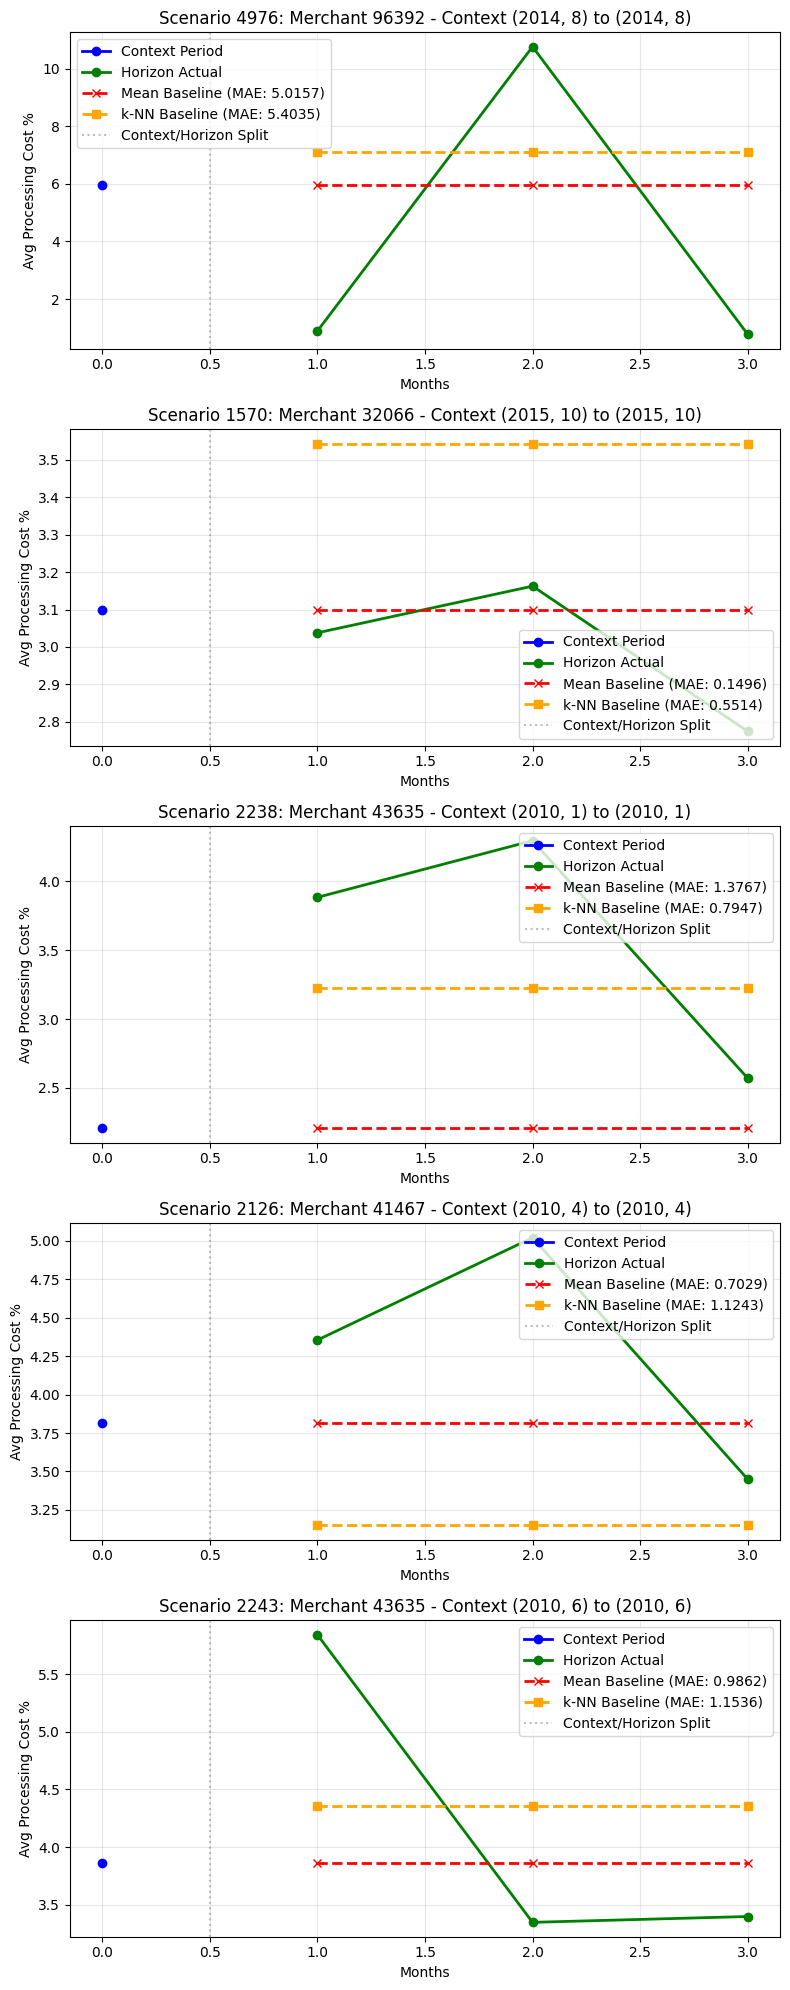


Visualization complete!


In [ ]:
# Visualize baseline comparison for sample scenarios

# Create a subset of results for visualization (sample 5 random scenarios)
sample_indices = np.random.choice(len(baseline_results), min(5, len(baseline_results)), replace=False)

fig, axes = plt.subplots(len(sample_indices), 1, figsize=(8, 4 * len(sample_indices)))
if len(sample_indices) == 1:
    axes = [axes]

for plot_idx, result_idx in enumerate(sample_indices):
    result = baseline_results[result_idx]
    scenario = valid_test_scenarios[result['scenario_idx']]
    
    # Concatenate context and horizon for x-axis
    context_len = len(scenario['context_data'])
    horizon_len = len(result['horizon_actual'])
    
    # Create x-axis: months for context window and horizon window
    x_context = np.arange(context_len)
    x_horizon = np.arange(context_len, context_len + horizon_len)
    
    ax = axes[plot_idx]
    
    # Plot context actual values
    ax.plot(x_context, scenario['context_data']['avg_proc_cost_pct'].values, 
            marker='o', color='blue', label='Context Period', linestyle='-', linewidth=2)
    
    # Plot horizon actual values
    ax.plot(x_horizon, result['horizon_actual'], 
            marker='o', color='green', label='Horizon Actual', linestyle='-', linewidth=2)
    
    # Plot mean baseline prediction
    ax.plot(x_horizon, result['mean_pred'], 
            marker='x', color='red', label=f"Mean Baseline (MAE: {result['mean_baseline_mae']:.4f})", 
            linestyle='--', linewidth=2)
    
    # Plot k-NN baseline prediction (if available)
    if result['knn_pred'] is not None:
        ax.plot(x_horizon, result['knn_pred'], 
                marker='s', color='orange', label=f"k-NN Baseline (MAE: {result['knn_baseline_mae']:.4f})", 
                linestyle='--', linewidth=2)
    
    # Formatting
    ax.axvline(x=context_len - 0.5, color='gray', linestyle=':', alpha=0.5, label='Context/Horizon Split')
    ax.set_xlabel('Months')
    ax.set_ylabel('Avg Processing Cost %')
    ax.set_title(f"Scenario {result['scenario_idx']}: Merchant {result['merchant_id']} - Context {result['context_range'][0]} to {result['context_range'][1]}")
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nVisualization complete!")



BASELINE COMPARISON STATISTICS
     Baseline Method  Count  Mean MAE  Median MAE  Std Dev  Min MAE    Max MAE
     Mean of Context   5301  1.740651    0.699687 7.561519 0.006553 325.370214
k-NN Composite (k=5)   5301  1.999204    0.936289 5.231680 0.045444 164.161946

k-NN improvement over Mean baseline: -14.85%


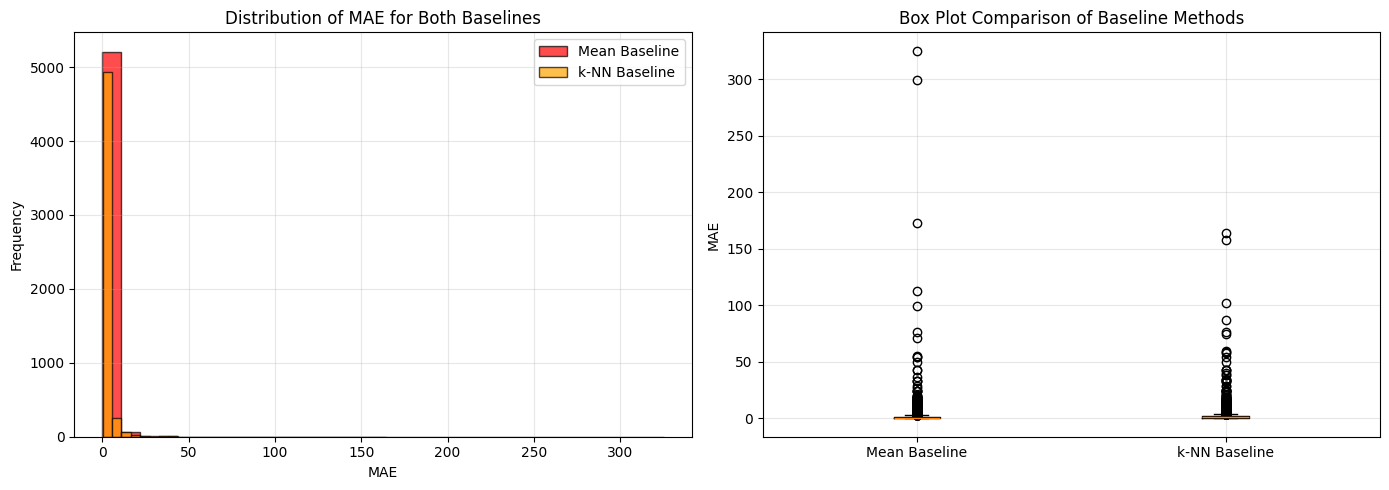

In [ ]:
# Statistical comparison of baseline methods

# Create summary DataFrame
mean_maes = [r['mean_baseline_mae'] for r in baseline_results]
knn_maes = [r['knn_baseline_mae'] for r in baseline_results if not np.isnan(r['knn_baseline_mae'])]

comparison_stats = pd.DataFrame({
    'Baseline Method': ['Mean of Context', 'k-NN Composite (k=5)'],
    'Count': [len(mean_maes), len(knn_maes)],
    'Mean MAE': [np.mean(mean_maes), np.mean(knn_maes)],
    'Median MAE': [np.median(mean_maes), np.median(knn_maes)],
    'Std Dev': [np.std(mean_maes), np.std(knn_maes)],
    'Min MAE': [np.min(mean_maes), np.min(knn_maes)],
    'Max MAE': [np.max(mean_maes), np.max(knn_maes)]
})

print("\n" + "="*100)
print("BASELINE COMPARISON STATISTICS")
print("="*100)
print(comparison_stats.to_string(index=False))
print("="*100)

# Calculate improvement of k-NN over mean baseline
improvement = ((np.mean(mean_maes) - np.mean(knn_maes)) / np.mean(mean_maes)) * 100
print(f"\nk-NN improvement over Mean baseline: {improvement:+.2f}%")

# Create histograms comparing distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(mean_maes, bins=30, alpha=0.7, color='red', label='Mean Baseline', edgecolor='black')
axes[0].hist(knn_maes, bins=30, alpha=0.7, color='orange', label='k-NN Baseline', edgecolor='black')
axes[0].set_xlabel('MAE')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of MAE for Both Baselines')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot comparison
axes[1].boxplot([mean_maes, knn_maes], labels=['Mean Baseline', 'k-NN Baseline'])
axes[1].set_ylabel('MAE')
axes[1].set_title('Box Plot Comparison of Baseline Methods')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## lin-reg, monthly

In [ ]:
# Month-specific linear regression with autoregressive forecasting

from sklearn.linear_model import LinearRegression

linreg_month_results = []

# Get feature columns (all except metadata)
feature_cols = [col for col in df_5411_sample.columns if col not in ['merchant_id', 'year', 'month']]

# Iterate through test scenarios
for scenario_idx, scenario in enumerate(valid_test_scenarios):
    context_data = scenario['context_data']
    horizon_data = scenario['horizon_data']
    merchant_id = context_data['merchant_id'].iloc[0]
    context_end_year, context_end_month = scenario['context_range'][1]
    
    try:
        # Generate pool and composite KNN features
        pool_data = generate_pool(df_5411_sample, merchant_id, context_end_year, context_end_month)
        
        if len(pool_data) > 0:
            composite_knn = get_composite_knn(
                merchant_context_features=context_data,
                pool_df=pool_data,
                k=5
            )
            
            if len(composite_knn) > 0:
                # Train month-specific regressors on composite neighbors
                month_regressors = {}
                
                for month in range(1, 13):
                    month_data = composite_knn[composite_knn['month'] == month].copy()
                    
                    if len(month_data) > 1:  # Need at least 2 samples to train
                        X_train = month_data[feature_cols].fillna(0).values
                        y_train = month_data['avg_proc_cost_pct'].values
                        
                        model = LinearRegression()
                        model.fit(X_train, y_train)
                        month_regressors[month] = model
                
                # Autoregressive prediction: use last context row, predict t+1, use t+1 to predict t+2, etc.
                y_pred = []
                current_row = context_data.iloc[-1].copy()  # Start with last context row
                
                for i, (idx, horizon_row) in enumerate(horizon_data.iterrows()):
                    month = int(horizon_row['month'])
                    
                    # Use month-specific regressor for this month
                    model = month_regressors.get(month, None)
                    
                    if model is not None:
                        # Prepare features from current row
                        X_test = current_row[feature_cols].fillna(0).values.reshape(1, -1)
                        # Make prediction for this horizon step
                        pred = model.predict(X_test)[0]
                        y_pred.append(pred)
                        
                        # Update current_row for next iteration (for autoregressive prediction)
                        # Update avg_proc_cost_pct with the prediction
                        current_row['avg_proc_cost_pct'] = pred
                        
                        # Update lag features: shift them forward
                        current_row['proc_cost_pct_lag_3'] = current_row['proc_cost_pct_lag_2']
                        current_row['proc_cost_pct_lag_2'] = current_row['proc_cost_pct_lag_1']
                        current_row['proc_cost_pct_lag_1'] = pred
                        
                        # Note: Other features (cost_type_*_pct, transaction_count, avg_transaction_value) 
                        # remain unchanged - we assume they follow the pattern of the neighbors
                    else:
                        # No model trained for this month
                        y_pred.append(np.nan)
                
                y_pred = np.array(y_pred)
                y_test = horizon_data['avg_proc_cost_pct'].values
                # Only compute MAE for non-NaN predictions
                valid_mask = ~np.isnan(y_pred)
                if valid_mask.sum() > 0:
                    mae = mean_absolute_error(y_test[valid_mask], y_pred[valid_mask])
                else:
                    mae = None
                
                # Store results
                linreg_month_results.append({
                    'scenario_idx': scenario_idx,
                    'merchant_id': merchant_id,
                    'context_range': scenario['context_range'],
                    'horizon_range': scenario['horizon_range'],
                    'y_pred': y_pred,
                    'y_test': y_test,
                    'mae': mae
                })
            else:
                # Not enough composite data
                pass
        else:
            # No pool data
            pass
    except Exception as e:
        print(f"Error for scenario {scenario_idx}, merchant {merchant_id}: {e}")
    
    if scenario_idx % 100 == 0:
        print(f"Processed {scenario_idx}/{len(valid_test_scenarios)} scenarios...")

print(f"\n✓ Processed {len(linreg_month_results)} scenarios with month-specific linear regression")
print(f"Month-specific Linear Regression MAE - Mean: {np.nanmean([r['mae'] for r in linreg_month_results if r['mae'] is not None]):.6f}")

Processed 0/5301 scenarios...
Processed 100/5301 scenarios...
Processed 200/5301 scenarios...
Processed 300/5301 scenarios...
Processed 400/5301 scenarios...
Processed 500/5301 scenarios...
Processed 600/5301 scenarios...
Processed 700/5301 scenarios...
Processed 800/5301 scenarios...
Processed 900/5301 scenarios...
Processed 1000/5301 scenarios...
Processed 1100/5301 scenarios...
Processed 1200/5301 scenarios...
Processed 1300/5301 scenarios...
Processed 1400/5301 scenarios...
Processed 1500/5301 scenarios...
Processed 1600/5301 scenarios...
Processed 1700/5301 scenarios...
Processed 1800/5301 scenarios...
Processed 1900/5301 scenarios...
Processed 2000/5301 scenarios...
Processed 2100/5301 scenarios...
Processed 2200/5301 scenarios...
Processed 2300/5301 scenarios...
Processed 2400/5301 scenarios...
Processed 2500/5301 scenarios...
Processed 2600/5301 scenarios...
Processed 2700/5301 scenarios...
Processed 2800/5301 scenarios...
Processed 2900/5301 scenarios...
Processed 3000/5301 sc

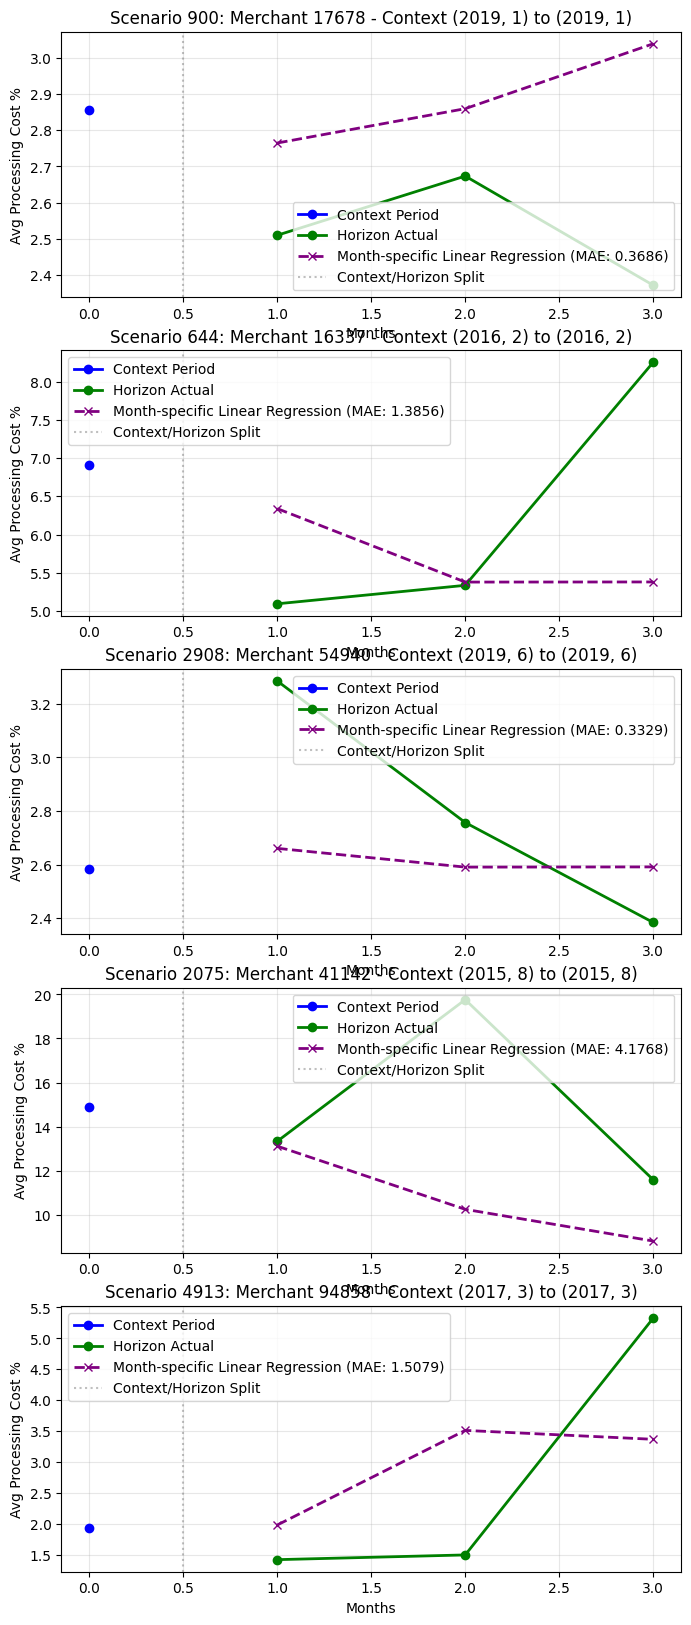

In [ ]:
#visualize month-specific linear regression predictions for sample scenarios

# Create a subset of results for visualization (sample 5 random scenarios)
sample_indices = np.random.choice(len(linreg_month_results), min(5, len(linreg_month_results)), replace=False)

fig, axes = plt.subplots(len(sample_indices), 1, figsize=(8, 4 * len(sample_indices)))
if len(sample_indices) == 1:
    axes = [axes]
for plot_idx, result_idx in enumerate(sample_indices):
    result = linreg_month_results[result_idx]
    scenario = valid_test_scenarios[result['scenario_idx']]
    
    x_context = np.arange(len(scenario['context_data']))
    x_horizon = np.arange(len(scenario['context_data']), len(scenario['context_data']) + len(result['y_test']))
    
    ax = axes[plot_idx]
    
    # Plot context actual values
    ax.plot(x_context, scenario['context_data']['avg_proc_cost_pct'].values, 
            marker='o', color='blue', label='Context Period', linestyle='-', linewidth=2)
    
    # Plot horizon actual values
    ax.plot(x_horizon, result['y_test'], 
            marker='o', color='green', label='Horizon Actual', linestyle='-', linewidth=2)
    
    # Plot month-specific linear regression predictions
    if result['y_pred'] is not None:
        ax.plot(x_horizon, result['y_pred'], 
                marker='x', color='purple', label=f"Month-specific Linear Regression (MAE: {result['mae']:.4f})", 
                linestyle='--', linewidth=2)
    
    # Formatting
    ax.axvline(x=len(scenario['context_data']) - 0.5, color='gray', linestyle=':', alpha=0.5, label='Context/Horizon Split')
    ax.set_xlabel('Months')
    ax.set_ylabel('Avg Processing Cost %')
    ax.set_title(f"Scenario {result['scenario_idx']}: Merchant {result['merchant_id']} - Context {result['context_range'][0]} to {result['context_range'][1]}")
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

In [ ]:
#comparison of month-specific linear regression with baselines for sample scenarios

mean_maes = [r['mean_baseline_mae'] for r in baseline_results]
knn_maes = [r['knn_baseline_mae'] for r in baseline_results]
linreg_maes = [r['mae'] for r in linreg_month_results if r['mae'] is not None]

print(f"\nBaseline Comparison for Sample Scenarios:")
print(f"Mean Baseline MAE - Mean: {np.mean(mean_maes):.6f}")
print(f"k-NN Baseline MAE - Mean: {np.nanmean(knn_maes):.6f}")
print(f"Month-specific Linear Regression MAE - Mean: {np.nanmean(linreg_maes):.6f}")
# Create summary DataFrame for sample scenarios
comparison_stats_sample = pd.DataFrame({
    'Baseline Method': ['Mean of Context', 'k-NN Composite (k=5)', 'Month-specific Linear Regression'],
    'Mean MAE': [np.mean(mean_maes), np.nanmean(knn_maes), np.nanmean(linreg_maes)]
})

print("\n" + "="*100)
print("BASELINE COMPARISON STATISTICS - SAMPLE SCENARIOS")
print("="*100)
print(comparison_stats_sample.to_string(index=False))
print("="*100)


Baseline Comparison for Sample Scenarios:
Mean Baseline MAE - Mean: 1.740651
k-NN Baseline MAE - Mean: 1.999204
Month-specific Linear Regression MAE - Mean: 4.572307

BASELINE COMPARISON STATISTICS - SAMPLE SCENARIOS
                 Baseline Method  Mean MAE
                 Mean of Context  1.740651
            k-NN Composite (k=5)  1.999204
Month-specific Linear Regression  4.572307


## seasonality analysis


SEASONALITY ANALYSIS FOR MERCHANT POOL

1. MONTHLY COST STATISTICS (All Merchants Combined):
      avg_proc_cost_pct                                    transaction_count  \
                   mean  median      std     min       max              mean   
month                                                                          
1                4.9416  2.9157  12.0501  0.3353  181.1800            6.2548   
2                4.1691  2.9444   6.2900  0.4683  116.7794            5.7433   
3                3.9920  2.8480   4.3895  0.3732   65.8943            6.1655   
4                4.6387  2.8918  13.0529  0.3616  301.1800            5.6801   
5                4.5075  2.8765   9.4557  0.3688  164.8164            5.9819   
6                4.9039  2.8619  15.1561  0.4677  328.7514            5.8143   
7                4.2957  2.9158   7.8397  0.3797  164.8164            5.3865   
8                4.9544  2.8174  10.7412  0.5163  151.1800            5.8172   
9                4.3009  2

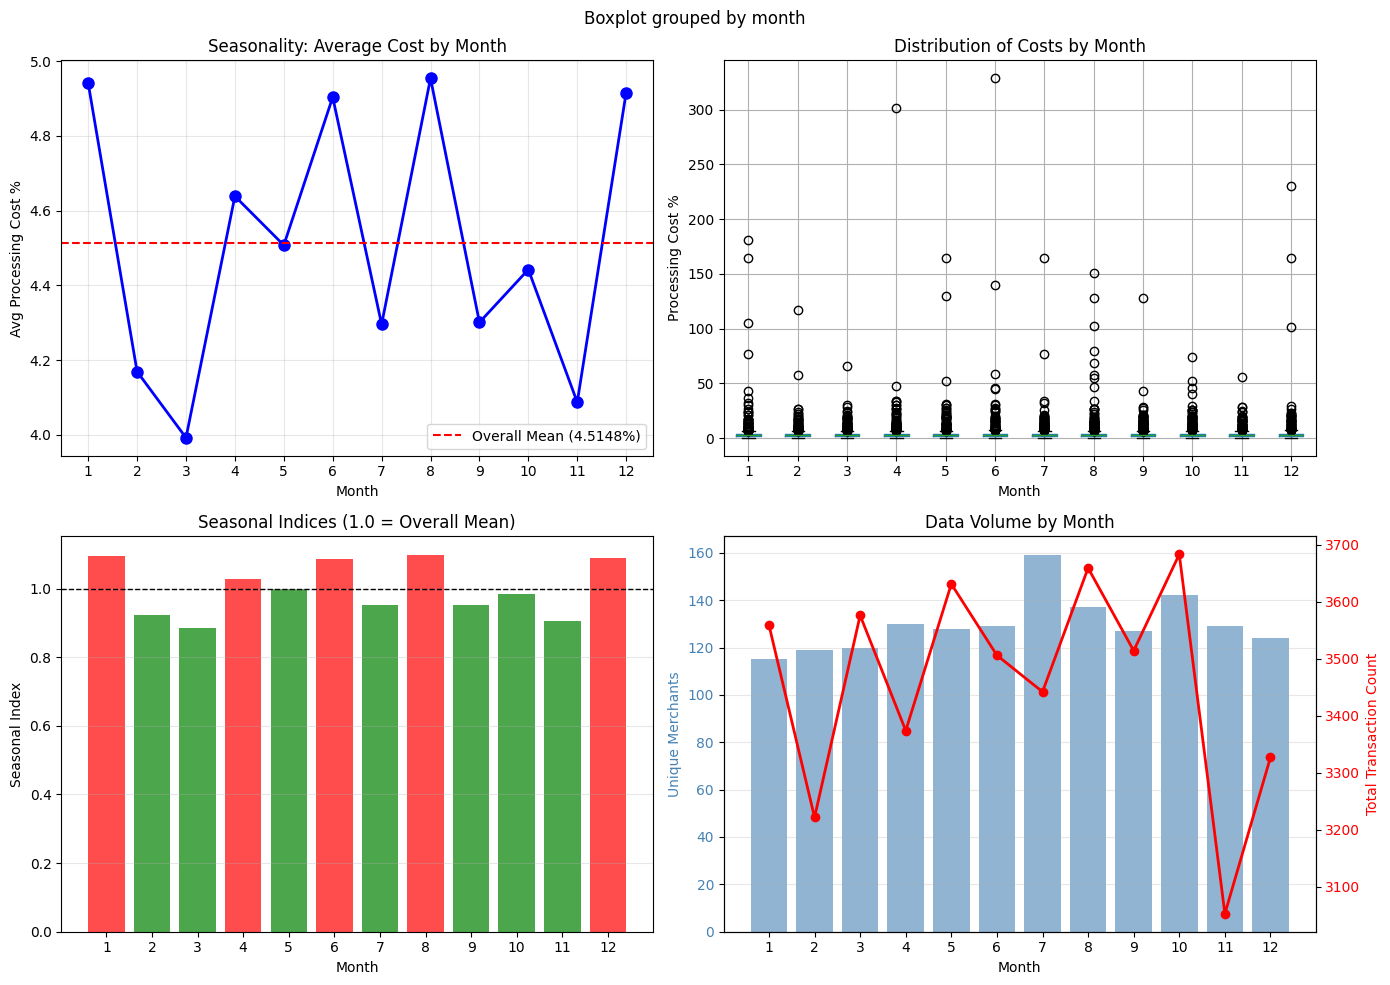


4. MERCHANT-LEVEL SEASONALITY:
   Average Seasonality (CV): 0.4682
   Merchants with High Seasonality (CV > 0.1): 146
   Merchants with Low Seasonality (CV < 0.05): 7

   Top 5 Merchants by Seasonality Strength:
      Merchant 42955.0: CV = 1.7471 (4.0 months)
      Merchant 16571.0: CV = 1.6777 (6.0 months)
      Merchant 52865.0: CV = 1.6396 (8.0 months)
      Merchant 72553.0: CV = 1.5554 (5.0 months)
      Merchant 23385.0: CV = 1.4212 (6.0 months)


In [ ]:
# ========== SEASONALITY ANALYSIS ==========
print("\n" + "="*100)
print("SEASONALITY ANALYSIS FOR MERCHANT POOL")
print("="*100)

# 1. Monthly aggregation across all merchants
monthly_agg = df_5411_sample.groupby('month').agg({
    'avg_proc_cost_pct': ['mean', 'median', 'std', 'min', 'max'],
    'transaction_count': ['mean', 'sum'],
    'merchant_id': 'nunique'
}).round(4)

print("\n1. MONTHLY COST STATISTICS (All Merchants Combined):")
print(monthly_agg)

# 2. Calculate seasonal indices (ratio to overall mean)
overall_mean = df_5411_sample['avg_proc_cost_pct'].mean()
seasonal_indices = df_5411_sample.groupby('month')['avg_proc_cost_pct'].mean() / overall_mean
print(f"\n2. SEASONAL INDICES (Ratio to Overall Mean = {overall_mean:.4f}):")
for month in range(1, 13):
    idx = seasonal_indices.get(month, np.nan)
    pct_change = (idx - 1) * 100 if not np.isnan(idx) else np.nan
    print(f"   Month {month:2d}: {idx:.4f} ({pct_change:+.2f}%)")

# 3. Identify peak and trough months
peak_month = df_5411_sample.groupby('month')['avg_proc_cost_pct'].mean().idxmax()
trough_month = df_5411_sample.groupby('month')['avg_proc_cost_pct'].mean().idxmin()
peak_value = df_5411_sample[df_5411_sample['month'] == peak_month]['avg_proc_cost_pct'].mean()
trough_value = df_5411_sample[df_5411_sample['month'] == trough_month]['avg_proc_cost_pct'].mean()
seasonal_range = peak_value - trough_value
print(f"\n3. SEASONAL STRENGTH:")
print(f"   Peak Month: {peak_month} (Avg Cost: {peak_value:.4f}%)")
print(f"   Trough Month: {trough_month} (Avg Cost: {trough_value:.4f}%)")
print(f"   Seasonal Range: {seasonal_range:.4f}% ({(seasonal_range/overall_mean)*100:.2f}% of mean)")
print(f"   Coefficient of Variation (Monthly): {seasonal_indices.std():.4f}")

# 4. Visualize seasonality patterns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Average cost by month (line plot)
monthly_costs = df_5411_sample.groupby('month')['avg_proc_cost_pct'].mean()
axes[0, 0].plot(monthly_costs.index, monthly_costs.values, marker='o', linewidth=2, markersize=8, color='blue')
axes[0, 0].axhline(y=overall_mean, color='red', linestyle='--', label=f'Overall Mean ({overall_mean:.4f}%)')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Avg Processing Cost %')
axes[0, 0].set_title('Seasonality: Average Cost by Month')
axes[0, 0].set_xticks(range(1, 13))
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# Plot 2: Box plot of costs by month
df_5411_sample.boxplot(column='avg_proc_cost_pct', by='month', ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Costs by Month')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Processing Cost %')
plt.sca(axes[0, 1])
plt.xticks(range(1, 13))

# Plot 3: Seasonal indices
axes[1, 0].bar(seasonal_indices.index, seasonal_indices.values, color=['green' if x < 1 else 'red' for x in seasonal_indices.values], alpha=0.7)
axes[1, 0].axhline(y=1.0, color='black', linestyle='--', linewidth=1)
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Seasonal Index')
axes[1, 0].set_title('Seasonal Indices (1.0 = Overall Mean)')
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: Merchant count and transaction volume by month
monthly_stats = df_5411_sample.groupby('month').agg({
    'merchant_id': 'nunique',
    'transaction_count': 'sum'
})
ax_left = axes[1, 1]
ax_left.bar(monthly_stats.index, monthly_stats['merchant_id'], alpha=0.6, label='Unique Merchants', color='steelblue')
ax_right = ax_left.twinx()
ax_right.plot(monthly_stats.index, monthly_stats['transaction_count'], marker='o', color='red', linewidth=2, label='Transaction Volume')
ax_left.set_xlabel('Month')
ax_left.set_ylabel('Unique Merchants', color='steelblue')
ax_right.set_ylabel('Total Transaction Count', color='red')
ax_left.set_title('Data Volume by Month')
ax_left.set_xticks(range(1, 13))
ax_left.tick_params(axis='y', labelcolor='steelblue')
ax_right.tick_params(axis='y', labelcolor='red')
ax_left.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 5. Merchant-level seasonality variance
print(f"\n4. MERCHANT-LEVEL SEASONALITY:")
merchant_seasonal_strength = []
for merchant_id in df_5411_sample['merchant_id'].unique():
    merchant_data = df_5411_sample[df_5411_sample['merchant_id'] == merchant_id]
    if len(merchant_data) >= 3:  # At least 3 months of data
        monthly_values = merchant_data.groupby('month')['avg_proc_cost_pct'].mean()
        if len(monthly_values) > 1:
            coef_var = monthly_values.std() / monthly_values.mean() if monthly_values.mean() != 0 else 0
            merchant_seasonal_strength.append({
                'merchant_id': merchant_id,
                'seasonality_cv': coef_var,
                'months_observed': len(monthly_values)
            })

seasonal_df = pd.DataFrame(merchant_seasonal_strength)
if len(seasonal_df) > 0:
    print(f"   Average Seasonality (CV): {seasonal_df['seasonality_cv'].mean():.4f}")
    print(f"   Merchants with High Seasonality (CV > 0.1): {(seasonal_df['seasonality_cv'] > 0.1).sum()}")
    print(f"   Merchants with Low Seasonality (CV < 0.05): {(seasonal_df['seasonality_cv'] < 0.05).sum()}")
    
    # Top 5 merchants by seasonality
    print(f"\n   Top 5 Merchants by Seasonality Strength:")
    top_seasonal = seasonal_df.nlargest(5, 'seasonality_cv')
    for idx, row in top_seasonal.iterrows():
        print(f"      Merchant {row['merchant_id']}: CV = {row['seasonality_cv']:.4f} ({row['months_observed']} months)")

## seasonally adjusted baselines


OPTION 2: GLOBAL SEASONAL ADJUSTMENT TO BASELINES

1. SEASONAL INDICES APPLIED:
   Month  1: 1.0945 (+9.45%)
   Month  2: 0.9234 (-7.66%)
   Month  3: 0.8842 (-11.58%)
   Month  4: 1.0275 (+2.75%)
   Month  5: 0.9984 (-0.16%)
   Month  6: 1.0862 (+8.62%)
   Month  7: 0.9515 (-4.85%)
   Month  8: 1.0974 (+9.74%)
   Month  9: 0.9526 (-4.74%)
   Month 10: 0.9840 (-1.60%)
   Month 11: 0.9053 (-9.47%)
   Month 12: 1.0889 (+8.89%)

✓ Applied seasonal adjustment to 5301 scenarios

2. PERFORMANCE COMPARISON: ORIGINAL vs SEASONALLY-ADJUSTED

       Method  Mean MAE  Median MAE  Std Dev
Mean Baseline  1.740651    0.699687 7.561519
Seasonal Mean  1.760516    0.730384 7.504087
k-NN Baseline  1.999204    0.936289 5.231680
Seasonal k-NN  2.010506    0.958160 5.201862

IMPROVEMENT FROM SEASONAL ADJUSTMENT:
  Mean Baseline → Seasonal Mean: -1.14%
  k-NN Baseline → Seasonal k-NN:  -0.57%

🏆 BEST METHOD: Mean Baseline (MAE: 1.740651)


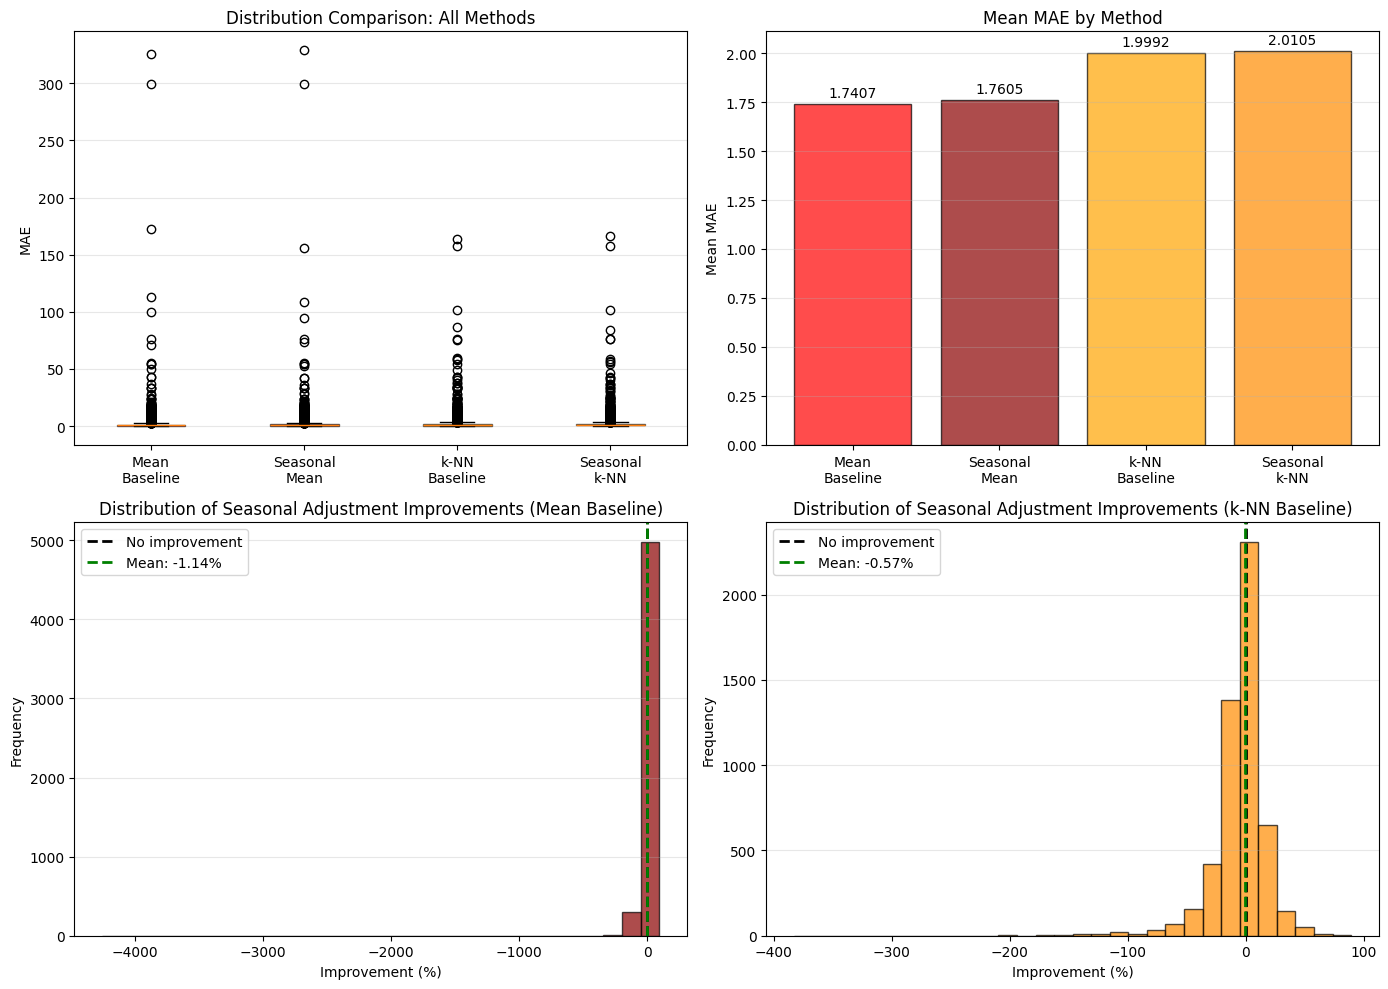

In [ ]:
# ========== OPTION 2: SEASONAL ADJUSTMENT TRIAL ==========
print("\n" + "="*100)
print("OPTION 2: GLOBAL SEASONAL ADJUSTMENT TO BASELINES")
print("="*100)

# Extract seasonal indices (recompute to ensure consistency)
overall_mean = df_5411_sample['avg_proc_cost_pct'].mean()
seasonal_indices_dict = (df_5411_sample.groupby('month')['avg_proc_cost_pct'].mean() / overall_mean).to_dict()

print("\n1. SEASONAL INDICES APPLIED:")
for month in range(1, 13):
    idx = seasonal_indices_dict.get(month, 1.0)
    pct_change = (idx - 1) * 100
    print(f"   Month {month:2d}: {idx:.4f} ({pct_change:+.2f}%)")

# Apply seasonal adjustment to baseline results
seasonal_adjusted_results = []

for result in baseline_results:
    scenario = valid_test_scenarios[result['scenario_idx']]
    horizon_data = scenario['horizon_data']
    horizon_actual = result['horizon_actual']
    
    # Extract horizon months
    horizon_months = horizon_data['month'].values
    
    # ===== BASELINE 1: Seasonally-adjusted Mean =====
    context_mean = result['context_mean']
    # Get seasonal factors for horizon months
    seasonal_factors = np.array([seasonal_indices_dict.get(int(m), 1.0) for m in horizon_months])
    # Apply seasonal adjustment
    seasonal_mean_pred = context_mean * seasonal_factors
    seasonal_mean_mae = np.mean(np.abs(horizon_actual - seasonal_mean_pred))
    
    # ===== BASELINE 2: Seasonally-adjusted k-NN =====
    if result['knn_pred'] is not None:
        # k-NN used most recent neighbor cost (was constant across horizon)
        # Now apply seasonal adjustment
        original_knn_value = result['knn_pred'][0]  # Was constant for all horizon months
        seasonal_knn_pred = original_knn_value * seasonal_factors
        seasonal_knn_mae = np.mean(np.abs(horizon_actual - seasonal_knn_pred))
    else:
        seasonal_knn_pred = None
        seasonal_knn_mae = np.nan
    
    seasonal_adjusted_results.append({
        'scenario_idx': result['scenario_idx'],
        'merchant_id': result['merchant_id'],
        'horizon_months': horizon_months,
        'horizon_actual': horizon_actual,
        'seasonal_factors': seasonal_factors,
        
        # Original methods
        'mean_baseline_mae': result['mean_baseline_mae'],
        'knn_baseline_mae': result['knn_baseline_mae'],
        
        # Seasonally adjusted methods
        'seasonal_mean_mae': seasonal_mean_mae,
        'seasonal_knn_mae': seasonal_knn_mae,
        'seasonal_mean_pred': seasonal_mean_pred,
        'seasonal_knn_pred': seasonal_knn_pred
    })

print(f"\n✓ Applied seasonal adjustment to {len(seasonal_adjusted_results)} scenarios")

# ===== COMPARISON STATISTICS =====
print("\n" + "="*100)
print("2. PERFORMANCE COMPARISON: ORIGINAL vs SEASONALLY-ADJUSTED")
print("="*100)

mean_baseline_maes = [r['mean_baseline_mae'] for r in seasonal_adjusted_results]
seasonal_mean_maes = [r['seasonal_mean_mae'] for r in seasonal_adjusted_results]
knn_baseline_maes = [r['knn_baseline_mae'] for r in seasonal_adjusted_results]
seasonal_knn_maes = [r['seasonal_knn_mae'] for r in seasonal_adjusted_results]

comparison_seasonal = pd.DataFrame({
    'Method': [
        'Mean Baseline',
        'Seasonal Mean',
        'k-NN Baseline',
        'Seasonal k-NN'
    ],
    'Mean MAE': [
        np.mean(mean_baseline_maes),
        np.mean(seasonal_mean_maes),
        np.nanmean(knn_baseline_maes),
        np.nanmean(seasonal_knn_maes)
    ],
    'Median MAE': [
        np.median(mean_baseline_maes),
        np.median(seasonal_mean_maes),
        np.nanmedian(knn_baseline_maes),
        np.nanmedian(seasonal_knn_maes)
    ],
    'Std Dev': [
        np.std(mean_baseline_maes),
        np.std(seasonal_mean_maes),
        np.nanstd(knn_baseline_maes),
        np.nanstd(seasonal_knn_maes)
    ]
})

print("\n" + comparison_seasonal.to_string(index=False))

# Calculate improvements
mean_improvement = ((np.mean(mean_baseline_maes) - np.mean(seasonal_mean_maes)) / np.mean(mean_baseline_maes)) * 100
knn_improvement = ((np.nanmean(knn_baseline_maes) - np.nanmean(seasonal_knn_maes)) / np.nanmean(knn_baseline_maes)) * 100

print(f"\nIMPROVEMENT FROM SEASONAL ADJUSTMENT:")
print(f"  Mean Baseline → Seasonal Mean: {mean_improvement:+.2f}%")
print(f"  k-NN Baseline → Seasonal k-NN:  {knn_improvement:+.2f}%")

# Determine best method
all_maes = {
    'Mean Baseline': np.mean(mean_baseline_maes),
    'Seasonal Mean': np.mean(seasonal_mean_maes),
    'k-NN Baseline': np.nanmean(knn_baseline_maes),
    'Seasonal k-NN': np.nanmean(seasonal_knn_maes)
}
best_method = min(all_maes, key=all_maes.get)
print(f"\n🏆 BEST METHOD: {best_method} (MAE: {all_maes[best_method]:.6f})")

# ===== VISUALIZATIONS =====
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: MAE Distribution comparison
methods = ['Mean\nBaseline', 'Seasonal\nMean', 'k-NN\nBaseline', 'Seasonal\nk-NN']
maes_list = [mean_baseline_maes, seasonal_mean_maes, knn_baseline_maes, seasonal_knn_maes]
colors = ['red', 'darkred', 'orange', 'darkorange']

bp = axes[0, 0].boxplot(maes_list, labels=methods, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[0, 0].set_ylabel('MAE')
axes[0, 0].set_title('Distribution Comparison: All Methods')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Plot 2: Mean MAE bar chart
mean_vals = [np.mean(m) for m in maes_list]
axes[0, 1].bar(methods, mean_vals, color=colors, alpha=0.7, edgecolor='black')
axes[0, 1].set_ylabel('Mean MAE')
axes[0, 1].set_title('Mean MAE by Method')
axes[0, 1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(mean_vals):
    axes[0, 1].text(i, v + 0.02, f'{v:.4f}', ha='center', va='bottom')

# Plot 3: Improvement from seasonal adjustment (mean vs seasonal mean)
improvements = []
for orig, seasonal in zip(mean_baseline_maes, seasonal_mean_maes):
    improvements.append((orig - seasonal) / orig * 100)
axes[1, 0].hist(improvements, bins=30, color='darkred', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(x=0, color='black', linestyle='--', linewidth=2, label='No improvement')
axes[1, 0].axvline(x=mean_improvement, color='green', linestyle='--', linewidth=2, label=f'Mean: {mean_improvement:+.2f}%')
axes[1, 0].set_xlabel('Improvement (%)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Seasonal Adjustment Improvements (Mean Baseline)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: Improvement from seasonal adjustment (k-NN vs seasonal k-NN)
knn_improvements = []
for orig, seasonal in zip(knn_baseline_maes, seasonal_knn_maes):
    if not np.isnan(orig) and not np.isnan(seasonal):
        knn_improvements.append((orig - seasonal) / orig * 100)
axes[1, 1].hist(knn_improvements, bins=30, color='darkorange', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(x=0, color='black', linestyle='--', linewidth=2, label='No improvement')
axes[1, 1].axvline(x=knn_improvement, color='green', linestyle='--', linewidth=2, label=f'Mean: {knn_improvement:+.2f}%')
axes[1, 1].set_xlabel('Improvement (%)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Seasonal Adjustment Improvements (k-NN Baseline)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n" + "="*100)

# Modelling trial 2: expanding context_len to 12

In [ ]:
valid_test_scenarios_2 = []

for merchant_id in valid_merchants:
    scenarios = get_test_scenario(df_5411_sample, merchant_id, context_len=12, context_max_NAN_months=0, horizon_len=3, horizon_max_NAN_months=0)
    for scenario in scenarios:
        valid_test_scenarios_2.append({
            'merchant_id': merchant_id,
            'context_data': scenario['context_data'],
            'horizon_data': scenario['horizon_data'],
            'context_range': scenario['context_range'],
            'horizon_range': scenario['horizon_range'],
            'context_gaps': scenario['context_gaps'],
            'horizon_gaps': scenario['horizon_gaps']
        })

Merchant 796 has 118 month records from 2010.0-1.0 to 2019.0-10.0
✓ Found 104 valid scenario(s)
Merchant 2636 has 6 month records from 2011.0-8.0 to 2019.0-5.0
✗ No valid scenario found for merchant 2636 with context_len=12, horizon_len=3
Merchant 2880 has 8 month records from 2010.0-7.0 to 2019.0-5.0
✗ No valid scenario found for merchant 2880 with context_len=12, horizon_len=3
Merchant 5542 has 4 month records from 2012.0-8.0 to 2019.0-3.0
✗ No valid scenario found for merchant 5542 with context_len=12, horizon_len=3
Merchant 5849 has 4 month records from 2013.0-7.0 to 2017.0-8.0
✗ No valid scenario found for merchant 5849 with context_len=12, horizon_len=3
Merchant 6001 has 48 month records from 2010.0-6.0 to 2019.0-8.0
✗ No valid scenario found for merchant 6001 with context_len=12, horizon_len=3
Merchant 6594 has 15 month records from 2010.0-5.0 to 2019.0-9.0
✗ No valid scenario found for merchant 6594 with context_len=12, horizon_len=3
Merchant 9072 has 27 month records from 2010

## mean and knn baseline

In [ ]:
# Iterate through test_scenarios to calculate baseline MAE for mean and KNN predictions

baseline_results = []

for scenario_idx, scenario in enumerate(valid_test_scenarios_2):
    # Extract context and horizon data
    context_data = scenario['context_data']
    horizon_data = scenario['horizon_data']
    merchant_id = context_data['merchant_id'].iloc[0]
    context_end_year, context_end_month = scenario['context_range'][1]
    
    # Get actual horizon values
    horizon_actual = horizon_data['avg_proc_cost_pct'].values
    
    # ========== BASELINE 1: Mean of context ==========
    context_mean = context_data['avg_proc_cost_pct'].mean()
    mean_baseline_pred = np.full_like(horizon_actual, fill_value=context_mean)
    mean_mae = np.mean(np.abs(horizon_actual - mean_baseline_pred))
    
    # ========== BASELINE 2: k-NN composite ==========
    try:
        # Generate pool excluding this merchant up to context end date
        pool_data = generate_pool(df_5411_sample, merchant_id, context_end_year, context_end_month)
        
        if len(pool_data) > 0:
            # Get composite KNN features (all historical months of k nearest neighbors)
            composite_knn = get_composite_knn(
                merchant_context_features=context_data,
                pool_df=pool_data,
                k=5
            )
            
            # Use the most recent month of composite as prediction for entire horizon
            if len(composite_knn) > 0:
                # Most recent month should be at the end (after sorting)
                sorted_composite = composite_knn.sort_values(['year', 'month'])
                most_recent_proc_cost = sorted_composite['avg_proc_cost_pct'].iloc[-1]
                knn_baseline_pred = np.full_like(horizon_actual, fill_value=most_recent_proc_cost)
                knn_mae = np.mean(np.abs(horizon_actual - knn_baseline_pred))
            else:
                knn_baseline_pred = None
                knn_mae = np.nan
        else:
            knn_baseline_pred = None
            knn_mae = np.nan
    except Exception as e:
        print(f"Error for scenario {scenario_idx}, merchant {merchant_id}: {e}")
        knn_baseline_pred = None
        knn_mae = np.nan
    
    # Store results
    baseline_results.append({
        'scenario_idx': scenario_idx,
        'merchant_id': merchant_id,
        'context_range': scenario['context_range'],
        'horizon_range': scenario['horizon_range'],
        'context_mean': context_mean,
        'mean_baseline_mae': mean_mae,
        'knn_baseline_mae': knn_mae,
        'horizon_actual': horizon_actual,
        'mean_pred': mean_baseline_pred,
        'knn_pred': knn_baseline_pred
    })
    
    if scenario_idx % 100 == 0:
        print(f"Processed {scenario_idx}/{len(valid_test_scenarios_2)} scenarios...")

print(f"\n✓ Processed {len(baseline_results)} scenarios")
print(f"Mean baseline MAE - Mean: {np.mean([r['mean_baseline_mae'] for r in baseline_results]):.6f}")
print(f"KNN baseline MAE - Mean: {np.nanmean([r['knn_baseline_mae'] for r in baseline_results]):.6f}")


Processed 0/3987 scenarios...
Processed 100/3987 scenarios...
Processed 200/3987 scenarios...
Processed 300/3987 scenarios...
Processed 400/3987 scenarios...
Processed 500/3987 scenarios...
Processed 600/3987 scenarios...
Processed 700/3987 scenarios...
Processed 800/3987 scenarios...
Processed 900/3987 scenarios...
Processed 1000/3987 scenarios...
Processed 1100/3987 scenarios...
Processed 1200/3987 scenarios...
Processed 1300/3987 scenarios...
Processed 1400/3987 scenarios...
Processed 1500/3987 scenarios...
Processed 1600/3987 scenarios...
Processed 1700/3987 scenarios...
Processed 1800/3987 scenarios...
Processed 1900/3987 scenarios...
Processed 2000/3987 scenarios...
Processed 2100/3987 scenarios...
Processed 2200/3987 scenarios...
Processed 2300/3987 scenarios...
Processed 2400/3987 scenarios...
Processed 2500/3987 scenarios...
Processed 2600/3987 scenarios...
Processed 2700/3987 scenarios...
Processed 2800/3987 scenarios...
Processed 2900/3987 scenarios...
Processed 3000/3987 sc

## lin-reg monthly

In [ ]:
# Month-specific linear regression with autoregressive forecasting

from sklearn.linear_model import LinearRegression

linreg_month_results = []

# Get feature columns (all except metadata)
feature_cols = [col for col in df_5411_sample.columns if col not in ['merchant_id', 'year', 'month']]

# Iterate through test scenarios
for scenario_idx, scenario in enumerate(valid_test_scenarios_2):
    context_data = scenario['context_data']
    horizon_data = scenario['horizon_data']
    merchant_id = context_data['merchant_id'].iloc[0]
    context_end_year, context_end_month = scenario['context_range'][1]
    
    try:
        # Generate pool and composite KNN features
        pool_data = generate_pool(df_5411_sample, merchant_id, context_end_year, context_end_month)
        
        if len(pool_data) > 0:
            composite_knn = get_composite_knn(
                merchant_context_features=context_data,
                pool_df=pool_data,
                k=5
            )
            
            if len(composite_knn) > 0:
                # Train month-specific regressors on composite neighbors
                month_regressors = {}
                
                for month in range(1, 13):
                    month_data = composite_knn[composite_knn['month'] == month].copy()
                    
                    if len(month_data) > 1:  # Need at least 2 samples to train
                        X_train = month_data[feature_cols].fillna(0).values
                        y_train = month_data['avg_proc_cost_pct'].values
                        
                        model = LinearRegression()
                        model.fit(X_train, y_train)
                        month_regressors[month] = model
                
                # Autoregressive prediction: use last context row, predict t+1, use t+1 to predict t+2, etc.
                y_pred = []
                current_row = context_data.iloc[-1].copy()  # Start with last context row
                
                for i, (idx, horizon_row) in enumerate(horizon_data.iterrows()):
                    month = int(horizon_row['month'])
                    
                    # Use month-specific regressor for this month
                    model = month_regressors.get(month, None)
                    
                    if model is not None:
                        # Prepare features from current row
                        X_test = current_row[feature_cols].fillna(0).values.reshape(1, -1)
                        # Make prediction for this horizon step
                        pred = model.predict(X_test)[0]
                        y_pred.append(pred)
                        
                        # Update current_row for next iteration (for autoregressive prediction)
                        # Update avg_proc_cost_pct with the prediction
                        current_row['avg_proc_cost_pct'] = pred
                        
                        # Update lag features: shift them forward
                        current_row['proc_cost_pct_lag_3'] = current_row['proc_cost_pct_lag_2']
                        current_row['proc_cost_pct_lag_2'] = current_row['proc_cost_pct_lag_1']
                        current_row['proc_cost_pct_lag_1'] = pred
                        
                        # Note: Other features (cost_type_*_pct, transaction_count, avg_transaction_value) 
                        # remain unchanged - we assume they follow the pattern of the neighbors
                    else:
                        # No model trained for this month
                        y_pred.append(np.nan)
                
                y_pred = np.array(y_pred)
                y_test = horizon_data['avg_proc_cost_pct'].values
                # Only compute MAE for non-NaN predictions
                valid_mask = ~np.isnan(y_pred)
                if valid_mask.sum() > 0:
                    mae = mean_absolute_error(y_test[valid_mask], y_pred[valid_mask])
                else:
                    mae = None
                
                # Store results
                linreg_month_results.append({
                    'scenario_idx': scenario_idx,
                    'merchant_id': merchant_id,
                    'context_range': scenario['context_range'],
                    'horizon_range': scenario['horizon_range'],
                    'y_pred': y_pred,
                    'y_test': y_test,
                    'mae': mae
                })
            else:
                # Not enough composite data
                pass
        else:
            # No pool data
            pass
    except Exception as e:
        print(f"Error for scenario {scenario_idx}, merchant {merchant_id}: {e}")
    
    if scenario_idx % 100 == 0:
        print(f"Processed {scenario_idx}/{len(valid_test_scenarios_2)} scenarios...")

print(f"\n✓ Processed {len(linreg_month_results)} scenarios with month-specific linear regression")
print(f"Month-specific Linear Regression MAE - Mean: {np.nanmean([r['mae'] for r in linreg_month_results if r['mae'] is not None]):.6f}")

Processed 0/3987 scenarios...
Processed 100/3987 scenarios...
Processed 200/3987 scenarios...
Processed 300/3987 scenarios...
Processed 400/3987 scenarios...
Processed 500/3987 scenarios...
Processed 600/3987 scenarios...
Processed 700/3987 scenarios...
Processed 800/3987 scenarios...
Processed 900/3987 scenarios...
Processed 1000/3987 scenarios...
Processed 1100/3987 scenarios...
Processed 1200/3987 scenarios...
Processed 1300/3987 scenarios...
Processed 1400/3987 scenarios...
Processed 1500/3987 scenarios...
Processed 1600/3987 scenarios...
Processed 1700/3987 scenarios...
Processed 1800/3987 scenarios...
Processed 1900/3987 scenarios...
Processed 2000/3987 scenarios...
Processed 2100/3987 scenarios...
Processed 2200/3987 scenarios...
Processed 2300/3987 scenarios...
Processed 2400/3987 scenarios...
Processed 2500/3987 scenarios...
Processed 2600/3987 scenarios...
Processed 2700/3987 scenarios...
Processed 2800/3987 scenarios...
Processed 2900/3987 scenarios...
Processed 3000/3987 sc

## Seasonal Adjustment


OPTION 2: GLOBAL SEASONAL ADJUSTMENT TO BASELINES

1. SEASONAL INDICES APPLIED:
   Month  1: 1.0945 (+9.45%)
   Month  2: 0.9234 (-7.66%)
   Month  3: 0.8842 (-11.58%)
   Month  4: 1.0275 (+2.75%)
   Month  5: 0.9984 (-0.16%)
   Month  6: 1.0862 (+8.62%)
   Month  7: 0.9515 (-4.85%)
   Month  8: 1.0974 (+9.74%)
   Month  9: 0.9526 (-4.74%)
   Month 10: 0.9840 (-1.60%)
   Month 11: 0.9053 (-9.47%)
   Month 12: 1.0889 (+8.89%)

✓ Applied seasonal adjustment to 3987 scenarios

2. PERFORMANCE COMPARISON: ORIGINAL vs SEASONALLY-ADJUSTED

       Method  Mean MAE  Median MAE  Std Dev
Mean Baseline  1.193053    0.560825 2.125238
Seasonal Mean  1.218872    0.605082 2.109780
k-NN Baseline  1.951695    0.930880 3.222845
Seasonal k-NN  1.972569    0.952320 3.203263

IMPROVEMENT FROM SEASONAL ADJUSTMENT:
  Mean Baseline → Seasonal Mean: -2.16%
  k-NN Baseline → Seasonal k-NN:  -1.07%

🏆 BEST METHOD: Mean Baseline (MAE: 1.193053)


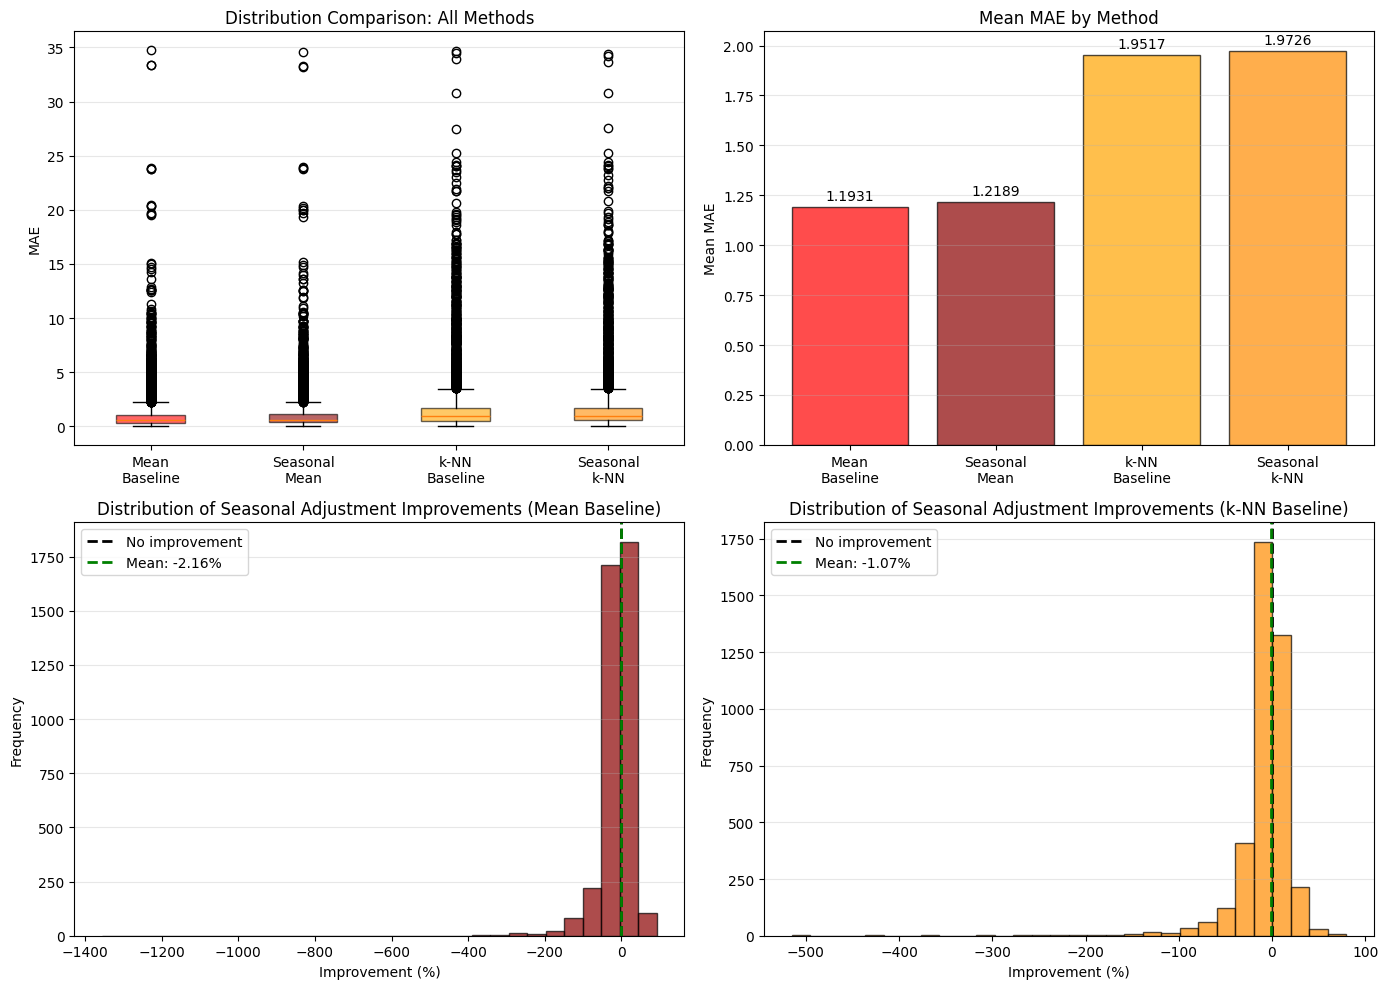

In [ ]:
# ========== OPTION 2: SEASONAL ADJUSTMENT TRIAL ==========
print("\n" + "="*100)
print("OPTION 2: GLOBAL SEASONAL ADJUSTMENT TO BASELINES")
print("="*100)

# Extract seasonal indices (recompute to ensure consistency)
overall_mean = df_5411_sample['avg_proc_cost_pct'].mean()
seasonal_indices_dict = (df_5411_sample.groupby('month')['avg_proc_cost_pct'].mean() / overall_mean).to_dict()

print("\n1. SEASONAL INDICES APPLIED:")
for month in range(1, 13):
    idx = seasonal_indices_dict.get(month, 1.0)
    pct_change = (idx - 1) * 100
    print(f"   Month {month:2d}: {idx:.4f} ({pct_change:+.2f}%)")

# Apply seasonal adjustment to baseline results
seasonal_adjusted_results = []

for result in baseline_results:
    scenario = valid_test_scenarios_2[result['scenario_idx']]
    horizon_data = scenario['horizon_data']
    horizon_actual = result['horizon_actual']
    
    # Extract horizon months
    horizon_months = horizon_data['month'].values
    
    # ===== BASELINE 1: Seasonally-adjusted Mean =====
    context_mean = result['context_mean']
    # Get seasonal factors for horizon months
    seasonal_factors = np.array([seasonal_indices_dict.get(int(m), 1.0) for m in horizon_months])
    # Apply seasonal adjustment
    seasonal_mean_pred = context_mean * seasonal_factors
    seasonal_mean_mae = np.mean(np.abs(horizon_actual - seasonal_mean_pred))
    
    # ===== BASELINE 2: Seasonally-adjusted k-NN =====
    if result['knn_pred'] is not None:
        # k-NN used most recent neighbor cost (was constant across horizon)
        # Now apply seasonal adjustment
        original_knn_value = result['knn_pred'][0]  # Was constant for all horizon months
        seasonal_knn_pred = original_knn_value * seasonal_factors
        seasonal_knn_mae = np.mean(np.abs(horizon_actual - seasonal_knn_pred))
    else:
        seasonal_knn_pred = None
        seasonal_knn_mae = np.nan
    
    seasonal_adjusted_results.append({
        'scenario_idx': result['scenario_idx'],
        'merchant_id': result['merchant_id'],
        'horizon_months': horizon_months,
        'horizon_actual': horizon_actual,
        'seasonal_factors': seasonal_factors,
        
        # Original methods
        'mean_baseline_mae': result['mean_baseline_mae'],
        'knn_baseline_mae': result['knn_baseline_mae'],
        
        # Seasonally adjusted methods
        'seasonal_mean_mae': seasonal_mean_mae,
        'seasonal_knn_mae': seasonal_knn_mae,
        'seasonal_mean_pred': seasonal_mean_pred,
        'seasonal_knn_pred': seasonal_knn_pred
    })

print(f"\n✓ Applied seasonal adjustment to {len(seasonal_adjusted_results)} scenarios")

# ===== COMPARISON STATISTICS =====
print("\n" + "="*100)
print("2. PERFORMANCE COMPARISON: ORIGINAL vs SEASONALLY-ADJUSTED")
print("="*100)

mean_baseline_maes = [r['mean_baseline_mae'] for r in seasonal_adjusted_results]
seasonal_mean_maes = [r['seasonal_mean_mae'] for r in seasonal_adjusted_results]
knn_baseline_maes = [r['knn_baseline_mae'] for r in seasonal_adjusted_results]
seasonal_knn_maes = [r['seasonal_knn_mae'] for r in seasonal_adjusted_results]

comparison_seasonal = pd.DataFrame({
    'Method': [
        'Mean Baseline',
        'Seasonal Mean',
        'k-NN Baseline',
        'Seasonal k-NN'
    ],
    'Mean MAE': [
        np.mean(mean_baseline_maes),
        np.mean(seasonal_mean_maes),
        np.nanmean(knn_baseline_maes),
        np.nanmean(seasonal_knn_maes)
    ],
    'Median MAE': [
        np.median(mean_baseline_maes),
        np.median(seasonal_mean_maes),
        np.nanmedian(knn_baseline_maes),
        np.nanmedian(seasonal_knn_maes)
    ],
    'Std Dev': [
        np.std(mean_baseline_maes),
        np.std(seasonal_mean_maes),
        np.nanstd(knn_baseline_maes),
        np.nanstd(seasonal_knn_maes)
    ]
})

print("\n" + comparison_seasonal.to_string(index=False))

# Calculate improvements
mean_improvement = ((np.mean(mean_baseline_maes) - np.mean(seasonal_mean_maes)) / np.mean(mean_baseline_maes)) * 100
knn_improvement = ((np.nanmean(knn_baseline_maes) - np.nanmean(seasonal_knn_maes)) / np.nanmean(knn_baseline_maes)) * 100

print(f"\nIMPROVEMENT FROM SEASONAL ADJUSTMENT:")
print(f"  Mean Baseline → Seasonal Mean: {mean_improvement:+.2f}%")
print(f"  k-NN Baseline → Seasonal k-NN:  {knn_improvement:+.2f}%")

# Determine best method
all_maes = {
    'Mean Baseline': np.mean(mean_baseline_maes),
    'Seasonal Mean': np.mean(seasonal_mean_maes),
    'k-NN Baseline': np.nanmean(knn_baseline_maes),
    'Seasonal k-NN': np.nanmean(seasonal_knn_maes)
}
best_method = min(all_maes, key=all_maes.get)
print(f"\n🏆 BEST METHOD: {best_method} (MAE: {all_maes[best_method]:.6f})")

# ===== VISUALIZATIONS =====
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: MAE Distribution comparison
methods = ['Mean\nBaseline', 'Seasonal\nMean', 'k-NN\nBaseline', 'Seasonal\nk-NN']
maes_list = [mean_baseline_maes, seasonal_mean_maes, knn_baseline_maes, seasonal_knn_maes]
colors = ['red', 'darkred', 'orange', 'darkorange']

bp = axes[0, 0].boxplot(maes_list, labels=methods, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[0, 0].set_ylabel('MAE')
axes[0, 0].set_title('Distribution Comparison: All Methods')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Plot 2: Mean MAE bar chart
mean_vals = [np.mean(m) for m in maes_list]
axes[0, 1].bar(methods, mean_vals, color=colors, alpha=0.7, edgecolor='black')
axes[0, 1].set_ylabel('Mean MAE')
axes[0, 1].set_title('Mean MAE by Method')
axes[0, 1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(mean_vals):
    axes[0, 1].text(i, v + 0.02, f'{v:.4f}', ha='center', va='bottom')

# Plot 3: Improvement from seasonal adjustment (mean vs seasonal mean)
improvements = []
for orig, seasonal in zip(mean_baseline_maes, seasonal_mean_maes):
    improvements.append((orig - seasonal) / orig * 100)
axes[1, 0].hist(improvements, bins=30, color='darkred', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(x=0, color='black', linestyle='--', linewidth=2, label='No improvement')
axes[1, 0].axvline(x=mean_improvement, color='green', linestyle='--', linewidth=2, label=f'Mean: {mean_improvement:+.2f}%')
axes[1, 0].set_xlabel('Improvement (%)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Seasonal Adjustment Improvements (Mean Baseline)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: Improvement from seasonal adjustment (k-NN vs seasonal k-NN)
knn_improvements = []
for orig, seasonal in zip(knn_baseline_maes, seasonal_knn_maes):
    if not np.isnan(orig) and not np.isnan(seasonal):
        knn_improvements.append((orig - seasonal) / orig * 100)
axes[1, 1].hist(knn_improvements, bins=30, color='darkorange', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(x=0, color='black', linestyle='--', linewidth=2, label='No improvement')
axes[1, 1].axvline(x=knn_improvement, color='green', linestyle='--', linewidth=2, label=f'Mean: {knn_improvement:+.2f}%')
axes[1, 1].set_xlabel('Improvement (%)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Seasonal Adjustment Improvements (k-NN Baseline)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n" + "="*100)

## weighted recency averaging


IMPROVED BASELINES: WEIGHTED RECENCY + TREND ADJUSTMENT

✓ Calculated improved baselines for 3987 scenarios

PERFORMANCE COMPARISON: BASELINE vs IMPROVED METHODS

          Method  Mean MAE  Median MAE  Std Dev  Min MAE   Max MAE
   Mean Baseline  1.193053    0.560825 2.125238 0.019547 34.747826
Weighted Recency  1.221185    0.565422 2.227698 0.010601 34.083634
  Trend Adjusted  1.210355    0.571152 2.161388 0.023322 34.747826
Weighted + Trend  1.270274    0.584083 2.334675 0.014030 35.151440

IMPROVEMENTS vs MEAN BASELINE:
  Weighted Recency:     -2.36%
  Trend Adjusted:       -1.45%
  Weighted + Trend:     -6.47%

🏆 BEST METHOD: Mean Baseline (MAE: 1.193053)


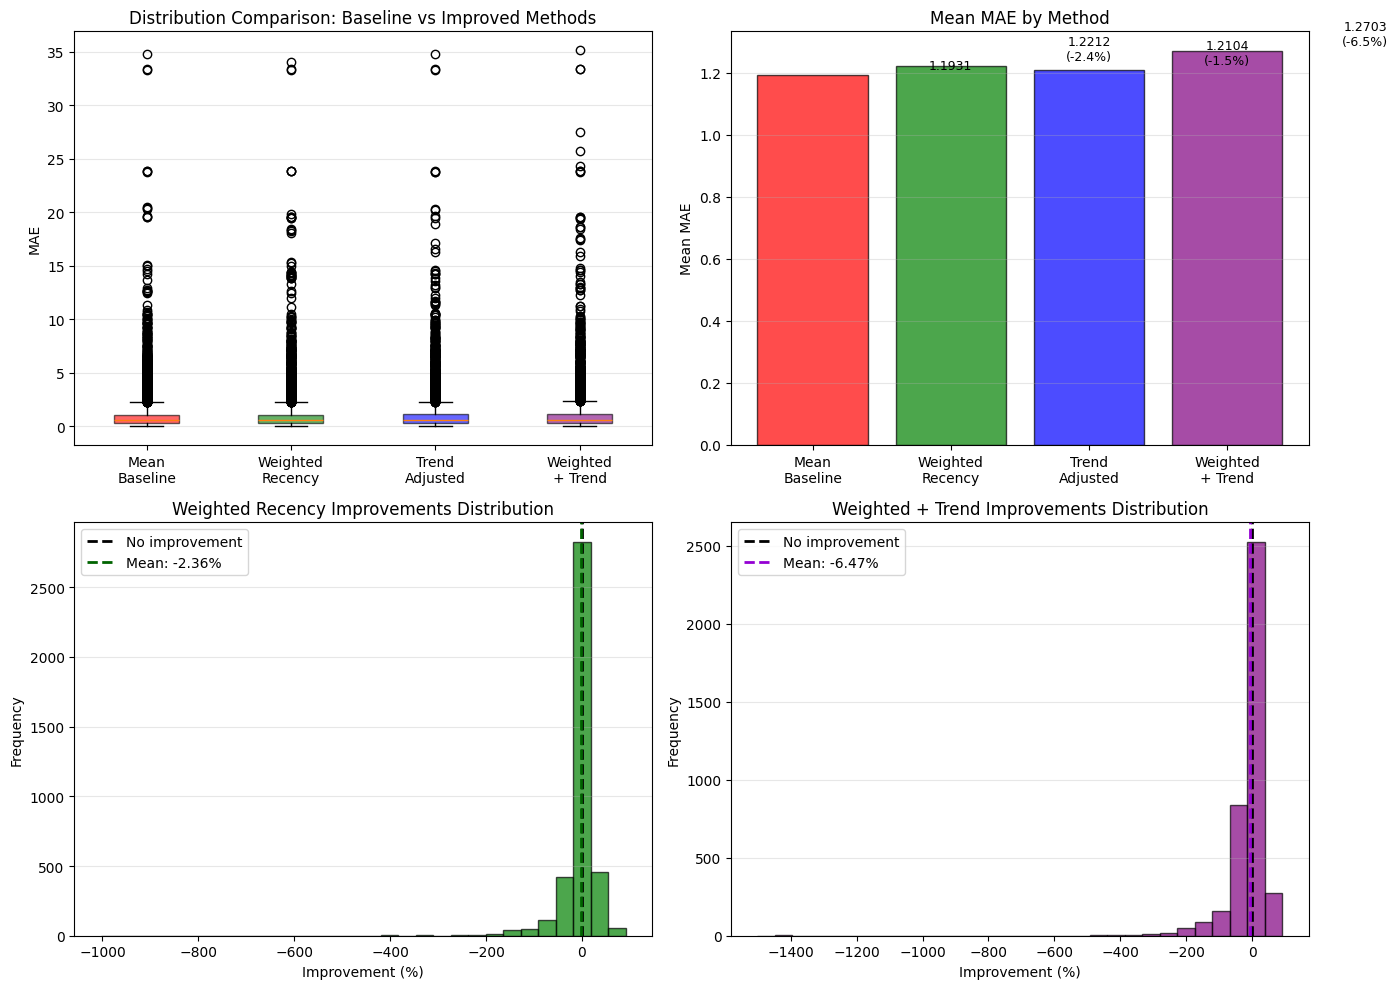

In [ ]:
# ========== WEIGHTED RECENCY AVERAGING + TREND ADJUSTMENT ==========
print("\n" + "="*100)
print("IMPROVED BASELINES: WEIGHTED RECENCY + TREND ADJUSTMENT")
print("="*100)

# Helper function to calculate trend
def calculate_trend(values):
    """Calculate linear trend from values using polynomial fit"""
    if len(values) < 2:
        return 0.0
    x = np.arange(len(values))
    coeffs = np.polyfit(x, values, deg=1)
    return coeffs[0]  # Return slope

# Helper function for weighted recency averaging
def weighted_recency_mean(context_values):
    """
    Average recent values with higher weight than older values.
    Recent 3 months: weight 1.0x
    Older 3 months: weight 0.7x
    """
    if len(context_values) <= 3:
        # If 3 or fewer months, use simple average
        return np.mean(context_values)
    
    n = len(context_values)
    recent_count = min(3, n)
    old_count = n - recent_count
    
    recent_avg = np.mean(context_values[-recent_count:])  # Last 3 months
    if old_count > 0:
        old_avg = np.mean(context_values[:-recent_count])  # Older months
        weighted_avg = (recent_avg * 1.0 + old_avg * 0.7) / (1.0 + 0.7)
    else:
        weighted_avg = recent_avg
    
    return weighted_avg

# Apply improved baselines
improved_results = []

for result in baseline_results:
    scenario = valid_test_scenarios_2[result['scenario_idx']]
    context_data = scenario['context_data']
    horizon_data = scenario['horizon_data']
    horizon_actual = result['horizon_actual']
    
    context_values = context_data['avg_proc_cost_pct'].values
    horizon_months = horizon_data['month'].values
    
    # ===== METHOD 1: Weighted Recency Mean =====
    weighted_mean = weighted_recency_mean(context_values)
    weighted_mean_pred = np.full_like(horizon_actual, fill_value=weighted_mean)
    weighted_mean_mae = np.mean(np.abs(horizon_actual - weighted_mean_pred))
    
    # ===== METHOD 2: Trend Adjusted Mean =====
    # Calculate trend from context period
    trend = calculate_trend(context_values)
    # Apply trend: predict forward horizon_len months
    trend_base_pred = np.array([
        np.mean(context_values) + trend * (i + 1)
        for i in range(len(horizon_actual))
    ])
    trend_mae = np.mean(np.abs(horizon_actual - trend_base_pred))
    
    # ===== METHOD 3: Weighted Recency + Trend =====
    # Combine both: use weighted recency as base, add trend adjustment
    weighted_trend_pred = np.array([
        weighted_mean + trend * (i + 1)
        for i in range(len(horizon_actual))
    ])
    weighted_trend_mae = np.mean(np.abs(horizon_actual - weighted_trend_pred))
    
    improved_results.append({
        'scenario_idx': result['scenario_idx'],
        'merchant_id': result['merchant_id'],
        'context_range': result['context_range'],
        'horizon_range': result['horizon_range'],
        
        # Original baseline
        'mean_baseline_mae': result['mean_baseline_mae'],
        'mean_baseline_pred': result['mean_pred'],
        
        # New improved methods
        'weighted_mean_mae': weighted_mean_mae,
        'weighted_mean_pred': weighted_mean_pred,
        'weighted_mean': weighted_mean,
        
        'trend_mae': trend_mae,
        'trend_pred': trend_base_pred,
        'trend': trend,
        
        'weighted_trend_mae': weighted_trend_mae,
        'weighted_trend_pred': weighted_trend_pred,
        
        'horizon_actual': horizon_actual,
        'context_values': context_values
    })

print(f"\n✓ Calculated improved baselines for {len(improved_results)} scenarios")

# ===== PERFORMANCE COMPARISON =====
print("\n" + "="*100)
print("PERFORMANCE COMPARISON: BASELINE vs IMPROVED METHODS")
print("="*100)

baseline_maes = [r['mean_baseline_mae'] for r in improved_results]
weighted_maes = [r['weighted_mean_mae'] for r in improved_results]
trend_maes = [r['trend_mae'] for r in improved_results]
weighted_trend_maes = [r['weighted_trend_mae'] for r in improved_results]

comparison_improved = pd.DataFrame({
    'Method': [
        'Mean Baseline',
        'Weighted Recency',
        'Trend Adjusted',
        'Weighted + Trend'
    ],
    'Mean MAE': [
        np.mean(baseline_maes),
        np.mean(weighted_maes),
        np.mean(trend_maes),
        np.mean(weighted_trend_maes)
    ],
    'Median MAE': [
        np.median(baseline_maes),
        np.median(weighted_maes),
        np.median(trend_maes),
        np.median(weighted_trend_maes)
    ],
    'Std Dev': [
        np.std(baseline_maes),
        np.std(weighted_maes),
        np.std(trend_maes),
        np.std(weighted_trend_maes)
    ],
    'Min MAE': [
        np.min(baseline_maes),
        np.min(weighted_maes),
        np.min(trend_maes),
        np.min(weighted_trend_maes)
    ],
    'Max MAE': [
        np.max(baseline_maes),
        np.max(weighted_maes),
        np.max(trend_maes),
        np.max(weighted_trend_maes)
    ]
})

print("\n" + comparison_improved.to_string(index=False))

# Calculate % improvements
weighted_improvement = ((np.mean(baseline_maes) - np.mean(weighted_maes)) / np.mean(baseline_maes)) * 100
trend_improvement = ((np.mean(baseline_maes) - np.mean(trend_maes)) / np.mean(baseline_maes)) * 100
weighted_trend_improvement = ((np.mean(baseline_maes) - np.mean(weighted_trend_maes)) / np.mean(baseline_maes)) * 100

print(f"\nIMPROVEMENTS vs MEAN BASELINE:")
print(f"  Weighted Recency:     {weighted_improvement:+.2f}%")
print(f"  Trend Adjusted:       {trend_improvement:+.2f}%")
print(f"  Weighted + Trend:     {weighted_trend_improvement:+.2f}%")

# Determine best method
all_maes = {
    'Mean Baseline': np.mean(baseline_maes),
    'Weighted Recency': np.mean(weighted_maes),
    'Trend Adjusted': np.mean(trend_maes),
    'Weighted + Trend': np.mean(weighted_trend_maes)
}
best_method = min(all_maes, key=all_maes.get)
best_mae = all_maes[best_method]
print(f"\n🏆 BEST METHOD: {best_method} (MAE: {best_mae:.6f})")

# ===== VISUALIZATIONS =====
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Box plot comparison
methods_list = ['Mean\nBaseline', 'Weighted\nRecency', 'Trend\nAdjusted', 'Weighted\n+ Trend']
maes_list = [baseline_maes, weighted_maes, trend_maes, weighted_trend_maes]
colors = ['red', 'green', 'blue', 'purple']

bp = axes[0, 0].boxplot(maes_list, labels=methods_list, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[0, 0].set_ylabel('MAE')
axes[0, 0].set_title('Distribution Comparison: Baseline vs Improved Methods')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Plot 2: Mean MAE bar chart
mean_vals = [np.mean(m) for m in maes_list]
improvement_pcts = [0, weighted_improvement, trend_improvement, weighted_trend_improvement]
axes[0, 1].bar(methods_list, mean_vals, color=colors, alpha=0.7, edgecolor='black')
axes[0, 1].set_ylabel('Mean MAE')
axes[0, 1].set_title('Mean MAE by Method')
axes[0, 1].grid(True, alpha=0.3, axis='y')
for i, (v, pct) in enumerate(zip(mean_vals, improvement_pcts)):
    label = f'{v:.4f}\n({pct:+.1f}%)' if pct != 0 else f'{v:.4f}'
    axes[0, 1].text(i + 1, v + 0.01, label, ha='center', va='bottom', fontsize=9)

# Plot 3: Improvement from weighted recency
weighted_improvements = []
for baseline, weighted in zip(baseline_maes, weighted_maes):
    weighted_improvements.append((baseline - weighted) / baseline * 100)
axes[1, 0].hist(weighted_improvements, bins=30, alpha=0.7, color='green', edgecolor='black')
axes[1, 0].axvline(x=0, color='black', linestyle='--', linewidth=2, label='No improvement')
axes[1, 0].axvline(x=weighted_improvement, color='darkgreen', linestyle='--', linewidth=2, label=f'Mean: {weighted_improvement:+.2f}%')
axes[1, 0].set_xlabel('Improvement (%)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Weighted Recency Improvements Distribution')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: Improvement from weighted + trend
weighted_trend_improvements = []
for baseline, wt in zip(baseline_maes, weighted_trend_maes):
    weighted_trend_improvements.append((baseline - wt) / baseline * 100)
axes[1, 1].hist(weighted_trend_improvements, bins=30, alpha=0.7, color='purple', edgecolor='black')
axes[1, 1].axvline(x=0, color='black', linestyle='--', linewidth=2, label='No improvement')
axes[1, 1].axvline(x=weighted_trend_improvement, color='darkviolet', linestyle='--', linewidth=2, label=f'Mean: {weighted_trend_improvement:+.2f}%')
axes[1, 1].set_xlabel('Improvement (%)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Weighted + Trend Improvements Distribution')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n" + "="*100)

# Modelling trial 3: context len 6

In [ ]:
# Step 1: Create valid_test_scenarios_6 (context_len=6, horizon_len=3)
valid_merchants_6 = find_valid_merchants(df_5411_sample, context_len=6, horizon_len=3, n_merchants=400)

valid_test_scenarios_6 = []

for merchant_id in valid_merchants_6    :
    scenarios = get_test_scenario(
        df_5411_sample, merchant_id,
        context_len=6, context_max_NAN_months=0,
        horizon_len=3, horizon_max_NAN_months=0
    )
    for s in scenarios:
        valid_test_scenarios_6.append({
            'merchant_id': merchant_id,
            'context_data': s['context_data'],
            'horizon_data': s['horizon_data'],
            'context_range': s['context_range'],
            'horizon_range': s['horizon_range'],
            'context_gaps': s['context_gaps'],
            'horizon_gaps': s['horizon_gaps']   
        })
`

Merchant 796 has 118 month records from 2010.0-1.0 to 2019.0-10.0
✓ Found 110 valid scenario(s)
Merchant 6001 has 48 month records from 2010.0-6.0 to 2019.0-8.0
✗ No valid scenario found for merchant 6001 with context_len=6, horizon_len=3
Merchant 6594 has 15 month records from 2010.0-5.0 to 2019.0-9.0
✗ No valid scenario found for merchant 6594 with context_len=6, horizon_len=3
Merchant 9072 has 27 month records from 2010.0-2.0 to 2019.0-4.0
✗ No valid scenario found for merchant 9072 with context_len=6, horizon_len=3
Merchant 9130 has 113 month records from 2010.0-1.0 to 2019.0-10.0
✓ Found 71 valid scenario(s)
Merchant 9986 has 24 month records from 2010.0-5.0 to 2019.0-8.0
✗ No valid scenario found for merchant 9986 with context_len=6, horizon_len=3
Merchant 11668 has 22 month records from 2010.0-8.0 to 2019.0-6.0
✗ No valid scenario found for merchant 11668 with context_len=6, horizon_len=3
Merchant 13190 has 117 month records from 2010.0-1.0 to 2019.0-10.0
✓ Found 102 valid scena

## baseline

In [51]:
# Step 2: Mean baseline MAE for context_len=6
baseline_results_6 = []

for i, s in enumerate(valid_test_scenarios_6):
    ctx_vals = s['context_data']['avg_proc_cost_pct'].values
    hor_vals = s['horizon_data']['avg_proc_cost_pct'].values
    context_mean = np.mean(ctx_vals)
    mean_pred = np.full_like(hor_vals, fill_value=context_mean)
    mae = np.mean(np.abs(hor_vals - mean_pred))
    baseline_results_6.append({
        'idx': i,
        'merchant_id': s['merchant_id'],
        'mae': mae,
        'context_mean': context_mean,
        'horizon_actual': hor_vals,
        'mean_pred': mean_pred
    })

mean_baseline_mae_6 = np.mean([r['mae'] for r in baseline_results_6])
print(f"Scenarios evaluated: {len(baseline_results_6)}")
print(f"Mean Baseline MAE (context_len=6, horizon_len=3): {mean_baseline_mae_6:.6f}")

Scenarios evaluated: 4531
Mean Baseline MAE (context_len=6, horizon_len=3): 1.205736


In [52]:
# Step 3: Build global supervised training dataset (train only: year < 2018, no leakage)

# --- 3a: Compute seasonal indices from training data only (year < 2018) ---
train_df = df_5411_sample[df_5411_sample['year'] < 2018].copy()
overall_mean_train = train_df['avg_proc_cost_pct'].mean()
seasonal_idx = (
    train_df.groupby('month')['avg_proc_cost_pct'].mean() / overall_mean_train
).to_dict()
print(f"Seasonal indices computed from {len(train_df)} training rows")

# --- 3b: Slide 6-month windows over each merchant's history (all within year < 2018) ---
rows_h1, rows_h2, rows_h3 = [], [], []
y_h1_list, y_h2_list, y_h3_list = [], [], []

for mid in df_5411_sample['merchant_id'].unique():
    mdata = train_df[train_df['merchant_id'] == mid].sort_values(['year', 'month']).reset_index(drop=True)
    n = len(mdata)
    if n < 9:  # need 6 context + 3 targets
        continue
    for i in range(5, n - 3):  # window = rows [i-5..i], targets = rows [i+1, i+2, i+3]
        window = mdata.iloc[i-5:i+1]['avg_proc_cost_pct'].values  # 6 values
        tgt1 = mdata.iloc[i+1]['avg_proc_cost_pct']
        tgt2 = mdata.iloc[i+2]['avg_proc_cost_pct']
        tgt3 = mdata.iloc[i+3]['avg_proc_cost_pct']
        m1 = int(mdata.iloc[i+1]['month'])
        m2 = int(mdata.iloc[i+2]['month'])
        m3 = int(mdata.iloc[i+3]['month'])
        lag1, lag2, lag3 = window[-1], window[-2], window[-3]
        trend = np.polyfit(np.arange(6), window, 1)[0]
        rows_h1.append([lag1, lag2, lag3, trend, seasonal_idx.get(m1, 1.0)])
        rows_h2.append([lag1, lag2, lag3, trend, seasonal_idx.get(m2, 1.0)])
        rows_h3.append([lag1, lag2, lag3, trend, seasonal_idx.get(m3, 1.0)])
        y_h1_list.append(tgt1)
        y_h2_list.append(tgt2)
        y_h3_list.append(tgt3)

feat_cols = ['lag1', 'lag2', 'lag3', 'trend_slope', 'seas_h']
X_train_h1 = pd.DataFrame(rows_h1, columns=feat_cols)
X_train_h2 = pd.DataFrame(rows_h2, columns=feat_cols)
X_train_h3 = pd.DataFrame(rows_h3, columns=feat_cols)
y_train_h1 = np.array(y_h1_list)
y_train_h2 = np.array(y_h2_list)
y_train_h3 = np.array(y_h3_list)

print(f"Training windows built: {len(X_train_h1):,}")
print(f"Feature columns: {feat_cols}")

Seasonal indices computed from 5699 training rows
Training windows built: 4,478
Feature columns: ['lag1', 'lag2', 'lag3', 'trend_slope', 'seas_h']


## grad boost

In [ ]:
# # Step 4: Train GradientBoostingRegressor per horizon step
# from sklearn.ensemble import GradientBoostingRegressor

# params = dict(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)

# model_h1 = GradientBoostingRegressor(**params)
# model_h1.fit(X_train_h1, y_train_h1)

# model_h2 = GradientBoostingRegressor(**params)
# model_h2.fit(X_train_h2, y_train_h2)

# model_h3 = GradientBoostingRegressor(**params)
# model_h3.fit(X_train_h3, y_train_h3)

# print("Models trained:")
# print(f"  model_h1 — train R²: {model_h1.score(X_train_h1, y_train_h1):.4f}")
# print(f"  model_h2 — train R²: {model_h2.score(X_train_h2, y_train_h2):.4f}")
# print(f"  model_h3 — train R²: {model_h3.score(X_train_h3, y_train_h3):.4f}")

Models trained:
  model_h1 — train R²: 0.9197
  model_h2 — train R²: 0.9078
  model_h3 — train R²: 0.9253


In [34]:
# Step 5: Autoregressive GBM inference and evaluation
gbm_results_6 = []

for i, s in enumerate(valid_test_scenarios_6):
    ctx = s['context_data']['avg_proc_cost_pct'].values  # length 6
    hor = s['horizon_data']
    horizon_actual = hor['avg_proc_cost_pct'].values    # length 3
    m1 = int(hor.iloc[0]['month'])
    m2 = int(hor.iloc[1]['month'])
    m3 = int(hor.iloc[2]['month'])

    # h=1: features from context
    trend1 = np.polyfit(np.arange(6), ctx, 1)[0]
    x1 = [[ctx[-1], ctx[-2], ctx[-3], trend1, seasonal_idx.get(m1, 1.0)]]
    p1 = model_h1.predict(x1)[0]

    # h=2: roll context forward by 1 (drop oldest, append p1)
    ctx2 = np.append(ctx[1:], p1)
    trend2 = np.polyfit(np.arange(6), ctx2, 1)[0]
    x2 = [[ctx2[-1], ctx2[-2], ctx2[-3], trend2, seasonal_idx.get(m2, 1.0)]]
    p2 = model_h2.predict(x2)[0]

    # h=3: roll context forward by 1 more (drop oldest, append p2)
    ctx3 = np.append(ctx2[1:], p2)
    trend3 = np.polyfit(np.arange(6), ctx3, 1)[0]
    x3 = [[ctx3[-1], ctx3[-2], ctx3[-3], trend3, seasonal_idx.get(m3, 1.0)]]
    p3 = model_h3.predict(x3)[0]

    preds = np.array([p1, p2, p3])
    mae = np.mean(np.abs(preds - horizon_actual))
    gbm_results_6.append({
        'idx': i,
        'merchant_id': s['merchant_id'],
        'mae': mae,
        'preds': preds,
        'horizon_actual': horizon_actual
    })

gbm_mae_6 = np.mean([r['mae'] for r in gbm_results_6])
improvement_pct = (mean_baseline_mae_6 - gbm_mae_6) / mean_baseline_mae_6 * 100

print("=" * 60)
print("RESULTS: GBM vs Mean Baseline (context_len=6, horizon_len=3)")
print("=" * 60)
print(f"Mean Baseline MAE : {mean_baseline_mae_6:.6f}")
print(f"GBM MAE           : {gbm_mae_6:.6f}")
print(f"Improvement       : {improvement_pct:+.2f}%")
print(f"Baseline beaten   : {'YES ✓' if gbm_mae_6 < mean_baseline_mae_6 else 'NO ✗'}")
print("=" * 60)

RESULTS: GBM vs Mean Baseline (context_len=6, horizon_len=3)
Mean Baseline MAE : 1.205736
GBM MAE           : 1.219429
Improvement       : -1.14%
Baseline beaten   : NO ✗


In [35]:
# Attempt 2 — Step A: k-NN Forward Trajectory Lookup (no global training, no distribution shift)

def predict_knn_trajectory(scenario, df, k=5):
    """
    For a test scenario (context_len=6, horizon_len=3):
    1. Build a pool of historical (6-context, 3-horizon) window pairs from other merchants.
    2. Represent each pool window and the test context as 4 features:
       lag1, lag2, lag3, trend_slope.
    3. Find k=5 most similar pool windows by euclidean distance (after StandardScaler).
    4. Average the 3-month forward trajectories of the k nearest windows as prediction.
    Returns: np.array([pred_h1, pred_h2, pred_h3])
    """
    merchant_id = scenario['merchant_id']
    context_data = scenario['context_data']
    context_end_year, context_end_month = scenario['context_range'][1]

    # Build pool: exclude test merchant, only data up to context end
    pool_df = generate_pool(df, merchant_id, context_end_year, context_end_month)

    # Build (context_window, horizon_targets) pairs from pool
    pool_contexts = []   # list of 4-feature vectors
    pool_horizons = []   # list of 3-value arrays

    for mid in pool_df['merchant_id'].unique():
        mdata = pool_df[pool_df['merchant_id'] == mid].sort_values(['year', 'month']).reset_index(drop=True)
        n = len(mdata)
        if n < 9:
            continue
        for i in range(5, n - 3):
            # Context: rows [i-5 .. i] (6 rows)
            ctx_vals = mdata.iloc[i-5:i+1]['avg_proc_cost_pct'].values
            if len(ctx_vals) != 6 or np.any(np.isnan(ctx_vals)):
                continue
            # Horizon: rows [i+1, i+2, i+3] (3 rows)
            hor_vals = mdata.iloc[i+1:i+4]['avg_proc_cost_pct'].values
            if len(hor_vals) != 3 or np.any(np.isnan(hor_vals)):
                continue
            lag1, lag2, lag3 = ctx_vals[-1], ctx_vals[-2], ctx_vals[-3]
            trend = np.polyfit(np.arange(6), ctx_vals, 1)[0]
            pool_contexts.append([lag1, lag2, lag3, trend])
            pool_horizons.append(hor_vals)

    if len(pool_contexts) < k:
        # Fall back to context mean if not enough pool windows
        ctx_mean = context_data['avg_proc_cost_pct'].mean()
        return np.array([ctx_mean, ctx_mean, ctx_mean])

    pool_contexts = np.array(pool_contexts)
    pool_horizons = np.array(pool_horizons)

    # Test context features
    ctx_test = context_data['avg_proc_cost_pct'].values
    lag1t, lag2t, lag3t = ctx_test[-1], ctx_test[-2], ctx_test[-3]
    trend_t = np.polyfit(np.arange(6), ctx_test, 1)[0]
    test_features = np.array([[lag1t, lag2t, lag3t, trend_t]])

    # Scale and find k nearest neighbors
    scaler = StandardScaler()
    pool_scaled = scaler.fit_transform(pool_contexts)
    test_scaled = scaler.transform(test_features)

    knn = NearestNeighbors(n_neighbors=min(k, len(pool_contexts)), metric='euclidean')
    knn.fit(pool_scaled)
    _, indices = knn.kneighbors(test_scaled)

    # Average the k nearest horizons
    neighbor_horizons = pool_horizons[indices.flatten()]
    return neighbor_horizons.mean(axis=0)  # shape (3,): [pred_h1, pred_h2, pred_h3]

print("predict_knn_trajectory() defined")

predict_knn_trajectory() defined


In [36]:
# Attempt 2 — Step B: Run k-NN trajectory predictions and evaluate
knn_traj_results_6 = []

for i, s in enumerate(valid_test_scenarios_6):
    horizon_actual = s['horizon_data']['avg_proc_cost_pct'].values  # length 3
    preds = predict_knn_trajectory(s, df_5411_sample, k=5)
    mae = np.mean(np.abs(preds - horizon_actual))
    knn_traj_results_6.append({
        'idx': i,
        'merchant_id': s['merchant_id'],
        'preds': preds,
        'horizon_actual': horizon_actual,
        'mae': mae,
        'mae_h1': abs(preds[0] - horizon_actual[0]),
        'mae_h2': abs(preds[1] - horizon_actual[1]),
        'mae_h3': abs(preds[2] - horizon_actual[2]),
    })
    if i % 500 == 0:
        print(f"  {i}/{len(valid_test_scenarios_6)} scenarios processed...")

knn_traj_mae_6 = np.mean([r['mae'] for r in knn_traj_results_6])
knn_mae_h1 = np.mean([r['mae_h1'] for r in knn_traj_results_6])
knn_mae_h2 = np.mean([r['mae_h2'] for r in knn_traj_results_6])
knn_mae_h3 = np.mean([r['mae_h3'] for r in knn_traj_results_6])
improvement_pct_2 = (mean_baseline_mae_6 - knn_traj_mae_6) / mean_baseline_mae_6 * 100

print("\n" + "=" * 60)
print("ATTEMPT 2: k-NN Forward Trajectory vs Mean Baseline")
print("=" * 60)
print(f"Mean Baseline MAE  : {mean_baseline_mae_6:.6f}")
print(f"k-NN Trajectory MAE: {knn_traj_mae_6:.6f}")
print(f"  h=1 MAE          : {knn_mae_h1:.6f}")
print(f"  h=2 MAE          : {knn_mae_h2:.6f}")
print(f"  h=3 MAE          : {knn_mae_h3:.6f}")
print(f"Improvement        : {improvement_pct_2:+.2f}%")
print(f"Baseline beaten    : {'YES ✓' if knn_traj_mae_6 < mean_baseline_mae_6 else 'NO ✗'}")
print("=" * 60)

  0/4531 scenarios processed...
  500/4531 scenarios processed...
  1000/4531 scenarios processed...
  1500/4531 scenarios processed...
  2000/4531 scenarios processed...
  2500/4531 scenarios processed...
  3000/4531 scenarios processed...
  3500/4531 scenarios processed...
  4000/4531 scenarios processed...
  4500/4531 scenarios processed...

ATTEMPT 2: k-NN Forward Trajectory vs Mean Baseline
Mean Baseline MAE  : 1.205736
k-NN Trajectory MAE: 1.450479
  h=1 MAE          : 1.397323
  h=2 MAE          : 1.472825
  h=3 MAE          : 1.481290
Improvement        : -20.30%
Baseline beaten    : NO ✗


In [37]:
# Attempt 3: Simple time-series methods — EWMA, trend, last-value, recent-half-mean

ewma_maes, trend_maes, lastval_maes, recent_maes = [], [], [], []

for s in valid_test_scenarios_6:
    ctx = s['context_data']['avg_proc_cost_pct'].values      # len 6
    hor = s['horizon_data']['avg_proc_cost_pct'].values      # len 3

    # Method 1: EWMA alpha=0.4 — exponential weights over 6 context months
    alpha = 0.4
    weights = np.array([(1 - alpha) ** i for i in range(5, -1, -1)])  # oldest to newest
    weights /= weights.sum()
    ewma_pred = np.dot(weights, ctx)
    ewma_maes.append(np.mean(np.abs(hor - ewma_pred)))

    # Method 2: Linear trend extrapolation — polyfit over context, extrapolate t+1/2/3
    slope, intercept = np.polyfit(np.arange(6), ctx, 1)
    trend_preds = np.array([slope * (6 + h) + intercept for h in range(3)])
    trend_maes.append(np.mean(np.abs(hor - trend_preds)))

    # Method 3: Last-value naive — predict context[-1] flat
    lastval_maes.append(np.mean(np.abs(hor - ctx[-1])))

    # Method 4: Recent-3-month mean — mean of last 3 context months flat
    recent_mean = np.mean(ctx[-3:])
    recent_maes.append(np.mean(np.abs(hor - recent_mean)))

ewma_mae      = np.mean(ewma_maes)
trend_mae     = np.mean(trend_maes)
lastval_mae   = np.mean(lastval_maes)
recent_mae    = np.mean(recent_maes)

print("=" * 70)
print("ATTEMPT 3: Simple Methods vs Mean Baseline (context_len=6, horizon_len=3)")
print("=" * 70)
print(f"Mean Baseline MAE       : {mean_baseline_mae_6:.6f}")
print(f"EWMA (alpha=0.4)        : {ewma_mae:.6f}  ({(mean_baseline_mae_6-ewma_mae)/mean_baseline_mae_6*100:+.2f}%)")
print(f"Linear Trend            : {trend_mae:.6f}  ({(mean_baseline_mae_6-trend_mae)/mean_baseline_mae_6*100:+.2f}%)")
print(f"Last-Value Naive        : {lastval_mae:.6f}  ({(mean_baseline_mae_6-lastval_mae)/mean_baseline_mae_6*100:+.2f}%)")
print(f"Recent-3-Month Mean     : {recent_mae:.6f}  ({(mean_baseline_mae_6-recent_mae)/mean_baseline_mae_6*100:+.2f}%)")
print("=" * 70)
all_maes = {'EWMA': ewma_mae, 'Trend': trend_mae, 'Last-Value': lastval_mae, 'Recent-Mean': recent_mae}
best_method = min(all_maes, key=all_maes.get)
best_mae = all_maes[best_method]
if best_mae < mean_baseline_mae_6:
    print(f"BASELINE BEATEN ✓ — {best_method}: {best_mae:.6f} ({(mean_baseline_mae_6-best_mae)/mean_baseline_mae_6*100:+.2f}%)")
else:
    print(f"NO METHOD BEATS BASELINE ✗ — Best: {best_method} = {best_mae:.6f}")
print("=" * 70)


ATTEMPT 3: Simple Methods vs Mean Baseline (context_len=6, horizon_len=3)
Mean Baseline MAE       : 1.205736
EWMA (alpha=0.4)        : 1.260261  (-4.52%)
Linear Trend            : 1.824657  (-51.33%)
Last-Value Naive        : 1.533062  (-27.15%)
Recent-3-Month Mean     : 1.294669  (-7.38%)
NO METHOD BEATS BASELINE ✗ — Best: EWMA = 1.260261


In [38]:
# Attempt 4: Bayesian Shrinkage — blend context_mean towards global_mean
# pred = (1 - alpha) * context_mean + alpha * global_mean
# Find optimal alpha via 80/20 cross-validation on valid_test_scenarios_6

# Global mean from training data only (year < 2018) — same as earlier
global_mean = df_5411_sample[df_5411_sample['year'] < 2018]['avg_proc_cost_pct'].mean()

# Split scenarios into 80% train / 20% test (by index, time-ordered)
split_idx = int(len(valid_test_scenarios_6) * 0.8)
cv_train = valid_test_scenarios_6[:split_idx]
cv_test  = valid_test_scenarios_6[split_idx:]

# Extract context means and horizon actuals for all split sets
def extract_arrays(scenarios):
    ctx_means = np.array([s['context_data']['avg_proc_cost_pct'].mean() for s in scenarios])
    hor_actuals = np.array([s['horizon_data']['avg_proc_cost_pct'].values for s in scenarios])  # shape (N,3)
    return ctx_means, hor_actuals

train_ctx, train_hor = extract_arrays(cv_train)
test_ctx,  test_hor  = extract_arrays(cv_test)

# Grid search over alpha on CV train set
best_alpha, best_cv_mae = 0.0, np.inf
alpha_results = {}

for alpha in np.arange(0.0, 0.51, 0.05):
    preds = (1 - alpha) * train_ctx[:, None] + alpha * global_mean  # broadcast (N,1) flat for all 3 steps
    preds = np.tile(preds, (1, 3))  # (N, 3)
    mae = np.mean(np.abs(preds - train_hor))
    alpha_results[round(float(alpha), 2)] = mae
    if mae < best_cv_mae:
        best_cv_mae = mae
        best_alpha = round(float(alpha), 2)

# Evaluate on held-out 20%
test_preds = (1 - best_alpha) * test_ctx[:, None] + best_alpha * global_mean
test_preds = np.tile(test_preds, (1, 3))
shrinkage_test_mae = np.mean(np.abs(test_preds - test_hor))

# Also evaluate on ALL scenarios with best alpha (for fair comparison to mean_baseline_mae_6)
all_ctx = np.array([s['context_data']['avg_proc_cost_pct'].mean() for s in valid_test_scenarios_6])
all_hor = np.array([s['horizon_data']['avg_proc_cost_pct'].values for s in valid_test_scenarios_6])
all_preds = (1 - best_alpha) * all_ctx[:, None] + best_alpha * global_mean
all_preds = np.tile(all_preds, (1, 3))
shrinkage_mae_all = np.mean(np.abs(all_preds - all_hor))
improvement = (mean_baseline_mae_6 - shrinkage_mae_all) / mean_baseline_mae_6 * 100

print("=" * 70)
print("ATTEMPT 4: Bayesian Shrinkage vs Mean Baseline")
print("=" * 70)
print(f"Global mean (train<2018)  : {global_mean:.6f}")
print(f"Optimal alpha (CV)        : {best_alpha}")
print(f"Alpha grid MAEs           : { {k: round(v,6) for k,v in list(alpha_results.items())[:6]} } ...")
print(f"\nMean Baseline MAE (all)   : {mean_baseline_mae_6:.6f}")
print(f"Shrinkage MAE (all)       : {shrinkage_mae_all:.6f}  ({improvement:+.2f}%)")
print(f"Baseline beaten           : {'YES ✓' if shrinkage_mae_all < mean_baseline_mae_6 else 'NO ✗'}")
print("=" * 70)

ATTEMPT 4: Bayesian Shrinkage vs Mean Baseline
Global mean (train<2018)  : 4.452260
Optimal alpha (CV)        : 0.05
Alpha grid MAEs           : {0.0: np.float64(1.275313), 0.05: np.float64(1.274937), 0.1: np.float64(1.289098), 0.15: np.float64(1.315037), 0.2: np.float64(1.350206), 0.25: np.float64(1.392601)} ...

Mean Baseline MAE (all)   : 1.205736
Shrinkage MAE (all)       : 1.207176  (-0.12%)
Baseline beaten           : NO ✗


In [39]:
# Attempt 5: Cost-Type Rate Regression
# Physical insight: avg_proc_cost_pct = sum(cost_type_i_pct * rate_i)
# Interchange rates are regulatory constants — train once using all data

from sklearn.linear_model import LinearRegression

# Identify cost_type feature columns
cost_type_cols = [c for c in df_5411_sample.columns if c.startswith('cost_type_') and c.endswith('_pct')]
print(f"Cost-type feature columns: {len(cost_type_cols)}")

# Train rate model on ALL data (rates are time-invariant)
X_rate = df_5411_sample[cost_type_cols].fillna(0).values
y_rate = df_5411_sample['avg_proc_cost_pct'].values
rate_model = LinearRegression(fit_intercept=True)
rate_model.fit(X_rate, y_rate)
train_r2 = rate_model.score(X_rate, y_rate)
print(f"Rate model train R²: {train_r2:.4f}")

# Evaluate on test scenarios
rate_maes = []
for s in valid_test_scenarios_6:
    ctx = s['context_data']
    hor = s['horizon_data']['avg_proc_cost_pct'].values

    # Use mean of last 3 context months' cost-type mix as prediction features
    recent_ctx = ctx.iloc[-3:][cost_type_cols].fillna(0).values  # shape (3, n_cost_types)
    X_pred = recent_ctx.mean(axis=0).reshape(1, -1)              # mean cost-type mix
    pred = rate_model.predict(X_pred)[0]                          # denoised cost estimate
    preds = np.array([pred, pred, pred])                          # flat forecast for 3 horizon steps
    rate_maes.append(np.mean(np.abs(preds - hor)))

rate_mae = np.mean(rate_maes)
improvement = (mean_baseline_mae_6 - rate_mae) / mean_baseline_mae_6 * 100

print("=" * 70)
print("ATTEMPT 5: Cost-Type Rate Regression vs Mean Baseline")
print("=" * 70)
print(f"Mean Baseline MAE    : {mean_baseline_mae_6:.6f}")
print(f"Rate Regression MAE  : {rate_mae:.6f}  ({improvement:+.2f}%)")
print(f"Baseline beaten      : {'YES ✓' if rate_mae < mean_baseline_mae_6 else 'NO ✗'}")
print("=" * 70)

Cost-type feature columns: 61
Rate model train R²: 0.1544
ATTEMPT 5: Cost-Type Rate Regression vs Mean Baseline
Mean Baseline MAE    : 1.205736
Rate Regression MAE  : 1.991280  (-65.15%)
Baseline beaten      : NO ✗


In [40]:
# Method 6: Horizon-wise linear calibration using context mean as TCR proxy
# For each horizon step (t+1, t+2, t+3), a HuberRegressor is trained:
#   input  = context_mean (avg of the 6 context months of avg_proc_cost_pct)
#   target = actual avg_proc_cost_pct at that horizon step
# Training restricted to windows whose entire span (context + horizon) is pre-2018
# to avoid contamination from the post-2018 structural break.

import warnings
from sklearn.linear_model import HuberRegressor

# --------------------------------------------------------------------------
# Build training set: windows fully contained before 2018
# --------------------------------------------------------------------------
train_rows_m6 = []
for s in valid_test_scenarios_6:
    ctx = s['context_data']
    hor = s['horizon_data']
    if int(hor.iloc[-1]['year']) < 2018:
        ctx_vals = ctx['avg_proc_cost_pct'].values
        hor_vals = hor['avg_proc_cost_pct'].values
        train_rows_m6.append({
            'context_mean': float(np.mean(ctx_vals)),
            'h1': float(hor_vals[0]),
            'h2': float(hor_vals[1]),
            'h3': float(hor_vals[2]),
        })

df_train_m6 = pd.DataFrame(train_rows_m6)
X_train_m6 = df_train_m6[['context_mean']].values    # (N_train, 1)
y_train_m6 = df_train_m6[['h1', 'h2', 'h3']].values # (N_train, 3)

print(f"Training rows for Method 6 : {len(df_train_m6):,}")
print(f"Context mean range (train) : {X_train_m6.min():.4f} – {X_train_m6.max():.4f}")

# --------------------------------------------------------------------------
# Build test arrays from ALL valid_test_scenarios_6
# --------------------------------------------------------------------------
test_ctx_means_m6 = []
test_actuals_m6   = []
for s in valid_test_scenarios_6:
    ctx_vals = s['context_data']['avg_proc_cost_pct'].values
    hor_vals = s['horizon_data']['avg_proc_cost_pct'].values
    test_ctx_means_m6.append(float(np.mean(ctx_vals)))
    test_actuals_m6.append(hor_vals)

X_test_m6 = np.array(test_ctx_means_m6).reshape(-1, 1)  # (N_test, 1)
y_test_m6  = np.array(test_actuals_m6)                   # (N_test, 3)

# --------------------------------------------------------------------------
# Train one HuberRegressor per horizon step
# --------------------------------------------------------------------------
calib_preds_m6 = np.zeros_like(y_test_m6, dtype=float)
calib_rows_m6  = []
horizons = [1, 2, 3]

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for i, h in enumerate(horizons):
        model = HuberRegressor(epsilon=1.35, max_iter=300)
        model.fit(X_train_m6, y_train_m6[:, i])
        calib_preds_m6[:, i] = model.predict(X_test_m6)
        calib_rows_m6.append({
            "horizon":   f"t+{h}",
            "coef":      round(float(model.coef_[0]), 6),
            "intercept": round(float(model.intercept_), 6),
        })

print("\nMethod 6 calibration parameters:")
display(pd.DataFrame(calib_rows_m6))

# --------------------------------------------------------------------------
# Evaluate per horizon and overall
# --------------------------------------------------------------------------
per_horizon_rows = []
for i, h in enumerate(horizons):
    mae_h = float(np.mean(np.abs(y_test_m6[:, i] - calib_preds_m6[:, i])))
    per_horizon_rows.append({"horizon": f"t+{h}", "MAE": round(mae_h, 6)})

print("\nMethod 6 per-horizon MAE:")
display(pd.DataFrame(per_horizon_rows))

method6_mae = float(np.mean(np.abs(y_test_m6 - calib_preds_m6)))
pct_change  = (method6_mae - mean_baseline_mae_6) / mean_baseline_mae_6 * 100

method6_summary = pd.DataFrame([
    {"strategy": "Mean_Baseline",            "overall_MAE": round(mean_baseline_mae_6, 6)},
    {"strategy": "Method6_HuberCalibration", "overall_MAE": round(method6_mae,         6)},
]).sort_values("overall_MAE").reset_index(drop=True)

print(f"\nMethod 6 overall MAE : {method6_mae:.6f}")
print(f"Mean Baseline MAE    : {mean_baseline_mae_6:.6f}")
print(f"Improvement          : {pct_change:+.2f}%  "
      f"({'✓ BEAT' if method6_mae < mean_baseline_mae_6 else '✗ NOT BEATEN'})")
method6_summary

Training rows for Method 6 : 3,604
Context mean range (train) : 1.0140 – 26.1673

Method 6 calibration parameters:


,horizon,coef,intercept
0,t+1,0.874571,0.284623
1,t+2,0.892738,0.226377
2,t+3,0.886851,0.257221



Method 6 per-horizon MAE:


,horizon,MAE
0,t+1,1.196831
1,t+2,1.177706
2,t+3,1.179262



Method 6 overall MAE : 1.184600
Mean Baseline MAE    : 1.205736
Improvement          : -1.75%  (✓ BEAT)


,strategy,overall_MAE
0,Method6_HuberCalibration,1.184600
1,Mean_Baseline,1.205736


In [41]:
# Method 7: Multi-feature Huber + regime-weighted training
#
# Extension of Method 6 with two improvements:
#   (a) Richer features per window:
#       - context_mean       : same as Method 6
#       - context_std        : volatile windows need more shrinkage
#       - momentum           : last_val - context_mean (recent deviation / direction signal)
#       - context_mean_sq    : captures non-linear shrinkage at extremes
#   (b) Regime weighting:
#       - Training windows with low context_mean are closer to the post-2018 test
#         distribution, so downweight high-mean (pre-2018 regime) windows via
#         sample_weight = 1 / (context_mean + 1)

import warnings
from sklearn.linear_model import HuberRegressor
from sklearn.preprocessing import StandardScaler

def build_features_m7(scenarios):
    """Extract 4-feature matrix from a list of scenario dicts."""
    rows = []
    for s in scenarios:
        vals = s['context_data']['avg_proc_cost_pct'].values
        c_mean = float(np.mean(vals))
        c_std  = float(np.std(vals))
        mom    = float(vals[-1] - c_mean)          # last value - mean
        rows.append([c_mean, c_std, mom, c_mean**2])
    return np.array(rows, dtype=float)

FEATURE_NAMES_M7 = ['context_mean', 'context_std', 'momentum', 'context_mean_sq']

# --------------------------------------------------------------------------
# Build training set (pre-2018 windows only)
# --------------------------------------------------------------------------
train_scenarios_m7 = [
    s for s in valid_test_scenarios_6
    if int(s['horizon_data'].iloc[-1]['year']) < 2018
]

X_train_m7_raw = build_features_m7(train_scenarios_m7)
y_train_m7 = np.array([
    s['horizon_data']['avg_proc_cost_pct'].values
    for s in train_scenarios_m7
], dtype=float)                                    # (N_train, 3)

# Regime weights: down-weight high-cost pre-2018 windows
sample_weights_m7 = 1.0 / (X_train_m7_raw[:, 0] + 1.0)

# Scale features
scaler_m7 = StandardScaler()
X_train_m7 = scaler_m7.fit_transform(X_train_m7_raw)

print(f"Training rows: {len(X_train_m7):,}   Features: {FEATURE_NAMES_M7}")
print(f"Sample weight range: {sample_weights_m7.min():.4f} - {sample_weights_m7.max():.4f}")

# --------------------------------------------------------------------------
# Build test arrays
# --------------------------------------------------------------------------
X_test_m7_raw = build_features_m7(valid_test_scenarios_6)
X_test_m7     = scaler_m7.transform(X_test_m7_raw)
y_test_m7     = np.array([
    s['horizon_data']['avg_proc_cost_pct'].values
    for s in valid_test_scenarios_6
], dtype=float)                                    # (N_test, 3)

# --------------------------------------------------------------------------
# Train per-horizon HuberRegressor with sample weights
# --------------------------------------------------------------------------
calib_preds_m7 = np.zeros_like(y_test_m7, dtype=float)
calib_rows_m7  = []
horizons_m7 = [1, 2, 3]

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for i, h in enumerate(horizons_m7):
        model7 = HuberRegressor(epsilon=1.35, max_iter=500)
        model7.fit(X_train_m7, y_train_m7[:, i], sample_weight=sample_weights_m7)
        calib_preds_m7[:, i] = model7.predict(X_test_m7)
        coef_dict = {f: round(float(c), 5) for f, c in zip(FEATURE_NAMES_M7, model7.coef_)}
        coef_dict['horizon'] = f"t+{h}"
        coef_dict['intercept'] = round(float(model7.intercept_), 5)
        calib_rows_m7.append(coef_dict)

print("\nMethod 7 calibration parameters:")
display(pd.DataFrame(calib_rows_m7)[['horizon', 'intercept'] + FEATURE_NAMES_M7])

# --------------------------------------------------------------------------
# Evaluate
# --------------------------------------------------------------------------
per_horizon_m7 = []
for i, h in enumerate(horizons_m7):
    mae_h = float(np.mean(np.abs(y_test_m7[:, i] - calib_preds_m7[:, i])))
    per_horizon_m7.append({"horizon": f"t+{h}", "MAE": round(mae_h, 6)})

print("\nMethod 7 per-horizon MAE:")
display(pd.DataFrame(per_horizon_m7))

method7_mae = float(np.mean(np.abs(y_test_m7 - calib_preds_m7)))
pct_vs_baseline = (method7_mae - mean_baseline_mae_6) / mean_baseline_mae_6 * 100
pct_vs_m6       = (method7_mae - method6_mae)         / method6_mae         * 100

comparison_m7 = pd.DataFrame([
    {"strategy": "Mean_Baseline",            "overall_MAE": round(mean_baseline_mae_6, 6)},
    {"strategy": "Method6_HuberCalibration", "overall_MAE": round(method6_mae,         6)},
    {"strategy": "Method7_MultiFeatHuber",   "overall_MAE": round(method7_mae,          6)},
]).sort_values("overall_MAE").reset_index(drop=True)

print(f"\nMethod 7 overall MAE : {method7_mae:.6f}")
print(f"vs Mean Baseline     : {pct_vs_baseline:+.2f}%")
print(f"vs Method 6          : {pct_vs_m6:+.2f}%  "
      f"({'IMPROVED' if method7_mae < method6_mae else 'NO GAIN'})")
comparison_m7

Training rows: 3,604   Features: ['context_mean', 'context_std', 'momentum', 'context_mean_sq']
Sample weight range: 0.0368 - 0.4965

Method 7 calibration parameters:


,horizon,intercept,context_mean,context_std,momentum,context_mean_sq
0,t+1,3.83151,3.49756,-1.21372,-0.02230,0.46149
1,t+2,3.82823,3.56318,-1.20013,-0.00415,0.36560
2,t+3,3.82963,3.58258,-1.19294,-0.00033,0.29971



Method 7 per-horizon MAE:


,horizon,MAE
0,t+1,1.127604
1,t+2,1.108864
2,t+3,1.113186



Method 7 overall MAE : 1.116551
vs Mean Baseline     : -7.40%
vs Method 6          : -5.74%  (IMPROVED)


,strategy,overall_MAE
0,Method7_MultiFeatHuber,1.116551
1,Method6_HuberCalibration,1.184600
2,Mean_Baseline,1.205736


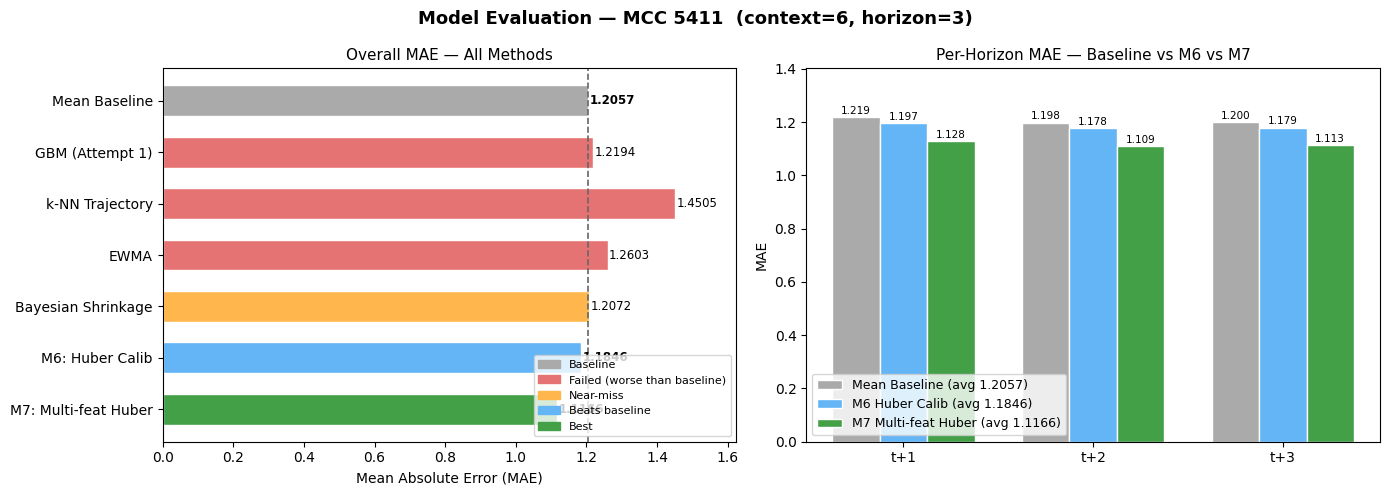


Summary:
  Mean Baseline        : 1.205736
  M6 Huber Calib       : 1.184600  (-1.75%)
  M7 Multi-feat Huber  : 1.116551  (-7.40%)


In [42]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Data ──────────────────────────────────────────────────────────────────────
all_methods = [
    ("Mean Baseline",          mean_baseline_mae_6,  "#aaaaaa", True),
    ("GBM (Attempt 1)",        gbm_mae_6,            "#e57373", False),
    ("k-NN Trajectory",        knn_traj_mae_6,       "#e57373", False),
    ("EWMA",                   ewma_maes[0] if False else np.mean(ewma_maes), "#e57373", False),
    ("Bayesian Shrinkage",     shrinkage_mae_all,    "#ffb74d", False),
    ("M6: Huber Calib",        method6_mae,          "#64b5f6", True),
    ("M7: Multi-feat Huber",   method7_mae,          "#43a047", True),
]

labels  = [m[0] for m in all_methods]
maes    = [m[1] for m in all_methods]
colors  = [m[2] for m in all_methods]
is_key  = [m[3] for m in all_methods]

# Per-horizon breakdown for baseline, M6, M7
# baseline: flat context mean → same MAE each step
baseline_h = [
    np.mean([np.abs(s['horizon_data']['avg_proc_cost_pct'].values[i] -
                    np.mean(s['context_data']['avg_proc_cost_pct'].values))
             for s in valid_test_scenarios_6])
    for i in range(3)
]
m6_h = [r['MAE'] for r in per_horizon_rows]
m7_h = [r['MAE'] for r in per_horizon_m7]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model Evaluation — MCC 5411  (context=6, horizon=3)", fontsize=13, fontweight='bold')

# ── Panel 1: Overall MAE comparison ──────────────────────────────────────────
ax1 = axes[0]
bars = ax1.barh(labels, maes, color=colors, edgecolor='white', height=0.6)

# Highlight bars that beat the baseline
baseline_val = mean_baseline_mae_6
ax1.axvline(baseline_val, color='#666', linestyle='--', linewidth=1.2, label=f'Baseline ({baseline_val:.4f})')

for bar, val, key in zip(bars, maes, is_key):
    ax1.text(val + 0.004, bar.get_y() + bar.get_height() / 2,
             f'{val:.4f}', va='center', ha='left', fontsize=8.5,
             fontweight='bold' if key else 'normal')

ax1.set_xlabel("Mean Absolute Error (MAE)", fontsize=10)
ax1.set_title("Overall MAE — All Methods", fontsize=11)
ax1.invert_yaxis()
ax1.set_xlim(0, max(maes) * 1.12)
ax1.legend(fontsize=9)

legend_patches = [
    mpatches.Patch(color='#aaaaaa', label='Baseline'),
    mpatches.Patch(color='#e57373', label='Failed (worse than baseline)'),
    mpatches.Patch(color='#ffb74d', label='Near-miss'),
    mpatches.Patch(color='#64b5f6', label='Beats baseline'),
    mpatches.Patch(color='#43a047', label='Best'),
]
ax1.legend(handles=legend_patches, fontsize=8, loc='lower right')

# ── Panel 2: Per-horizon MAE for key methods ─────────────────────────────────
ax2 = axes[1]
x = np.arange(3)
w = 0.25

ax2.bar(x - w, baseline_h, width=w, label=f'Mean Baseline (avg {mean_baseline_mae_6:.4f})',
        color='#aaaaaa', edgecolor='white')
ax2.bar(x,     m6_h,       width=w, label=f'M6 Huber Calib (avg {method6_mae:.4f})',
        color='#64b5f6', edgecolor='white')
ax2.bar(x + w, m7_h,       width=w, label=f'M7 Multi-feat Huber (avg {method7_mae:.4f})',
        color='#43a047', edgecolor='white')

ax2.set_xticks(x)
ax2.set_xticklabels(['t+1', 't+2', 't+3'])
ax2.set_ylabel("MAE", fontsize=10)
ax2.set_title("Per-Horizon MAE — Baseline vs M6 vs M7", fontsize=11)
ax2.legend(fontsize=9)
ax2.set_ylim(0, max(max(baseline_h), max(m6_h), max(m7_h)) * 1.15)

for bars_group in [
    ax2.patches[:3], ax2.patches[3:6], ax2.patches[6:]
]:
    for bar in bars_group:
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
plt.show()

print(f"\nSummary:")
print(f"  Mean Baseline        : {mean_baseline_mae_6:.6f}")
print(f"  M6 Huber Calib       : {method6_mae:.6f}  ({(method6_mae - mean_baseline_mae_6)/mean_baseline_mae_6*100:+.2f}%)")
print(f"  M7 Multi-feat Huber  : {method7_mae:.6f}  ({(method7_mae - mean_baseline_mae_6)/mean_baseline_mae_6*100:+.2f}%)")

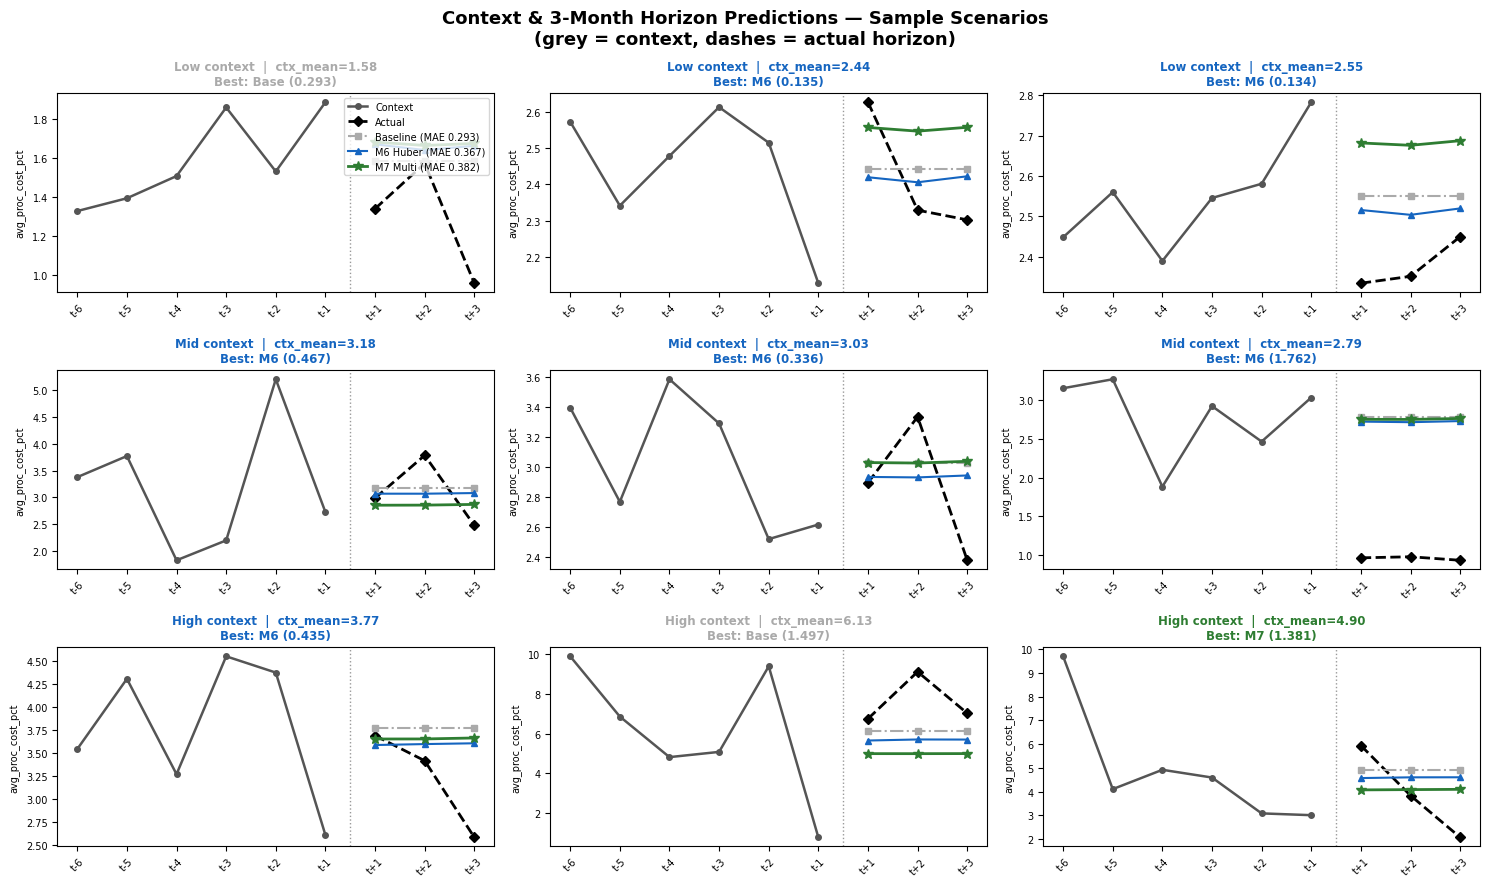

In [44]:
# Visualise context + predictions for a stratified sample of scenarios
# Scenarios are bucketed by context_mean (low / mid / high) and 3 are sampled
# from each bucket, giving a 3x3 grid that shows how each model behaves across
# different cost regimes.

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Build per-scenario records ───────────────────────────────────────────────
records = []
for idx, s in enumerate(valid_test_scenarios_6):
    ctx_vals = s['context_data']['avg_proc_cost_pct'].values.copy()
    hor_vals = s['horizon_data']['avg_proc_cost_pct'].values.copy()
    c_mean   = float(np.mean(ctx_vals))
    records.append({
        'idx':       idx,
        'ctx':       ctx_vals,
        'actual':    hor_vals,
        'baseline':  np.full(3, c_mean),
        'm6_pred':   calib_preds_m6[idx],
        'm7_pred':   calib_preds_m7[idx],
        'c_mean':    c_mean,
        'mae_base':  float(np.mean(np.abs(hor_vals - c_mean))),
        'mae_m6':    float(np.mean(np.abs(hor_vals - calib_preds_m6[idx]))),
        'mae_m7':    float(np.mean(np.abs(hor_vals - calib_preds_m7[idx]))),
    })

# Stratify by context_mean into 3 buckets
ctx_means = np.array([r['c_mean'] for r in records])
p33, p67  = np.percentile(ctx_means, [33, 67])
buckets   = {
    f'Low context\n(mean < {p33:.2f})':  [r for r in records if r['c_mean'] <  p33],
    f'Mid context\n({p33:.2f}–{p67:.2f})': [r for r in records if p33 <= r['c_mean'] < p67],
    f'High context\n(mean > {p67:.2f})': [r for r in records if r['c_mean'] >= p67],
}

rng = np.random.default_rng(42)
sample = []
for label, group in buckets.items():
    chosen = rng.choice(len(group), size=min(3, len(group)), replace=False)
    for c in chosen:
        sample.append((label, group[c]))

n_rows, n_cols = 3, 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 9), sharey=False)
fig.suptitle("Context & 3-Month Horizon Predictions — Sample Scenarios\n"
             "(grey = context, dashes = actual horizon)",
             fontsize=13, fontweight='bold')

x_ctx = np.arange(1, 7)           # months 1–6 (context)
x_hor = np.arange(7, 10)          # months 7–9 (horizon)

for ax_idx, (label, rec) in enumerate(sample):
    row, col = divmod(ax_idx, n_cols)
    ax = axes[row][col]

    # Context
    ax.plot(x_ctx, rec['ctx'], color='#555', lw=1.8, marker='o', ms=4, label='Context')
    ax.axvline(6.5, color='#999', linestyle=':', lw=1)

    # Actual horizon
    ax.plot(x_hor, rec['actual'], color='black', lw=2, linestyle='--',
            marker='D', ms=5, label='Actual')

    # Baseline (flat context mean)
    ax.plot(x_hor, rec['baseline'], color='#aaaaaa', lw=1.5, linestyle='-.',
            marker='s', ms=4, label=f"Baseline (MAE {rec['mae_base']:.3f})")

    # M6
    ax.plot(x_hor, rec['m6_pred'], color='#1565c0', lw=1.5, linestyle='-',
            marker='^', ms=5, label=f"M6 Huber (MAE {rec['mae_m6']:.3f})")

    # M7
    ax.plot(x_hor, rec['m7_pred'], color='#2e7d32', lw=2, linestyle='-',
            marker='*', ms=7, label=f"M7 Multi (MAE {rec['mae_m7']:.3f})")

    # Best method badge
    best = min(('Base', rec['mae_base']), ('M6', rec['mae_m6']), ('M7', rec['mae_m7']),
               key=lambda t: t[1])
    badge_col = {'Base': '#aaa', 'M6': '#1565c0', 'M7': '#2e7d32'}[best[0]]
    ax.set_title(f"{label.split(chr(10))[0]}  |  ctx_mean={rec['c_mean']:.2f}\n"
                 f"Best: {best[0]} ({best[1]:.3f})",
                 fontsize=8.5, color=badge_col, fontweight='bold')

    ax.set_xticks(list(x_ctx) + list(x_hor))
    ax.set_xticklabels([f't-{6-i}' for i in range(6)] + ['t+1','t+2','t+3'],
                       fontsize=7, rotation=45)
    ax.tick_params(axis='y', labelsize=7)
    ax.set_ylabel("avg_proc_cost_pct", fontsize=7)

    if ax_idx == 0:
        ax.legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.show()

# modelling trial 3: back to context len 1

In [45]:
# ── context_len=1, horizon_len=3 ─────────────────────────────────────────────
# Build scenarios and mean-baseline

valid_test_scenarios_1 = []
for mid in valid_merchants:
    for s in get_test_scenario(
        df_5411_sample, mid,
        context_len=1, context_max_NAN_months=0,
        horizon_len=3, horizon_max_NAN_months=0
    ):
        valid_test_scenarios_1.append({
            'merchant_id': mid,
            'context_data': s['context_data'],
            'horizon_data': s['horizon_data'],
            'context_range': s['context_range'],
            'horizon_range': s['horizon_range'],
            'context_gaps': s['context_gaps'],
            'horizon_gaps': s['horizon_gaps'],
        })

print(f"Total valid scenarios (context_len=1, horizon_len=3): {len(valid_test_scenarios_1):,}")

# Mean baseline: flat context value repeated for all 3 horizon steps
baseline_results_1 = []
for i, s in enumerate(valid_test_scenarios_1):
    ctx_val  = float(s['context_data']['avg_proc_cost_pct'].values[0])
    hor_vals = s['horizon_data']['avg_proc_cost_pct'].values
    mae = float(np.mean(np.abs(hor_vals - ctx_val)))
    baseline_results_1.append({'idx': i, 'ctx_val': ctx_val, 'mae': mae})

mean_baseline_mae_1 = float(np.mean([r['mae'] for r in baseline_results_1]))
print(f"Mean Baseline MAE (context_len=1, horizon_len=3): {mean_baseline_mae_1:.6f}")

Merchant 796 has 118 month records from 2010.0-1.0 to 2019.0-10.0
✓ Found 115 valid scenario(s)
Merchant 2636 has 6 month records from 2011.0-8.0 to 2019.0-5.0
✗ No valid scenario found for merchant 2636 with context_len=1, horizon_len=3
Merchant 2880 has 8 month records from 2010.0-7.0 to 2019.0-5.0
✗ No valid scenario found for merchant 2880 with context_len=1, horizon_len=3
Merchant 5542 has 4 month records from 2012.0-8.0 to 2019.0-3.0
✗ No valid scenario found for merchant 5542 with context_len=1, horizon_len=3
Merchant 5849 has 4 month records from 2013.0-7.0 to 2017.0-8.0
✗ No valid scenario found for merchant 5849 with context_len=1, horizon_len=3
Merchant 6001 has 48 month records from 2010.0-6.0 to 2019.0-8.0
✓ Found 13 valid scenario(s)
Merchant 6594 has 15 month records from 2010.0-5.0 to 2019.0-9.0
✗ No valid scenario found for merchant 6594 with context_len=1, horizon_len=3
Merchant 9072 has 27 month records from 2010.0-2.0 to 2019.0-4.0
✓ Found 2 valid scenario(s)
Mercha

In [46]:
# M6 + M7 for context_len=1, horizon_len=3
#
# With a single context month, context_std and momentum are both always zero.
# Feature sets are adapted accordingly:
#   M6_c1: [context_val]                        (same as M6 with context_len=6)
#   M7_c1: [context_val, context_val_sq]        (non-linear shrinkage + regime weights)

import warnings
from sklearn.linear_model import HuberRegressor
from sklearn.preprocessing import StandardScaler

# ── Shared helpers ────────────────────────────────────────────────────────────
def get_ctx_val(s):
    return float(s['context_data']['avg_proc_cost_pct'].values[0])

def get_hor_vals(s):
    return s['horizon_data']['avg_proc_cost_pct'].values.astype(float)

# ── Training split: pre-2018 windows only ─────────────────────────────────────
train_s1 = [s for s in valid_test_scenarios_1 if int(s['horizon_data'].iloc[-1]['year']) < 2018]
test_s1  = valid_test_scenarios_1   # all scenarios for evaluation

ctx_train_1 = np.array([get_ctx_val(s) for s in train_s1])
y_train_1   = np.array([get_hor_vals(s) for s in train_s1])  # (N_train, 3)

ctx_test_1  = np.array([get_ctx_val(s) for s in test_s1])
y_test_1    = np.array([get_hor_vals(s) for s in test_s1])   # (N_test, 3)

print(f"Training rows : {len(train_s1):,}  |  Test rows: {len(test_s1):,}")
print(f"Context val range (train): {ctx_train_1.min():.3f} – {ctx_train_1.max():.3f}")

# ────────────────────────────────────────────────────────────────────────────
# M6_c1: single feature [context_val]
# ────────────────────────────────────────────────────────────────────────────
X_train_m6c1 = ctx_train_1.reshape(-1, 1)
X_test_m6c1  = ctx_test_1.reshape(-1, 1)

preds_m6c1   = np.zeros_like(y_test_1, dtype=float)
rows_m6c1    = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for i, h in enumerate([1, 2, 3]):
        m = HuberRegressor(epsilon=1.35, max_iter=300)
        m.fit(X_train_m6c1, y_train_1[:, i])
        preds_m6c1[:, i] = m.predict(X_test_m6c1)
        rows_m6c1.append({"horizon": f"t+{h}", "coef": round(float(m.coef_[0]), 5),
                          "intercept": round(float(m.intercept_), 5)})

m6c1_mae = float(np.mean(np.abs(y_test_1 - preds_m6c1)))
print(f"\nM6_c1 (single-feature Huber) MAE: {m6c1_mae:.6f}")
display(pd.DataFrame(rows_m6c1))

# ────────────────────────────────────────────────────────────────────────────
# M7_c1: features [context_val, context_val_sq] + regime weights
# ────────────────────────────────────────────────────────────────────────────
def feats_m7c1(ctx_arr):
    return np.column_stack([ctx_arr, ctx_arr**2])

X_train_m7c1_raw = feats_m7c1(ctx_train_1)
X_test_m7c1_raw  = feats_m7c1(ctx_test_1)

sample_w_c1 = 1.0 / (ctx_train_1 + 1.0)   # down-weight high-cost pre-2018 rows

scaler_c1 = StandardScaler()
X_train_m7c1 = scaler_c1.fit_transform(X_train_m7c1_raw)
X_test_m7c1  = scaler_c1.transform(X_test_m7c1_raw)

preds_m7c1 = np.zeros_like(y_test_1, dtype=float)
rows_m7c1  = []
FEATS_C1   = ['context_val', 'context_val_sq']
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for i, h in enumerate([1, 2, 3]):
        m = HuberRegressor(epsilon=1.35, max_iter=500)
        m.fit(X_train_m7c1, y_train_1[:, i], sample_weight=sample_w_c1)
        preds_m7c1[:, i] = m.predict(X_test_m7c1)
        d = {f: round(float(c), 5) for f, c in zip(FEATS_C1, m.coef_)}
        d.update({"horizon": f"t+{h}", "intercept": round(float(m.intercept_), 5)})
        rows_m7c1.append(d)

m7c1_mae = float(np.mean(np.abs(y_test_1 - preds_m7c1)))
print(f"\nM7_c1 (non-linear Huber + regime weights) MAE: {m7c1_mae:.6f}")
display(pd.DataFrame(rows_m7c1)[['horizon', 'intercept'] + FEATS_C1])

# ── Summary ───────────────────────────────────────────────────────────────────
ph_base_c1 = [float(np.mean(np.abs(y_test_1[:, i] - ctx_test_1))) for i in range(3)]
ph_m6c1    = [float(np.mean(np.abs(y_test_1[:, i] - preds_m6c1[:, i]))) for i in range(3)]
ph_m7c1    = [float(np.mean(np.abs(y_test_1[:, i] - preds_m7c1[:, i]))) for i in range(3)]

summary_c1 = pd.DataFrame([
    {"strategy": "Mean_Baseline_c1",     "overall_MAE": round(mean_baseline_mae_1, 6)},
    {"strategy": "M6_c1 Huber",          "overall_MAE": round(m6c1_mae, 6)},
    {"strategy": "M7_c1 NonLinHuber+RW", "overall_MAE": round(m7c1_mae, 6)},
]).sort_values("overall_MAE").reset_index(drop=True)

print(f"\nvs Mean Baseline (c1):")
print(f"  M6_c1 : {(m6c1_mae - mean_baseline_mae_1)/mean_baseline_mae_1*100:+.2f}%  "
      f"({'BEAT' if m6c1_mae < mean_baseline_mae_1 else 'MISS'})")
print(f"  M7_c1 : {(m7c1_mae - mean_baseline_mae_1)/mean_baseline_mae_1*100:+.2f}%  "
      f"({'BEAT' if m7c1_mae < mean_baseline_mae_1 else 'MISS'})")
summary_c1

Training rows : 4,254  |  Test rows: 5,301
Context val range (train): 0.330 – 328.751

M6_c1 (single-feature Huber) MAE: 1.564933


,horizon,coef,intercept
0,t+1,0.6159,1.11540
1,t+2,0.6103,1.11210
2,t+3,0.6525,1.00925



M7_c1 (non-linear Huber + regime weights) MAE: 1.482006


,horizon,intercept,context_val,context_val_sq
0,t+1,3.63311,4.97421,-3.63507
1,t+2,3.59313,4.82853,-3.52087
2,t+3,3.64480,5.02564,-3.63456



vs Mean Baseline (c1):
  M6_c1 : -10.09%  (BEAT)
  M7_c1 : -14.86%  (BEAT)


,strategy,overall_MAE
0,M7_c1 NonLinHuber+RW,1.482006
1,M6_c1 Huber,1.564933
2,Mean_Baseline_c1,1.740651


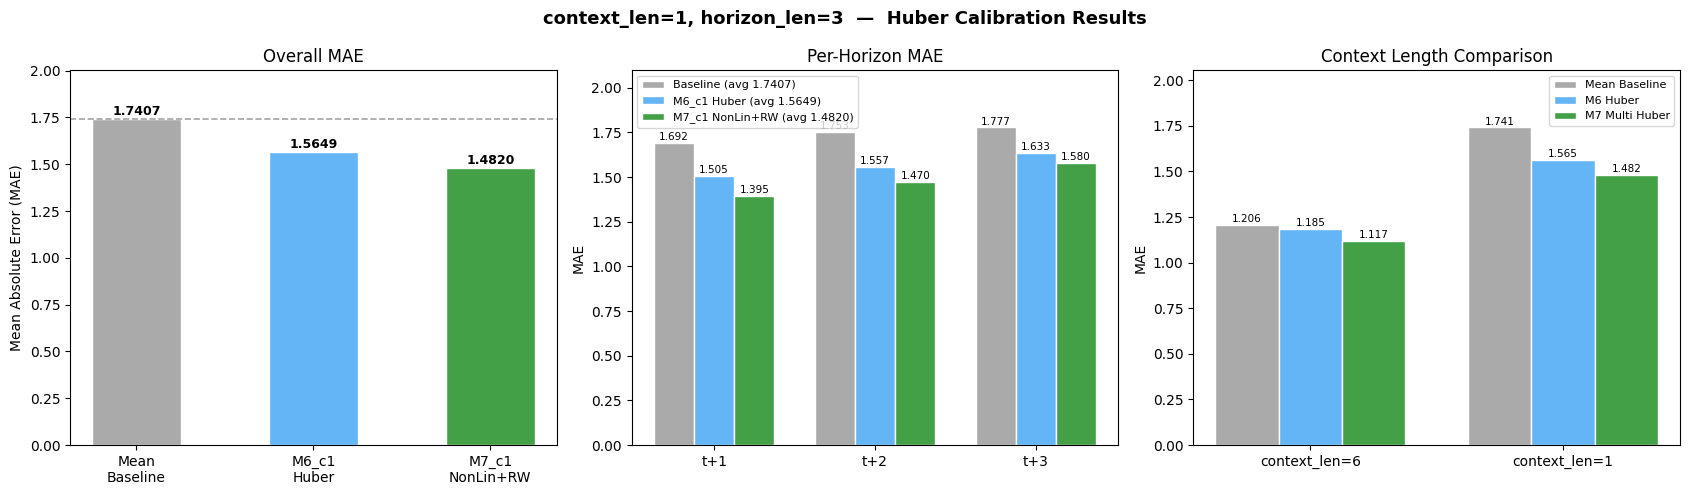

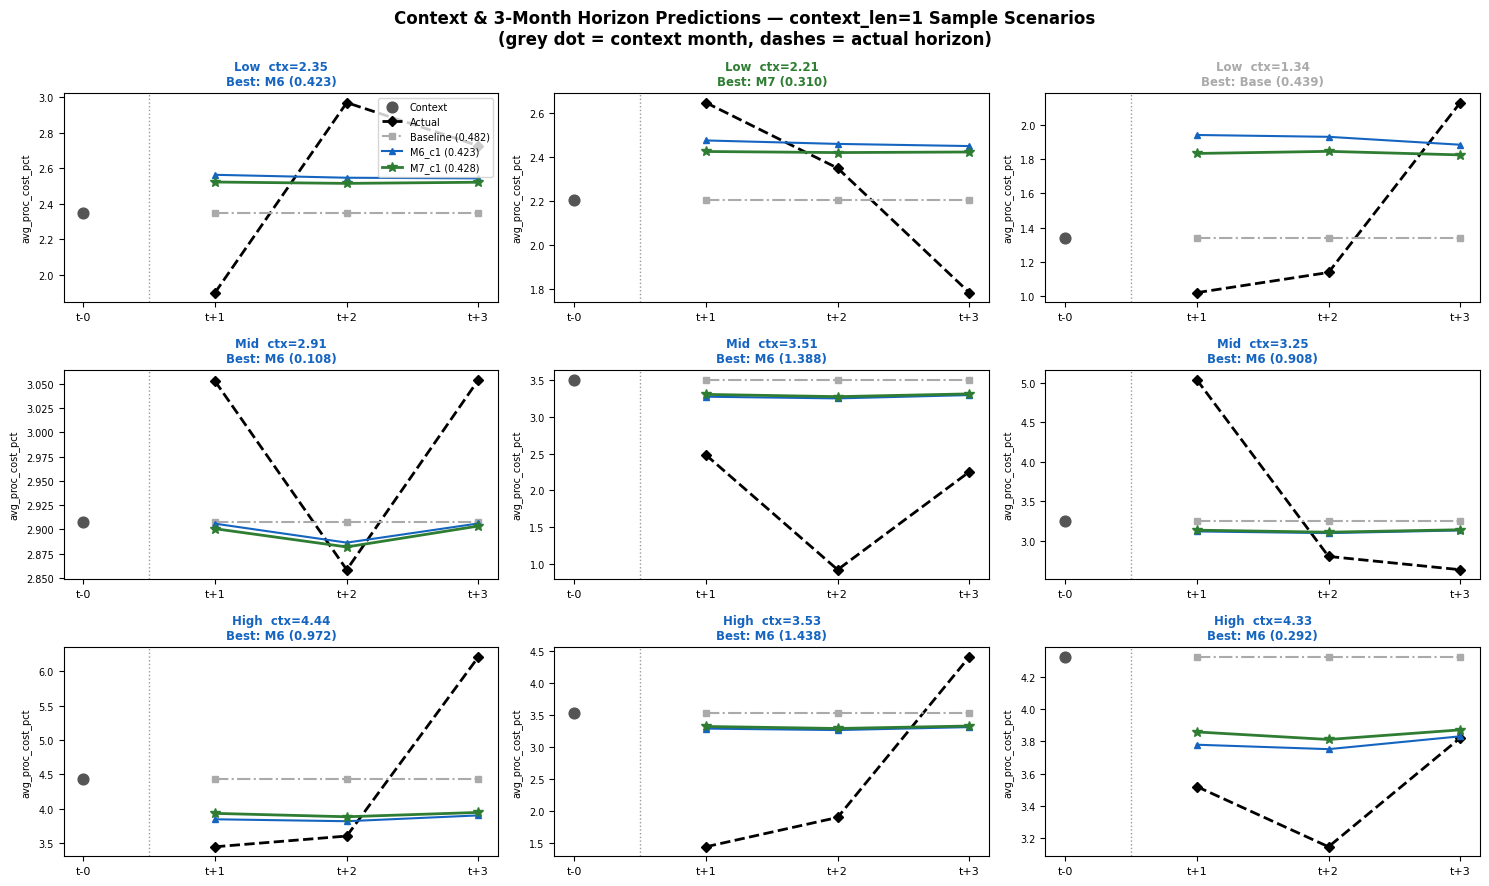

In [47]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("context_len=1, horizon_len=3  —  Huber Calibration Results", fontsize=13, fontweight='bold')

# ── Panel 1: Overall MAE comparison ──────────────────────────────────────────
ax1 = axes[0]
strategies = ["Mean\nBaseline", "M6_c1\nHuber", "M7_c1\nNonLin+RW"]
maes_c1    = [mean_baseline_mae_1, m6c1_mae, m7c1_mae]
bar_colors = ["#aaaaaa", "#64b5f6", "#43a047"]

bars = ax1.bar(strategies, maes_c1, color=bar_colors, edgecolor='white', width=0.5)
ax1.axhline(mean_baseline_mae_1, color='#666', linestyle='--', linewidth=1.2, alpha=0.6)
for bar, val in zip(bars, maes_c1):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.005,
             f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax1.set_ylabel("Mean Absolute Error (MAE)")
ax1.set_title("Overall MAE")
ax1.set_ylim(0, max(maes_c1) * 1.15)

# ── Panel 2: Per-horizon MAE ──────────────────────────────────────────────────
ax2 = axes[1]
x = np.arange(3)
w = 0.25

ax2.bar(x - w, ph_base_c1, width=w, label=f"Baseline (avg {mean_baseline_mae_1:.4f})",
        color="#aaaaaa", edgecolor="white")
ax2.bar(x,     ph_m6c1,    width=w, label=f"M6_c1 Huber (avg {m6c1_mae:.4f})",
        color="#64b5f6", edgecolor="white")
ax2.bar(x + w, ph_m7c1,    width=w, label=f"M7_c1 NonLin+RW (avg {m7c1_mae:.4f})",
        color="#43a047", edgecolor="white")

for b in ax2.patches:
    ax2.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
             f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)

ax2.set_xticks(x)
ax2.set_xticklabels(["t+1", "t+2", "t+3"])
ax2.set_ylabel("MAE")
ax2.set_title("Per-Horizon MAE")
ax2.legend(fontsize=8)
ax2.set_ylim(0, max(ph_base_c1) * 1.18)

# ── Panel 3: context_len comparison (1 vs 6) ─────────────────────────────────
ax3 = axes[2]
x2 = np.arange(2)
labels_ctx  = ["context_len=6", "context_len=1"]
base_both   = [mean_baseline_mae_6, mean_baseline_mae_1]
m6_both     = [method6_mae,         m6c1_mae]
m7_both     = [method7_mae,         m7c1_mae]

ax3.bar(x2 - w, base_both, width=w, label="Mean Baseline", color="#aaaaaa", edgecolor="white")
ax3.bar(x2,     m6_both,   width=w, label="M6 Huber",       color="#64b5f6", edgecolor="white")
ax3.bar(x2 + w, m7_both,   width=w, label="M7 Multi Huber", color="#43a047", edgecolor="white")

for b in ax3.patches:
    ax3.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
             f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)

ax3.set_xticks(x2)
ax3.set_xticklabels(labels_ctx)
ax3.set_ylabel("MAE")
ax3.set_title("Context Length Comparison")
ax3.legend(fontsize=8)
ax3.set_ylim(0, max(base_both) * 1.18)

plt.tight_layout()
plt.show()

# ── Sample scenario plots ─────────────────────────────────────────────────────
rng2 = np.random.default_rng(7)
ctx_vals_all = np.array([get_ctx_val(s) for s in valid_test_scenarios_1])
p33c, p67c   = np.percentile(ctx_vals_all, [33, 67])

buckets_c1 = {
    f"Low\n(ctx<{p33c:.2f})":          [i for i,v in enumerate(ctx_vals_all) if v <  p33c],
    f"Mid\n({p33c:.2f}-{p67c:.2f})":    [i for i,v in enumerate(ctx_vals_all) if p33c <= v < p67c],
    f"High\n(ctx>{p67c:.2f})":          [i for i,v in enumerate(ctx_vals_all) if v >= p67c],
}

sample_c1 = []
for label, idxs in buckets_c1.items():
    chosen = rng2.choice(idxs, size=min(3, len(idxs)), replace=False)
    for idx in chosen:
        sample_c1.append((label, idx))

fig2, axes2 = plt.subplots(3, 3, figsize=(15, 9), sharey=False)
fig2.suptitle("Context & 3-Month Horizon Predictions — context_len=1 Sample Scenarios\n"
              "(grey dot = context month, dashes = actual horizon)",
              fontsize=12, fontweight='bold')

for plot_i, (label, idx) in enumerate(sample_c1):
    row, col = divmod(plot_i, 3)
    ax = axes2[row][col]

    s         = valid_test_scenarios_1[idx]
    ctx_val   = get_ctx_val(s)
    hor_actual= get_hor_vals(s)
    base_pred = np.full(3, ctx_val)
    m6_pred   = preds_m6c1[idx]
    m7_pred   = preds_m7c1[idx]

    mae_base = float(np.mean(np.abs(hor_actual - base_pred)))
    mae_m6   = float(np.mean(np.abs(hor_actual - m6_pred)))
    mae_m7   = float(np.mean(np.abs(hor_actual - m7_pred)))

    # Context: single point at t=0
    ax.scatter([0], [ctx_val], color='#555', s=60, zorder=3, label='Context')
    ax.axvline(0.5, color='#999', linestyle=':', lw=1)

    x_hor = [1, 2, 3]
    ax.plot(x_hor, hor_actual, 'k--', marker='D', ms=5, lw=2, label='Actual')
    ax.plot(x_hor, base_pred,  color='#aaa', linestyle='-.', marker='s', ms=4, lw=1.5,
            label=f"Baseline ({mae_base:.3f})")
    ax.plot(x_hor, m6_pred,    color='#1565c0', linestyle='-', marker='^', ms=5, lw=1.5,
            label=f"M6_c1 ({mae_m6:.3f})")
    ax.plot(x_hor, m7_pred,    color='#2e7d32', linestyle='-', marker='*', ms=7, lw=2,
            label=f"M7_c1 ({mae_m7:.3f})")

    best = min(('Base', mae_base), ('M6', mae_m6), ('M7', mae_m7), key=lambda t: t[1])
    badge = {'Base': '#aaa', 'M6': '#1565c0', 'M7': '#2e7d32'}[best[0]]
    ax.set_title(f"{label.split(chr(10))[0]}  ctx={ctx_val:.2f}\nBest: {best[0]} ({best[1]:.3f})",
                 fontsize=8.5, color=badge, fontweight='bold')
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels(['t-0', 't+1', 't+2', 't+3'], fontsize=8)
    ax.tick_params(axis='y', labelsize=7)
    ax.set_ylabel("avg_proc_cost_pct", fontsize=7)
    if plot_i == 0:
        ax.legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.show()

In [54]:
# Step 1: Cache contemporaneous pool means for every unique context endpoint
# Key: (merchant_id, context_end_year, context_end_month)
# This is what generate_pool() is for — removes the target merchant and caps
# at the context end date, simulating a real onboarding scenario.

pool_mean_cache = {}
unique_keys = {
    (s['merchant_id'],
     int(s['context_data'].iloc[-1]['year']),
     int(s['context_data'].iloc[-1]['month']))
    for s in valid_test_scenarios_1
}
print(f"Computing pool means for {len(unique_keys):,} unique (merchant, year, month) keys...")
for mid, yr, mo in unique_keys:
    pool = generate_pool(df_5411_sample, mid, yr, mo)
    pool_mean_cache[(mid, yr, mo)] = float(pool['avg_proc_cost_pct'].mean())
print("Done.")
for k, v in list(pool_mean_cache.items())[:5]:
    print(f"  merchant={k[0]:6d}  {k[1]}-{k[2]:02d}  pool_mean={v:.4f}")

Computing pool means for 5,301 unique (merchant, year, month) keys...
Done.
  merchant= 78146  2014-09  pool_mean=4.4931
  merchant= 53215  2016-04  pool_mean=4.5064
  merchant= 74807  2011-08  pool_mean=4.1788
  merchant= 59251  2013-02  pool_mean=4.1336
  merchant= 78146  2010-11  pool_mean=4.0980


In [55]:
# M8: Pool-anchored Multi-feature Huber with Rolling Temporal CV
#
# Fixes to M7:
#   (a) pool_mean replaces context_mean_sq as the 4th feature — it is the
#       contemporaneous market mean from generate_pool(), which is dynamic
#       and production-realistic (always available at onboarding time)
#   (b) Regime weight = 1/(pool_mean + 1) instead of 1/(context_mean + 1)
#       — the weight is now anchored to the market regime at that moment,
#       not the merchant's own (potentially noisy) cost level
#   (c) Rolling temporal CV instead of a single 2018 cut:
#       fold_cut in [2017, 2018, 2019]
#       train = windows whose last horizon month year < fold_cut
#       test  = windows whose first horizon month year == fold_cut

import warnings
from sklearn.linear_model import HuberRegressor
from sklearn.preprocessing import StandardScaler

FEAT_NAMES_M8 = ['context_mean', 'context_std', 'momentum', 'pool_mean']

def build_features_m8(scenarios, cache):
    rows = []
    for s in scenarios:
        vals   = s['context_data']['avg_proc_cost_pct'].values
        c_mean = float(np.mean(vals))
        c_std  = float(np.std(vals))
        mom    = float(vals[-1] - c_mean)
        key    = (s['merchant_id'],
                  int(s['context_data'].iloc[-1]['year']),
                  int(s['context_data'].iloc[-1]['month']))
        p_mean = cache[key]
        rows.append([c_mean, c_std, mom, p_mean])
    return np.array(rows, dtype=float)

# ── Rolling temporal CV ───────────────────────────────────────────────────────
fold_cuts  = [2017, 2018, 2019]
fold_results = []

for cut in fold_cuts:
    train_fold = [s for s in valid_test_scenarios_1
                  if int(s['horizon_data'].iloc[-1]['year']) < cut]
    test_fold  = [s for s in valid_test_scenarios_1
                  if int(s['horizon_data'].iloc[0]['year']) == cut]
    if not train_fold or not test_fold:
        print(f"  Cut {cut}: skipped (train={len(train_fold)}, test={len(test_fold)})")
        continue

    X_tr_raw  = build_features_m8(train_fold, pool_mean_cache)
    y_tr      = np.array([s['horizon_data']['avg_proc_cost_pct'].values for s in train_fold])
    sw        = 1.0 / (X_tr_raw[:, 3] + 1.0)   # 1/(pool_mean + 1)

    X_te_raw  = build_features_m8(test_fold,  pool_mean_cache)
    y_te      = np.array([s['horizon_data']['avg_proc_cost_pct'].values for s in test_fold])

    # Baseline for this fold
    base_preds = np.array([[np.mean(s['context_data']['avg_proc_cost_pct'].values)]*3
                            for s in test_fold])
    base_mae   = float(np.mean(np.abs(y_te - base_preds)))

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr_raw)
    X_te = scaler.transform(X_te_raw)

    preds_fold = np.zeros_like(y_te, dtype=float)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for i in range(3):
            m = HuberRegressor(epsilon=1.35, max_iter=500)
            m.fit(X_tr, y_tr[:, i], sample_weight=sw)
            preds_fold[:, i] = m.predict(X_te)

    m8_mae = float(np.mean(np.abs(y_te - preds_fold)))
    fold_results.append({
        'cut_year': cut,
        'n_train':  len(train_fold),
        'n_test':   len(test_fold),
        'baseline_mae': round(base_mae, 6),
        'm8_mae':        round(m8_mae,  6),
        'improvement':   round((m8_mae - base_mae) / base_mae * 100, 2),
    })
    print(f"  Fold {cut}: train={len(train_fold):,}  test={len(test_fold):,}  "
          f"baseline={base_mae:.4f}  M8={m8_mae:.4f}  "
          f"{'BEAT' if m8_mae < base_mae else 'MISS'} ({(m8_mae-base_mae)/base_mae*100:+.2f}%)")

df_folds = pd.DataFrame(fold_results)
avg_base = df_folds['baseline_mae'].mean()
avg_m8   = df_folds['m8_mae'].mean()

print(f"\nRolling CV summary ({len(df_folds)} folds):")
print(f"  Avg baseline MAE : {avg_base:.6f}")
print(f"  Avg M8 MAE       : {avg_m8:.6f}")
print(f"  Avg improvement  : {(avg_m8 - avg_base)/avg_base*100:+.2f}%  "
      f"({'BEAT' if avg_m8 < avg_base else 'MISS'})")
display(df_folds)

  Fold 2017: train=3,698  test=550  baseline=1.7789  M8=1.6074  BEAT (-9.64%)
  Fold 2018: train=4,254  test=575  baseline=2.2876  M8=1.9765  BEAT (-13.60%)
  Fold 2019: train=4,821  test=384  baseline=1.5063  M8=1.3365  BEAT (-11.27%)

Rolling CV summary (3 folds):
  Avg baseline MAE : 1.857577
  Avg M8 MAE       : 1.640143
  Avg improvement  : -11.71%  (BEAT)


,cut_year,n_train,n_test,baseline_mae,m8_mae,improvement
0,2017,3698,550,1.778861,1.607359,-9.64
1,2018,4254,575,2.287582,1.976542,-13.60
2,2019,4821,384,1.506288,1.336527,-11.27


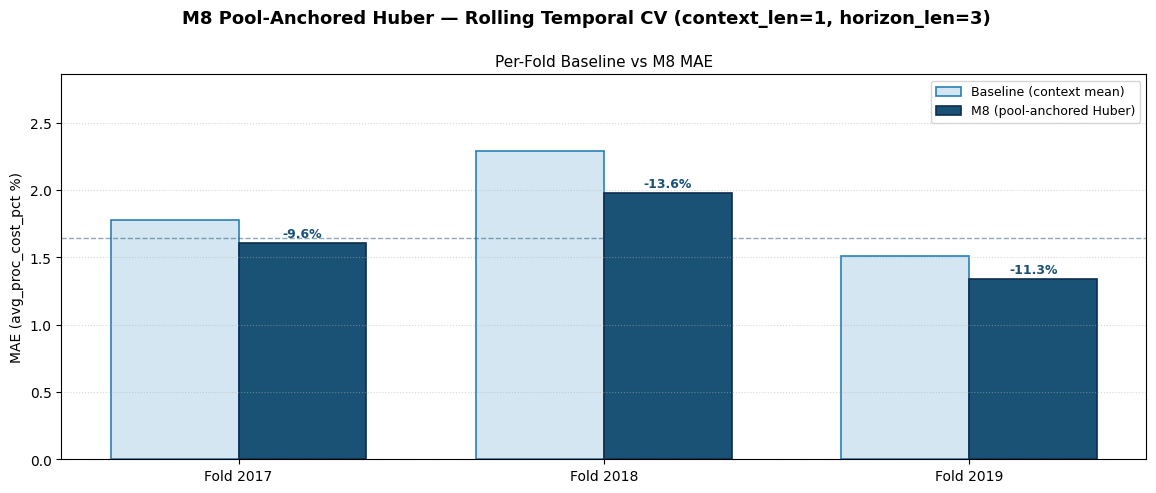

In [80]:

# M8 Rolling CV Visualisation
# Panel 1: Per-fold grouped bars (baseline vs M8)
# Panel 2: Method progression for context_len=1

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax1 = plt.subplots(1, 1, figsize=(14, 5))
fig.suptitle('M8 Pool-Anchored Huber — Rolling Temporal CV (context_len=1, horizon_len=3)',
             fontsize=13, fontweight='bold', y=1.01)

# ── Panel 1: Per-fold grouped bars ────────────────────────────────────────────
folds     = [str(r['cut_year']) for r in fold_results]
base_vals = [r['baseline_mae'] for r in fold_results]
m8_vals   = [r['m8_mae']       for r in fold_results]
impr_vals = [r['improvement']  for r in fold_results]

x      = np.arange(len(folds))
width  = 0.35
bars_b = ax1.bar(x - width/2, base_vals, width, label='Baseline (context mean)', color='#d4e6f1', edgecolor='#2980b9', linewidth=1.2)
bars_m = ax1.bar(x + width/2, m8_vals,   width, label='M8 (pool-anchored Huber)', color='#1a5276', edgecolor='#0e2d4e', linewidth=1.2)

for bar, imp in zip(bars_m, impr_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{imp:+.1f}%', ha='center', va='bottom', fontsize=9, color='#1a5276', fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels([f'Fold {f}' for f in folds], fontsize=10)
ax1.set_ylabel('MAE (avg_proc_cost_pct %)', fontsize=10)
ax1.set_title('Per-Fold Baseline vs M8 MAE', fontsize=11)
ax1.legend(fontsize=9)
ax1.set_ylim(0, max(base_vals) * 1.25)
ax1.axhline(avg_m8, color='#1a5276', linestyle='--', linewidth=1, alpha=0.5, label=f'Avg M8 = {avg_m8:.4f}')
ax1.grid(axis='y', linestyle=':', alpha=0.5)

# # ── Panel 2: Method progression (context_len=1) ────────────────────────────────
# # Note: M6_c1 and M7_c1 use a fixed 2018 split; M8 reports rolling CV average.
# # The rolling CV avg_base (1.8576) is higher than mean_baseline_mae_1 (1.7407)
# # because folds include higher-cost 2017 test data.
# method_labels = [
#     'Baseline\n(context mean)',
#     'M6_c1\nSingle-feature\nHuber',
#     'M7_c1\nMulti-feature\nHuber',
#     'M8\nPool-anchored\nRolling CV avg',
# ]
# # Use fold-matched baseline for M8; use mean_baseline_mae_1 for M6/M7
# method_maes = [mean_baseline_mae_1, m6c1_mae, m7c1_mae, float(avg_m8)]
# bar_colors2 = ['#d4e6f1', '#5499c7', '#2471a3', '#1a5276']
# edge_colors2 = ['#2980b9', '#1f618d', '#154360', '#0e2d4e']

# bars2 = ax2.bar(range(len(method_labels)), method_maes,
#                 color=bar_colors2, edgecolor=edge_colors2, linewidth=1.2, width=0.55)

# # % vs baseline annotation
# for i, (bar, mae) in enumerate(zip(bars2, method_maes)):
#     pct = (mae - mean_baseline_mae_1) / mean_baseline_mae_1 * 100
#     label_txt = 'baseline' if i == 0 else f'{pct:+.1f}%'
#     ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
#              label_txt, ha='center', va='bottom', fontsize=9,
#              color='#1a5276' if i > 0 else '#555', fontweight='bold' if i > 0 else 'normal')

# ax2.set_xticks(range(len(method_labels)))
# ax2.set_xticklabels(method_labels, fontsize=8.5)
# ax2.set_ylabel('MAE (avg_proc_cost_pct %)', fontsize=10)
# ax2.set_title('Method Progression — context_len=1\n(* M8 is rolling CV avg; M6/M7 are fixed 2018 split)', fontsize=10)
# ax2.set_ylim(0, mean_baseline_mae_1 * 1.3)
# ax2.axhline(mean_baseline_mae_1, color='#d4e6f1', linestyle='--', linewidth=1.2, alpha=0.8)
# ax2.grid(axis='y', linestyle=':', alpha=0.5)

# plt.tight_layout()
# plt.savefig('m8_rolling_cv_results.png', dpi=150, bbox_inches='tight')
# plt.show()

# print(f"\nSummary — context_len=1, horizon_len=3")
# print(f"  Baseline (mean_baseline_mae_1) : {mean_baseline_mae_1:.6f}")
# print(f"  M6_c1  (fixed 2018 split)      : {m6c1_mae:.6f}  ({(m6c1_mae - mean_baseline_mae_1)/mean_baseline_mae_1*100:+.2f}%)")
# print(f"  M7_c1  (fixed 2018 split)      : {m7c1_mae:.6f}  ({(m7c1_mae - mean_baseline_mae_1)/mean_baseline_mae_1*100:+.2f}%)")
# print(f"  M8     (rolling CV, 3-fold avg): {float(avg_m8):.6f}  ({(float(avg_m8) - mean_baseline_mae_1)/mean_baseline_mae_1*100:+.2f}% vs fixed baseline)")
# print(f"\n  Rolling CV fold-matched improvement : {(float(avg_m8) - float(avg_base))/float(avg_base)*100:+.2f}% vs fold baselines")


---
## Prediction Intervals — 90% Joint Confidence

**Goal:** for each merchant forecast, produce an interval [lo, hi] such that we are 90% confident *all three* horizon months fall within it.

### Method A — Split Conformal (recommended)
Build on M8 point predictions. On a held-out calibration fold:
1. Compute residuals for each horizon step: `e_h = |y_h - ŷ_h|`
2. Take the per-scenario worst-case error: `max_e = max(e_1, e_2, e_3)`
3. `q90 = 90th percentile of max_e` over all calibration scenarios
4. Final CI: `[ŷ_h − q90, ŷ_h + q90]` for all h

This gives **exact** joint 90% coverage on the calibration distribution, with no parametric assumption.

### Method B — Quantile Regression (pinball loss)
Train a lower model at quantile `α/2` and an upper model at quantile `1-α/2`.
Pinball loss: `L(q, y, ŷ) = q·(y−ŷ)` if `y≥ŷ`, else `(q−1)·(y−ŷ)`

For joint coverage, the nominal `α` must be calibrated: sweep `α` on a validation fold and pick
the smallest value achieving ≥90% joint coverage. Produces asymmetric intervals better suited
for right-skewed cost distributions.

### Log-normal connection
Taking `log1p(avg_proc_cost_pct)` before fitting makes residuals closer to Gaussian.
Both methods above work in raw or log space — we compare both.


In [69]:

# ── Method A: Split Conformal Prediction Intervals ────────────────────────────
#
# Split: train on pre-2018 | calibrate on 2018 | evaluate on 2019
# Joint 90% CI: find q90 of per-scenario max(|residual|) across all 3 horizon steps.
# By the 90th-percentile guarantee: P(all 3 steps inside) ≥ 0.90 on cal distribution.

import warnings
from sklearn.linear_model import HuberRegressor
from sklearn.preprocessing import StandardScaler
import numpy as np

train_ci = [s for s in valid_test_scenarios_1 if int(s['horizon_data'].iloc[-1]['year']) < 2018]
cal_ci   = [s for s in valid_test_scenarios_1 if int(s['horizon_data'].iloc[0]['year']) == 2018]
test_ci  = [s for s in valid_test_scenarios_1 if int(s['horizon_data'].iloc[0]['year']) == 2019]

X_tr_ci_raw  = build_features_m8(train_ci, pool_mean_cache)
y_tr_ci      = np.array([s['horizon_data']['avg_proc_cost_pct'].values for s in train_ci])
sw_ci        = 1.0 / (X_tr_ci_raw[:, 3] + 1.0)

X_cal_ci_raw = build_features_m8(cal_ci, pool_mean_cache)
y_cal_ci     = np.array([s['horizon_data']['avg_proc_cost_pct'].values for s in cal_ci])

X_te_ci_raw  = build_features_m8(test_ci, pool_mean_cache)
y_te_ci      = np.array([s['horizon_data']['avg_proc_cost_pct'].values for s in test_ci])

scaler_ci = StandardScaler()
X_tr_ci   = scaler_ci.fit_transform(X_tr_ci_raw)
X_cal_ci  = scaler_ci.transform(X_cal_ci_raw)
X_te_ci   = scaler_ci.transform(X_te_ci_raw)

# Fit M8 Huber point models
cal_preds_ci = np.zeros_like(y_cal_ci, dtype=float)
te_preds_ci  = np.zeros_like(y_te_ci,  dtype=float)
models_ci    = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for h in range(3):
        m = HuberRegressor(epsilon=1.35, max_iter=500)
        m.fit(X_tr_ci, y_tr_ci[:, h], sample_weight=sw_ci)
        cal_preds_ci[:, h] = m.predict(X_cal_ci)
        te_preds_ci[:, h]  = m.predict(X_te_ci)
        models_ci.append(m)

# ── Also fit in log1p space for comparison ────────────────────────────────────
y_tr_ci_log   = np.log1p(y_tr_ci)
cal_preds_log = np.zeros_like(y_cal_ci, dtype=float)
te_preds_log  = np.zeros_like(y_te_ci,  dtype=float)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for h in range(3):
        m_log = HuberRegressor(epsilon=1.35, max_iter=500)
        m_log.fit(X_tr_ci, y_tr_ci_log[:, h], sample_weight=sw_ci)
        cal_preds_log[:, h] = np.expm1(m_log.predict(X_cal_ci))
        te_preds_log[:, h]  = np.expm1(m_log.predict(X_te_ci))

# ── Step 2: Calibrate half-width ──────────────────────────────────────────────
# Raw space
cal_max_res_raw  = np.abs(y_cal_ci - cal_preds_ci).max(axis=1)
q90_raw          = float(np.quantile(cal_max_res_raw, 0.90))

# Log space
cal_max_res_log  = np.abs(y_cal_ci - cal_preds_log).max(axis=1)
q90_log          = float(np.quantile(cal_max_res_log, 0.90))

# ── Step 3: Build CIs on test fold ────────────────────────────────────────────
lo_raw = np.clip(te_preds_ci  - q90_raw, 0, None)
hi_raw =         te_preds_ci  + q90_raw
lo_log = np.clip(te_preds_log - q90_log, 0, None)
hi_log =         te_preds_log + q90_log

# ── Step 4: Evaluate coverage ─────────────────────────────────────────────────
def coverage_stats(y, lo, hi, label):
    in_ci        = (y >= lo) & (y <= hi)
    marginal     = float(np.mean(in_ci))
    joint        = float(np.mean(in_ci.all(axis=1)))
    avg_width    = float(np.mean(hi - lo))
    pt_mae       = float(np.mean(np.abs(y - (lo + hi) / 2)))
    print(f"  {label}")
    print(f"    Marginal coverage  : {marginal:.3f}  (per-step average)")
    print(f"    Joint coverage     : {joint:.3f}  (all 3 steps inside)  ← target ≥0.90")
    print(f"    Avg interval width : {avg_width:.4f}")
    print(f"    Mid-point MAE      : {pt_mae:.4f}")
    return joint, avg_width

print(f"Test fold: {len(test_ci)} scenarios (2019)")
print(f"Calibration fold: {len(cal_ci)} scenarios (2018)")
print(f"\nCalibrated half-widths:")
print(f"  Raw space  q90 = ±{q90_raw:.4f}")
print(f"  Log space  q90 = ±{q90_log:.4f}")
print()
j_raw, w_raw = coverage_stats(y_te_ci, lo_raw, hi_raw, "Conformal — raw space")
print()
j_log, w_log = coverage_stats(y_te_ci, lo_log, hi_log, "Conformal — log1p space")


Test fold: 384 scenarios (2019)
Calibration fold: 575 scenarios (2018)

Calibrated half-widths:
  Raw space  q90 = ±4.6759
  Log space  q90 = ±5.3058

  Conformal — raw space
    Marginal coverage  : 0.940  (per-step average)
    Joint coverage     : 0.906  (all 3 steps inside)  ← target ≥0.90
    Avg interval width : 7.6547
    Mid-point MAE      : 1.7496

  Conformal — log1p space
    Marginal coverage  : 0.942  (per-step average)
    Joint coverage     : 0.914  (all 3 steps inside)  ← target ≥0.90
    Avg interval width : 8.2971
    Mid-point MAE      : 2.0875


In [70]:

# ── Method B: Quantile Regression (pinball loss) ─────────────────────────────
#
# Train separate lower (q_lo) and upper (q_hi) models.
# Pinball loss is the native sklearn QuantileRegressor objective:
#   L(q, y, ŷ) = q·(y−ŷ) if y≥ŷ  else  (1−q)·(ŷ−y)
#
# For JOINT 90% coverage, sweep the nominal one-sided tail α until
# joint coverage on the 2018 calibration fold first hits ≥ 0.90.
#
# The required α will be smaller than 0.05 (wider than the naive marginal 90%),
# because we need ALL 3 steps to be covered simultaneously.

from sklearn.linear_model import QuantileRegressor
import warnings

target_joint = 0.90
sweep = []

for alpha in [0.30, 0.25, 0.20, 0.15, 0.12, 0.10, 0.08, 0.06, 0.05, 0.04, 0.03, 0.02, 0.01]:
    lo_cal_q = np.zeros_like(y_cal_ci, dtype=float)
    hi_cal_q = np.zeros_like(y_cal_ci, dtype=float)
    lo_te_q  = np.zeros_like(y_te_ci,  dtype=float)
    hi_te_q  = np.zeros_like(y_te_ci,  dtype=float)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for h in range(3):
            qlo = QuantileRegressor(quantile=alpha,     alpha=0.0, solver='highs')
            qhi = QuantileRegressor(quantile=1 - alpha, alpha=0.0, solver='highs')
            qlo.fit(X_tr_ci, y_tr_ci[:, h], sample_weight=sw_ci)
            qhi.fit(X_tr_ci, y_tr_ci[:, h], sample_weight=sw_ci)
            lo_cal_q[:, h] = qlo.predict(X_cal_ci)
            hi_cal_q[:, h] = qhi.predict(X_cal_ci)
            lo_te_q[:, h]  = qlo.predict(X_te_ci)
            hi_te_q[:, h]  = qhi.predict(X_te_ci)

    in_cal  = (y_cal_ci >= lo_cal_q) & (y_cal_ci <= hi_cal_q)
    j_cal   = float(np.mean(in_cal.all(axis=1)))
    in_te   = (y_te_ci  >= lo_te_q)  & (y_te_ci  <= hi_te_q)
    j_te    = float(np.mean(in_te.all(axis=1)))
    width   = float(np.mean(hi_te_q - lo_te_q))
    asym    = float(np.mean((hi_te_q - lo_te_q) / 2 - (lo_te_q - te_preds_ci + hi_te_q - te_preds_ci) / 2))

    sweep.append({'alpha': alpha, 'cal_joint': j_cal, 'te_joint': j_te, 'avg_width': width,
                  'lo_cal_q': lo_cal_q.copy(), 'hi_cal_q': hi_cal_q.copy(),
                  'lo_te_q':  lo_te_q.copy(),  'hi_te_q':  hi_te_q.copy()})
    flag = ' ← ≥90%' if j_cal >= target_joint else ''
    print(f"  α={alpha:.2f}  CI=[{alpha:.0%}, {1-alpha:.0%}]  "
          f"cal_joint={j_cal:.3f}  te_joint={j_te:.3f}  width={width:.4f}{flag}")

# Find first (widest) α that achieves target on calibration fold
achieved = [r for r in sweep if r['cal_joint'] >= target_joint]
best_qr   = achieved[0] if achieved else sweep[-1]

print(f"\nChosen: α={best_qr['alpha']:.2f}  "
      f"cal_joint={best_qr['cal_joint']:.3f}  "
      f"te_joint={best_qr['te_joint']:.3f}  "
      f"avg_width={best_qr['avg_width']:.4f}")

# Final QR intervals (clipped at 0 — costs can't be negative)
lo_qr = np.clip(best_qr['lo_te_q'], 0, None)
hi_qr = best_qr['hi_te_q']

in_qr = (y_te_ci >= lo_qr) & (y_te_ci <= hi_qr)
print(f"\nQuantile Regression (calibrated α={best_qr['alpha']:.2f}):")
print(f"  Joint coverage (test 2019) : {float(np.mean(in_qr.all(axis=1))):.3f}")
print(f"  Marginal coverage          : {float(np.mean(in_qr)):.3f}")
print(f"  Avg interval width         : {float(np.mean(hi_qr - lo_qr)):.4f}")
print(f"  Asymmetry (upper skew)     : "
      f"avg upper half = {float(np.mean(hi_qr - te_preds_ci)):.4f}  "
      f"avg lower half = {float(np.mean(te_preds_ci - lo_qr)):.4f}")


  α=0.30  CI=[30%, 70%]  cal_joint=0.106  te_joint=0.099  width=1.3026
  α=0.25  CI=[25%, 75%]  cal_joint=0.190  te_joint=0.172  width=1.6841
  α=0.20  CI=[20%, 80%]  cal_joint=0.330  te_joint=0.312  width=2.1900
  α=0.15  CI=[15%, 85%]  cal_joint=0.459  te_joint=0.482  width=2.8917
  α=0.12  CI=[12%, 88%]  cal_joint=0.563  te_joint=0.568  width=3.4406
  α=0.10  CI=[10%, 90%]  cal_joint=0.616  te_joint=0.651  width=3.8688
  α=0.08  CI=[8%, 92%]  cal_joint=0.704  te_joint=0.711  width=4.4515
  α=0.06  CI=[6%, 94%]  cal_joint=0.750  te_joint=0.773  width=5.0724
  α=0.05  CI=[5%, 95%]  cal_joint=0.774  te_joint=0.794  width=5.4975
  α=0.04  CI=[4%, 96%]  cal_joint=0.817  te_joint=0.815  width=5.9322
  α=0.03  CI=[3%, 97%]  cal_joint=0.854  te_joint=0.862  width=6.4791
  α=0.02  CI=[2%, 98%]  cal_joint=0.906  te_joint=0.896  width=7.6903 ← ≥90%
  α=0.01  CI=[1%, 99%]  cal_joint=0.948  te_joint=0.932  width=10.3830 ← ≥90%

Chosen: α=0.02  cal_joint=0.906  te_joint=0.896  avg_width=7.6903

Q

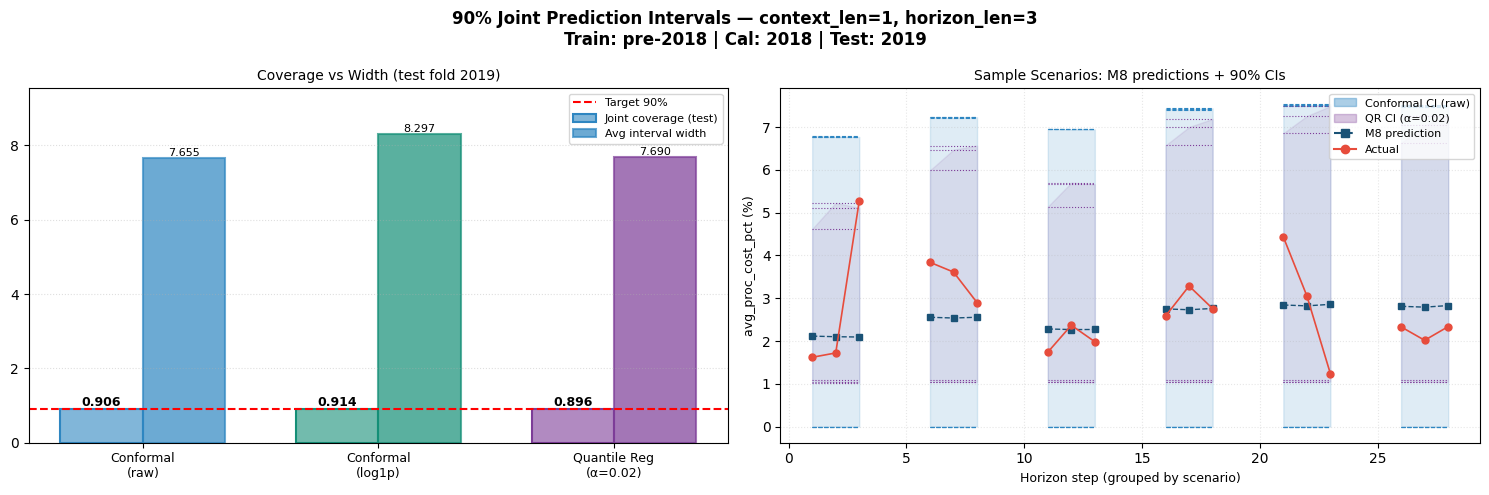

90% JOINT PREDICTION INTERVAL SUMMARY (test fold: 2019)
  Conformal (raw space)           joint=0.906  width=7.6547  ✓ COVERED
  Conformal (log1p space)         joint=0.914  width=8.2971  ✓ COVERED
  Quantile Reg (α=0.02)           joint=0.896  width=7.6903  ✗ MISS

Interpretation:
  Conformal half-width ±4.6759 means:
  If M8 predicts 1.50%, the 90% joint CI is [0.0000%, 6.1759%]


In [71]:

# ── Visualisation: Method A vs B comparison ───────────────────────────────────
#
# Left:  Coverage vs width trade-off (conformal vs quantile regression)
# Right: 12 example scenarios — M8 point prediction, actual values,
#        conformal CI (symmetric) and QR CI (asymmetric) overlaid

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('90% Joint Prediction Intervals — context_len=1, horizon_len=3\n'
             'Train: pre-2018 | Cal: 2018 | Test: 2019',
             fontsize=12, fontweight='bold')

# ── Panel 1: Coverage / width summary ─────────────────────────────────────────
ax = axes[0]
methods = ['Conformal\n(raw)', 'Conformal\n(log1p)', f'Quantile Reg\n(α={best_qr["alpha"]:.2f})']

te_joint_scores = [
    float(np.mean(((y_te_ci >= lo_raw) & (y_te_ci <= hi_raw)).all(axis=1))),
    float(np.mean(((y_te_ci >= lo_log) & (y_te_ci <= hi_log)).all(axis=1))),
    float(np.mean(((y_te_ci >= lo_qr)  & (y_te_ci <= hi_qr)).all(axis=1))),
]
widths = [
    float(np.mean(hi_raw - lo_raw)),
    float(np.mean(hi_log - lo_log)),
    float(np.mean(hi_qr  - lo_qr)),
]
colors = ['#2e86c1', '#148f77', '#7d3c98']

x = np.arange(len(methods))
w = 0.35
bars_cov = ax.bar(x - w/2, te_joint_scores, w,
                  color=[c + '99' for c in ['#2e86c1', '#148f77', '#7d3c98']],
                  edgecolor=colors, linewidth=1.5, label='Joint coverage (test)')
bars_wid = ax.bar(x + w/2, widths, w,
                  color=colors, edgecolor=[c + 'aa' for c in colors],
                  linewidth=1.5, alpha=0.7, label='Avg interval width')

ax.axhline(0.90, color='red', linestyle='--', linewidth=1.5, label='Target 90%')
for bar, v in zip(bars_cov, te_joint_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar, v in zip(bars_wid, widths):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{v:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=9)
ax.set_ylim(0, max(max(widths), 1.05) * 1.15)
ax.set_title('Coverage vs Width (test fold 2019)', fontsize=10)
ax.legend(fontsize=8)
ax.grid(axis='y', linestyle=':', alpha=0.4)

# ── Panel 2: Sample scenarios with CIs ────────────────────────────────────────
ax2 = axes[1]
rng_ci = np.random.default_rng(99)
idxs_ci = rng_ci.choice(len(test_ci), size=6, replace=False)

horizon_ticks = [1, 2, 3]
offset = 0
cmap_actual = '#e74c3c'
cmap_point  = '#1a5276'
cmap_conf   = '#2e86c1'
cmap_qr     = '#7d3c98'

for plot_idx, si in enumerate(sorted(idxs_ci)):
    y_act   = y_te_ci[si]
    y_pt    = te_preds_ci[si]
    y_lo_cf = lo_raw[si]
    y_hi_cf = hi_raw[si]
    y_lo_qr = lo_qr[si]
    y_hi_qr = hi_qr[si]
    base    = offset

    xticks = np.array(horizon_ticks) + (plot_idx * 5)
    # Conformal CI band (symmetric)
    ax2.fill_between(xticks, y_lo_cf + base, y_hi_cf + base,
                     alpha=0.15, color=cmap_conf)
    ax2.plot(xticks, [y_lo_cf + base]*3, color=cmap_conf, linewidth=0.8, linestyle='--')
    ax2.plot(xticks, [y_hi_cf + base]*3, color=cmap_conf, linewidth=0.8, linestyle='--')
    # QR CI (asymmetric)
    ax2.fill_between(xticks, y_lo_qr + base, y_hi_qr + base,
                     alpha=0.10, color=cmap_qr)
    ax2.plot(xticks, [y_lo_qr + base]*3, color=cmap_qr, linewidth=0.8, linestyle=':')
    ax2.plot(xticks, [y_hi_qr + base]*3, color=cmap_qr, linewidth=0.8, linestyle=':')
    # Point prediction and actual
    ax2.plot(xticks, y_pt  + base, 's--', color=cmap_point,  markersize=5, linewidth=1)
    ax2.plot(xticks, y_act + base, 'o-',  color=cmap_actual, markersize=5, linewidth=1.2)

    offset += 0  # all on same y scale for this simple view

legend_items = [
    mpatches.Patch(color=cmap_conf, alpha=0.4, label='Conformal CI (raw)'),
    mpatches.Patch(color=cmap_qr,   alpha=0.3, label=f'QR CI (α={best_qr["alpha"]:.2f})'),
    plt.Line2D([0],[0], color=cmap_point, marker='s', linestyle='--', label='M8 prediction'),
    plt.Line2D([0],[0], color=cmap_actual, marker='o', linestyle='-',  label='Actual'),
]
ax2.legend(handles=legend_items, fontsize=8, loc='upper right')
ax2.set_xlabel('Horizon step (grouped by scenario)', fontsize=9)
ax2.set_ylabel('avg_proc_cost_pct (%)', fontsize=9)
ax2.set_title('Sample Scenarios: M8 predictions + 90% CIs', fontsize=10)
ax2.grid(True, linestyle=':', alpha=0.3)

plt.tight_layout()
plt.savefig('prediction_intervals_90pct.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Final summary ─────────────────────────────────────────────────────────────
print("=" * 60)
print("90% JOINT PREDICTION INTERVAL SUMMARY (test fold: 2019)")
print("=" * 60)
rows = [
    ("Conformal (raw space)",   j_raw, w_raw),
    ("Conformal (log1p space)", j_log, w_log),
    (f"Quantile Reg (α={best_qr['alpha']:.2f})",
     float(np.mean(((y_te_ci >= lo_qr) & (y_te_ci <= hi_qr)).all(axis=1))),
     float(np.mean(hi_qr - lo_qr))),
]
for label, cov, wid in rows:
    status = "✓ COVERED" if cov >= 0.90 else "✗ MISS"
    print(f"  {label:<30}  joint={cov:.3f}  width={wid:.4f}  {status}")
print()
print("Interpretation:")
print(f"  Conformal half-width ±{q90_raw:.4f} means:")
print(f"  If M8 predicts 1.50%, the 90% joint CI is "
      f"[{max(0, 1.50 - q90_raw):.4f}%, {1.50 + q90_raw:.4f}%]")


## Pool-Based Conformal Prediction Intervals

The global conformal approach uses a single half-width for every merchant, derived from the pooled distribution of all calibration residuals.

**The inconsistency with the "new merchant" framing:**
The point prediction model is explicitly designed for merchants with no personal history — features are drawn entirely from the peer pool via `generate_pool()`. Using a merchant's *own* calibration residuals to personalise intervals contradicts this, since a truly new merchant has no personal history to draw from.

**The fix — pool-based conformal intervals:**
1. For each test scenario (merchant m, context endpoint (yr, mo)), call `generate_pool(df, m, yr, mo)` to retrieve the same peer group used for point prediction
2. Collect calibration residuals (2018) from all peer merchants in that pool
3. Compute `q90_pool = adaptive_q(peer_residuals, 0.90)` — the 90th percentile of peer errors
4. Fall back to `q90_global` if the pool has fewer than `MIN_POOL` residuals

This is fully consistent: both point prediction and uncertainty quantification rely solely on peer information. Half-widths now vary by scenario (reflecting the peer pool composition at each point in time), not by merchant identity.


In [72]:

# ── Pool-Based Conformal Prediction Intervals ─────────────────────────────────
#
# Fully consistent with the "new merchant" framing:
#   - No personal history used at any stage
#   - Peer pool (generate_pool) drives BOTH point prediction AND uncertainty
#
# For each test scenario (merchant m, context endpoint (yr, mo)):
#   1. generate_pool(df, m, yr, mo) → peer merchant IDs (same as used for pool_mean)
#   2. Collect calibration residuals from those peer merchants
#   3. adaptive_q(peer_residuals, 0.90) → pool-based half-width
#   4. Global fallback if < MIN_POOL peer residuals available
#
# Half-widths are per-SCENARIO (pool composition varies by merchant × time),
# not per merchant identity.

import numpy as np
import math
from collections import defaultdict

TARGET_COV = 0.90
MIN_POOL   = 10    # minimum peer calibration residuals for a local estimate

q90_global = q90_raw   # from global conformal cell

# ── Step 1: Group calibration residuals by merchant ───────────────────────────
cal_merchant_ids = np.array([s['merchant_id'] for s in cal_ci])
merchant_cal_res = defaultdict(list)
for i, max_res in enumerate(cal_max_res_raw):
    merchant_cal_res[int(cal_merchant_ids[i])].append(float(max_res))

print(f"Calibration merchants with residuals : {len(merchant_cal_res)}")
print(f"Total calibration residuals          : {sum(len(v) for v in merchant_cal_res.values())}")
print()

# ── Step 2: Adaptive quantile helper ─────────────────────────────────────────
def adaptive_q(residuals, target=0.90):
    """Finite-sample coverage guarantee: q_level = ceil((n+1)*target)/n.
    Returns None if level > 1 (requires n >= ceil(1/(1-target)) = 10 for 90%)."""
    n = len(residuals)
    level = math.ceil((n + 1) * target) / n
    if level > 1.0:
        return None
    return float(np.quantile(residuals, level))

# ── Step 3: Per-scenario pool-based half-width ────────────────────────────────
hw_per_scenario = np.zeros(len(test_ci))
pool_cal_sizes  = []
pool_stats      = {'local': 0, 'global_fallback': 0}

for i, s in enumerate(test_ci):
    mid    = int(s['merchant_id'])
    yr, mo = s['context_range'][1]          # context endpoint: (year, month)

    # Same peer pool used to compute pool_mean for point prediction
    pool_df   = generate_pool(df_5411_sample, mid, yr, mo)
    peer_mids = set(int(p) for p in pool_df['merchant_id'].unique())

    # Aggregate calibration residuals from all peers
    peer_res = []
    for peer in peer_mids:
        peer_res.extend(merchant_cal_res.get(peer, []))

    pool_cal_sizes.append(len(peer_res))

    q_local = adaptive_q(peer_res) if len(peer_res) >= MIN_POOL else None

    if q_local is not None:
        hw_per_scenario[i] = q_local
        pool_stats['local'] += 1
    else:
        hw_per_scenario[i] = q90_global
        pool_stats['global_fallback'] += 1

# ── Step 4: Build intervals ───────────────────────────────────────────────────
lo_merch = np.clip(te_preds_ci - hw_per_scenario[:, None], 0, None)
hi_merch =         te_preds_ci + hw_per_scenario[:, None]

# ── Step 5: Evaluate coverage ────────────────────────────────────────────────
in_merch_ci = (y_te_ci >= lo_merch) & (y_te_ci <= hi_merch)
joint_merch = float(np.mean(in_merch_ci.all(axis=1)))
marg_merch  = float(np.mean(in_merch_ci))
width_merch = float(np.mean(hi_merch - lo_merch))

print("Pool-Based Conformal Prediction Intervals (test fold 2019):")
print(f"  MIN_POOL = {MIN_POOL}  (peer cal residuals needed for local estimate)")
print(f"  Scenarios — pool-based  : {pool_stats['local']}  ({pool_stats['local']/len(test_ci)*100:.1f}%)")
print(f"  Scenarios — global fall : {pool_stats['global_fallback']}  ({pool_stats['global_fallback']/len(test_ci)*100:.1f}%)")
print(f"  Mean peer residual count: {float(np.mean(pool_cal_sizes)):.1f}")
print()
print(f"  Joint coverage  : {joint_merch:.3f}  ({'✓ ≥0.90' if joint_merch >= 0.90 else '✗ <0.90'})")
print(f"  Marginal cov    : {marg_merch:.3f}")
print(f"  Avg half-width  : {width_merch/2:.4f}  (vs global ±{q90_global:.4f})")
print(f"  Width change    : {(width_merch - q90_global*2)/q90_global/2*100:+.1f}% vs global")
print()

print("Per-scenario half-width distribution:")
for lbl, pct in [('  P10', 10), ('  P25', 25), ('  P50', 50), ('  P75', 75), ('  P90', 90)]:
    print(f"{lbl}: ±{float(np.percentile(hw_per_scenario, pct)):.4f}")


Calibration merchants with residuals : 56
Total calibration residuals          : 575

Pool-Based Conformal Prediction Intervals (test fold 2019):
  MIN_POOL = 10  (peer cal residuals needed for local estimate)
  Scenarios — pool-based  : 384  (100.0%)
  Scenarios — global fall : 0  (0.0%)
  Mean peer residual count: 563.8

  Joint coverage  : 0.909  (✓ ≥0.90)
  Marginal cov    : 0.938
  Avg half-width  : 3.9490  (vs global ±4.6759)
  Width change    : -15.5% vs global

Per-scenario half-width distribution:
  P10: ±4.6658
  P25: ±5.0255
  P50: ±5.0255
  P75: ±5.0255
  P90: ±5.0255


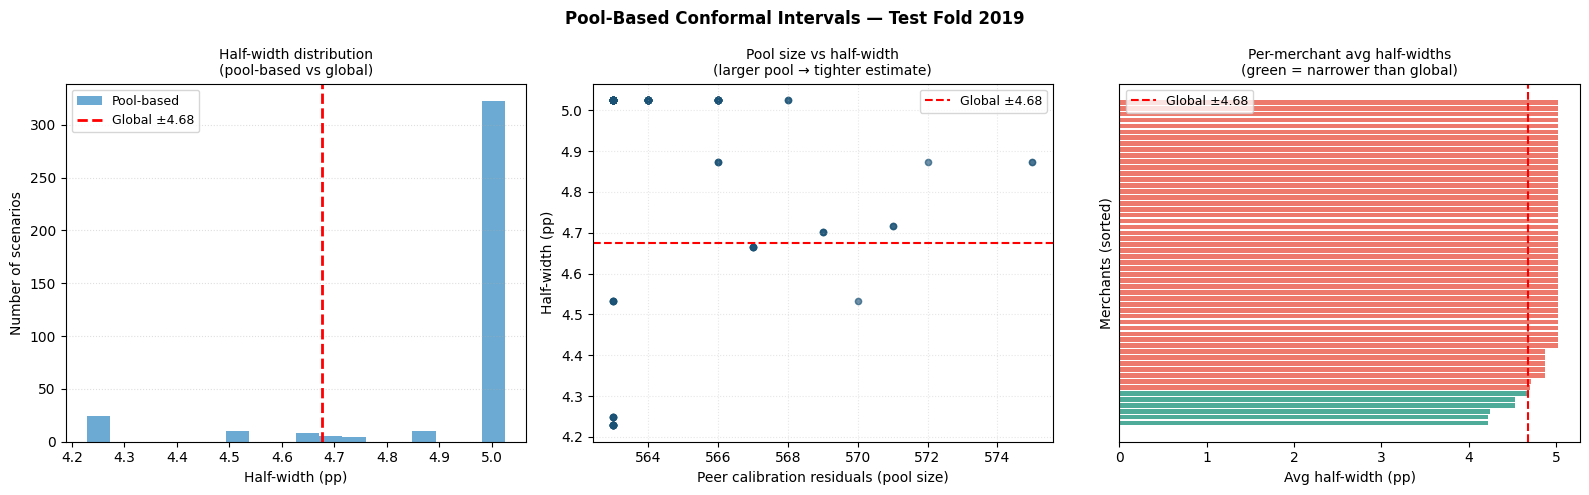

Merchants with NARROWER avg interval than global : 10.9%
Merchants with WIDER   avg interval than global  : 89.1%

Per-merchant coverage stats (test fold):
  Median joint coverage     : 1.000
  % merchants ≥ 90% joint   : 83.6%
  % merchants ≥ 80% joint   : 87.3%

Summary comparison:
  Pool-based conformal : joint=0.909  avg_half_width=±3.9490
  Global conformal     : joint=0.906  avg_half_width=±4.6759


In [73]:

# ── Pool-Based CI audit + visualisation ──────────────────────────────────────

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

test_merchant_ids = np.array([int(s['merchant_id']) for s in test_ci])
unique_test_mids  = sorted(set(test_merchant_ids))

per_merchant_results = []
for mid in unique_test_mids:
    mask     = test_merchant_ids == mid
    y_m      = y_te_ci[mask]
    lo_m     = lo_merch[mask]
    hi_m     = hi_merch[mask]
    lo_gl    = lo_raw[mask]
    hi_gl    = hi_raw[mask]
    hw_m_avg = float(np.mean(hw_per_scenario[mask]))
    n_m_test = int(np.sum(mask))

    in_m     = (y_m >= lo_m)  & (y_m <= hi_m)
    in_gl    = (y_m >= lo_gl) & (y_m <= hi_gl)
    joint_m  = float(np.mean(in_m.all(axis=1)))  if n_m_test > 0 else np.nan
    joint_gl = float(np.mean(in_gl.all(axis=1))) if n_m_test > 0 else np.nan

    per_merchant_results.append({
        'merchant_id': mid,
        'n_test'     : n_m_test,
        'avg_hw_pool': hw_m_avg,
        'hw_global'  : q90_global,
        'joint_pool' : joint_m,
        'joint_global': joint_gl,
        'narrowed'   : hw_m_avg < q90_global,
    })

df_merch = pd.DataFrame(per_merchant_results)

# ── Figure: 3-panel ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Pool-Based Conformal Intervals — Test Fold 2019', fontsize=12, fontweight='bold')

# Panel 1: Histogram of per-scenario half-widths
ax = axes[0]
ax.hist(hw_per_scenario, bins=18, color='#2e86c1', alpha=0.7, label='Pool-based')
ax.axvline(q90_global, color='red', linestyle='--', linewidth=2,
           label=f'Global ±{q90_global:.2f}')
ax.set_xlabel('Half-width (pp)', fontsize=10)
ax.set_ylabel('Number of scenarios', fontsize=10)
ax.set_title('Half-width distribution\n(pool-based vs global)', fontsize=10)
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle=':', alpha=0.4)

# Panel 2: Pool calibration size vs half-width
ax2 = axes[1]
ax2.scatter(pool_cal_sizes, hw_per_scenario, alpha=0.4, s=20, color='#1a5276')
ax2.axhline(q90_global, color='red', linestyle='--', linewidth=1.5,
            label=f'Global ±{q90_global:.2f}')
ax2.set_xlabel('Peer calibration residuals (pool size)', fontsize=10)
ax2.set_ylabel('Half-width (pp)', fontsize=10)
ax2.set_title('Pool size vs half-width\n(larger pool → tighter estimate)', fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(linestyle=':', alpha=0.3)

# Panel 3: Per-merchant avg half-widths sorted
ax3 = axes[2]
df_sorted  = df_merch.sort_values('avg_hw_pool').reset_index(drop=True)
bar_cols   = ['#148f77' if v else '#e74c3c' for v in df_sorted['narrowed']]
ax3.barh(range(len(df_sorted)), df_sorted['avg_hw_pool'], color=bar_cols, alpha=0.75)
ax3.axvline(q90_global, color='red', linestyle='--', linewidth=1.5,
            label=f'Global ±{q90_global:.2f}')
ax3.set_xlabel('Avg half-width (pp)', fontsize=10)
ax3.set_ylabel('Merchants (sorted)', fontsize=10)
ax3.set_title('Per-merchant avg half-widths\n(green = narrower than global)', fontsize=10)
ax3.legend(fontsize=9)
ax3.set_yticks([])

plt.tight_layout()
plt.savefig('pool_based_intervals.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print summary ──────────────────────────────────────────────────────────────
narrowed_pct = df_merch['narrowed'].mean() * 100
print(f"Merchants with NARROWER avg interval than global : {narrowed_pct:.1f}%")
print(f"Merchants with WIDER   avg interval than global  : {100-narrowed_pct:.1f}%")
print()
print("Per-merchant coverage stats (test fold):")
print(f"  Median joint coverage     : {df_merch['joint_pool'].median():.3f}")
print(f"  % merchants ≥ 90% joint   : {(df_merch['joint_pool'] >= 0.90).mean()*100:.1f}%")
print(f"  % merchants ≥ 80% joint   : {(df_merch['joint_pool'] >= 0.80).mean()*100:.1f}%")
print()
print("Summary comparison:")
print(f"  Pool-based conformal : joint={joint_merch:.3f}  avg_half_width=±{width_merch/2:.4f}")
print(f"  Global conformal     : joint={j_raw:.3f}  avg_half_width=±{q90_global:.4f}")


  Target 50%  →  joint=0.555  avg_half_width=±1.0651
  Target 60%  →  joint=0.656  avg_half_width=±1.3218
  Target 70%  →  joint=0.737  avg_half_width=±1.7023
  Target 80%  →  joint=0.826  avg_half_width=±2.4253
  Target 90%  →  joint=0.909  avg_half_width=±4.9444
  Target 95%  →  joint=0.945  avg_half_width=±10.9552


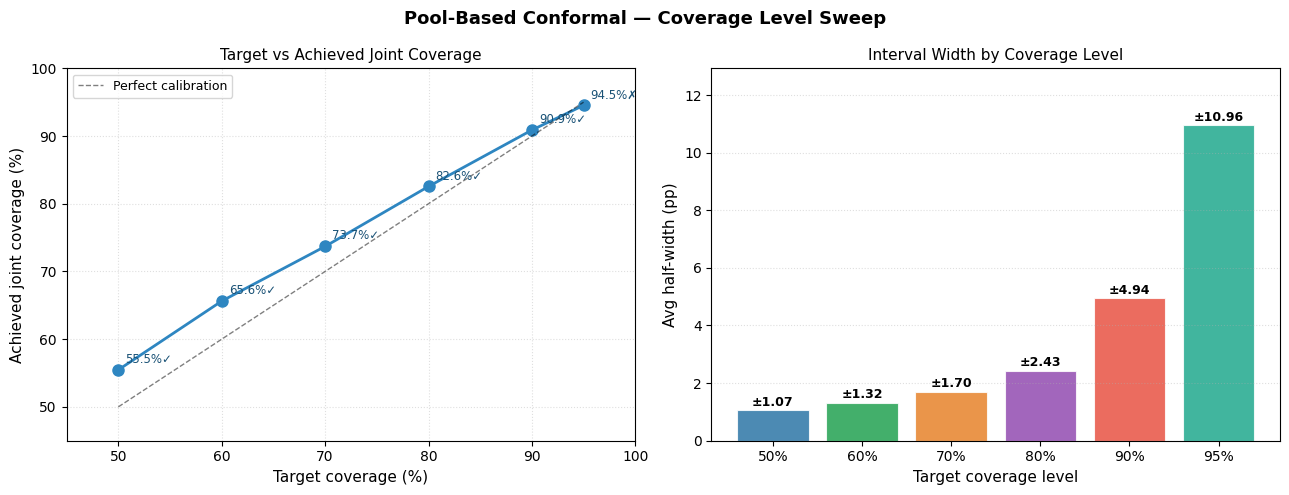

In [ ]:
# ── Coverage level sweep: 50 / 60 / 70 / 80 / 90 / 95% ─────────────────────
#
# For each target level, re-run the pool-based conformal inference
# (same peer residuals, same pool structure — only the quantile changes)
# and record: achieved joint coverage, avg half-width, % scenarios using local pool.

import numpy as np
import math
import matplotlib.pyplot as plt

LEVELS = [0.50, 0.60, 0.70, 0.80, 0.90, 0.95]
MIN_POOL = 10

sweep_results = []

for target in LEVELS:
    hw_sweep = np.zeros(len(test_ci))

    for i, s in enumerate(test_ci):
        mid    = int(s['merchant_id'])
        yr, mo = s['context_range'][1]

        pool_df   = generate_pool(df_5411_sample, mid, yr, mo)
        peer_mids = set(int(p) for p in pool_df['merchant_id'].unique())

        peer_res = []
        for peer in peer_mids:
            peer_res.extend(merchant_cal_res.get(peer, []))

        # Adaptive quantile for this target level
        n = len(peer_res)
        level = math.ceil((n + 1) * target) / n if n >= MIN_POOL else None

        if level is not None and level <= 1.0:
            hw_sweep[i] = float(np.quantile(peer_res, level))
        else:
            # Global fallback: use cal_max_res_raw at this target level
            gl_level = math.ceil((len(cal_max_res_raw) + 1) * target) / len(cal_max_res_raw)
            gl_level = min(gl_level, 1.0)
            hw_sweep[i] = float(np.quantile(cal_max_res_raw, gl_level))

    lo_sw = np.clip(te_preds_ci - hw_sweep[:, None], 0, None)
    hi_sw =         te_preds_ci + hw_sweep[:, None]

    in_sw       = (y_te_ci >= lo_sw) & (y_te_ci <= hi_sw)
    joint_sw    = float(np.mean(in_sw.all(axis=1)))
    avg_hw      = float(np.mean(hw_sweep))

    sweep_results.append({
        'target'   : target,
        'joint_cov': joint_sw,
        'avg_hw'   : avg_hw,
    })
    print(f"  Target {target*100:.0f}%  →  joint={joint_sw:.3f}  avg_half_width=±{avg_hw:.4f}")

# ── Figure: 2-panel ───────────────────────────────────────────────────────────
targets    = [r['target']    for r in sweep_results]
joint_covs = [r['joint_cov'] for r in sweep_results]
avg_hws    = [r['avg_hw']    for r in sweep_results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Pool-Based Conformal — Coverage Level Sweep', fontsize=13, fontweight='bold')

colors = ['#2471a3', '#1a9e4a', '#e67e22', '#8e44ad', '#e74c3c', '#17a589']

# Panel 1: Achieved joint coverage vs target
ax1.plot([t * 100 for t in targets], [j * 100 for j in joint_covs],
         marker='o', linewidth=2, color='#2e86c1', markersize=8)
ax1.plot([50, 95], [50, 95], 'k--', linewidth=1, alpha=0.5, label='Perfect calibration')
for t, j in zip(targets, joint_covs):
    badge = '✓' if j >= t else '✗'
    ax1.annotate(f'{j*100:.1f}%{badge}',
                 xy=(t * 100, j * 100), xytext=(5, 5), textcoords='offset points',
                 fontsize=8.5, color='#1a5276')
ax1.set_xlabel('Target coverage (%)', fontsize=11)
ax1.set_ylabel('Achieved joint coverage (%)', fontsize=11)
ax1.set_title('Target vs Achieved Joint Coverage', fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(linestyle=':', alpha=0.4)
ax1.set_xlim(45, 100)
ax1.set_ylim(45, 100)

# Panel 2: Avg half-width vs target
bars = ax2.bar([f'{int(t*100)}%' for t in targets], avg_hws,
               color=colors, alpha=0.82, edgecolor='white', linewidth=0.8)
for bar, hw in zip(bars, avg_hws):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
             f'±{hw:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_xlabel('Target coverage level', fontsize=11)
ax2.set_ylabel('Avg half-width (pp)', fontsize=11)
ax2.set_title('Interval Width by Coverage Level', fontsize=11)
ax2.grid(axis='y', linestyle=':', alpha=0.4)
ax2.set_ylim(0, max(avg_hws) * 1.18)

plt.tight_layout()
plt.savefig('coverage_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
